# Modelado — velocidad de arriendo

Continúa `analisis_variables_final.ipynb`. Aquel notebook no entrenaba nada; este entrena
cuatro modelos, elige el horizonte con datos en vez de por decreto, y los compara **en las dos
escalas a la vez** contra un baseline honesto.

## Dos preguntas que hay que responder antes de elegir un modelo

**¿Cuál es el horizonte correcto?** El proyecto define 20 días, pero eso es una definición de
negocio, no una medición. Qué tan predecible es el desenlace depende del corte: a 15 días la
tasa base es 0,205, a 30 días es 0,346, y un binario discrimina mejor cuando el corte cae cerca
de la mediana del tiempo de cierre —que el análisis midió en 29 días. Contra eso juegan la
observabilidad (a horizontes largos hay más unidades cuyo desenlace todavía no se sabe) y lo
accionable que resulta la alerta. El **Paso 5** mide las tres cosas y deja la elección
explícita.

**¿Binaria o días?** Las dos, porque miden cosas distintas y un modelo puede ganar en una y
perder en la otra. Cada modelo de este notebook produce tres salidas y se evalúa en todas:

| Salida | Métrica | Qué responde |
|---|---|---|
| `P(T ≤ h)` en toda la rejilla de horizontes | AUC, Brier con IPCW, **IBS** | ¿acierta la probabilidad, y a qué plazos? |
| días predichos | error absoluto mediano | ¿cuántos días de más o de menos dice? |
| score de riesgo | **C-index** de Harrell | ¿ordena bien las unidades, usando también las censuradas? |

El IBS y el C-index son las dos métricas que **usan las filas censuradas**; el AUC y el Brier
en un punto solo miran las que ya tienen desenlace conocido. Esa es la diferencia práctica
entre evaluar un modelo de duración y evaluar un clasificador.

## Las tres restricciones que mandan sobre la familia del modelo

| Restricción | Medida en el análisis | Qué descalifica |
|---|---|---|
| **Censura** | 19,1% en la muestra, 73,9% en la cohorte 2026-08 | OLS sobre los días de las arrendadas |
| **Riesgo competitivo** | churn 18,2%, sube con el gap (0,038 → 0,072) | Tratar el churn como censura |
| **Cardinalidad de ubicación** | 796 edificios, 775 con n<30 (57% de la muestra) | Dummies de edificio, y la CV aleatoria |

De ahí los cuatro modelos:

| # | Modelo | Se ajusta sobre | Salida nativa |
|---|---|---|---|
| **A** | Logística ridge | `y_h` binaria (reajusta por horizonte) | `P(T ≤ h)` |
| **B** | **AFT log-normal** | `(días, censura)` | días **y** toda la curva de un solo ajuste |
| **C** | Hazard discreto multinomial | `(semana, arriendo/churn/nada)` | curva de incidencia acumulada, sin inflar por churn |
| **D** | Gradient boosting | `y_h` binaria | `P(T ≤ h)` · **cota superior**, no candidato |

## Lo que hay que leer primero

El **Paso 3** es el más importante. Con estos datos una CV aleatoria sobreestima el desempeño
por fuga entre unidades del mismo edificio y por deriva temporal; el Paso 8 mide cuánto.
Cualquier número que salga de acá hacia afuera viene de la validación *forward* por cohorte.

**Tiempo de ejecución:** 5-15 minutos. Los modelos B y C se ajustan una sola vez por cohorte
y de ahí sale la curva completa; A y D se reajustan en cada horizonte, y por eso usan un
penalizador fijo en el barrido (elegido por CV una sola vez, en el Paso 8).

Se mantiene el criterio de van Smeden et al. (2019) que ya venía en `modelo arriendo.py`:
shrinkage en vez de máxima verosimilitud pura, sin backward elimination, y **Brier y
calibración junto al AUC**. Un modelo con buen AUC y pendiente de calibración 0,6 no sirve
para decidir un precio.

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import time
import warnings
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)
# ConvergenceWarning hereda de UserWarning. Silenciarla en bloque fue como en la
# corrida del 2026-09-01 el Paso 15 entrego numeros de modelos que habian chocado
# contra max_iter sin decirlo, y ademas tardo 56 minutos. Se deja visible.
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("always", category=ConvergenceWarning)

# --- Paleta: la misma de los otros dos notebooks del proyecto ---------------
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
GRID, SURFACE = "#e6e4dd", "#fcfcfb"
AZUL, NARANJA, AQUA, VIOLETA = "#2a78d6", "#eb6834", "#1baf7a", "#8b5cd6"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 9, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

# --- Parametros -------------------------------------------------------------
PRECIO_MIN, PRECIO_MAX = 150_000, 2_500_000

# La rejilla de horizontes. NO hay un H privilegiado hasta el Paso 5: todo se
# evalua sobre esta rejilla completa y ahi se decide cual reportar.
REJILLA_H = [10, 15, 20, 30, 45, 60]
H_PROYECTO = 20           # el que define el negocio hoy; se contrasta, no se asume
H_REPORTE  = None         # lo fija el Paso 5

SEMILLA     = 42
MIN_OBS     = 30          # categorias con menos observaciones -> "Otras"
M_SHRINK    = 20          # shrinkage del target encoding de edificio
K_SEMANAS   = 13          # horizonte del hazard discreto (13 x 7 = 91 dias)
OBS_MIN_COH = 0.90        # cohortes con menos observabilidad no se evaluan
MIN_TRAIN   = 6           # cohortes minimas antes del primer fold forward

PROHIBIDAS_PREFIJO = ("no_modelo_",)   # nada que mire al futuro entra como feature

np.random.seed(SEMILLA)

## Carga

Misma query y mismo patrón de conexión que el notebook de análisis. La query no filtra: trae
las 7.683 unidades del universo y marca en `motivo_exclusion` por qué cada una no es
analizable.

In [3]:
import sqlalchemy
from sqlalchemy import text
from dotenv import load_dotenv
from utils import load_sql_query, Engine, logger

load_dotenv()
username = os.getenv("DATABASE_USERNAME")
password = quote_plus(os.getenv("DATABASE_PASSWORD"))
host     = os.getenv("DATABASE_HOST")
database = os.getenv("DATABASE_NAME")

engine = Engine()
engine.engine = sqlalchemy.create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}",
    pool_recycle=300,
    pool_pre_ping=True,
)

t0 = time.time()
df = pd.read_sql(text(load_sql_query("query_analisis_final.sql")), engine.engine)
print(f"{time.time() - t0:.1f}s · {len(df):,} filas · "
      f"{df['property_id'].nunique():,} properties · {df.shape[1]} columnas")

assert df["property_id"].is_unique, "property_id no es unico: hay un join que duplica"

21.1s · 7,731 filas · 7,731 properties · 93 columnas


In [4]:
# Tipos. Identico al notebook de analisis: la query devuelve DECIMAL y fechas
# cero como object, y sin esto un modelo recibe strings sin avisar.
NUMERICAS_RAW = [
    "dormitorios", "banos", "estudio", "m2_utiles", "m2_por_dormitorio", "piso",
    "acepta_mascotas", "ggcc", "precio_oferta", "precio_lpa", "precio_post",
    "precio_m2", "dias_habilitacion",
    "d0_7_visitas", "d0_7_leads", "d0_7_reservas",
    "no_modelo_days_to_event", "no_modelo_days_to_check_in",
    "no_modelo_dias_contrato_a_check_in", "no_modelo_days_to_reserva",
    "no_modelo_dias_reserva_a_contrato", "no_modelo_days_to_contrato",
    "no_modelo_n_reservas_pre_contrato", "no_modelo_dias_observados",
    "no_modelo_censurada", "no_modelo_churn",
    "no_modelo_visitas_sem_1", "no_modelo_visitas_sem_2",
    "no_modelo_visitas_sem_3", "no_modelo_visitas_sem_4",
    "no_modelo_visitas_sem5_a_90", "no_modelo_visitas_90d",
    "no_modelo_leads_90d", "no_modelo_reservas_90d", "no_modelo_precio_cierre",
    "no_modelo_n_precios_ventana", "no_modelo_pct_bajada",
    "no_modelo_monto_arriendo", "precio_ml_expost", "uf_m2",
    "ratio_ml", "log_ratio_ml", "log_ratio_centrado", "n_segmento",
    "sobrevive_d7", "mes_lpa", "trimestre_lpa", "dow_lpa", "year_lpa",
]
for c in NUMERICAS_RAW:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["fecha_LPA", "fecha_creacion", "no_modelo_event_date",
          "no_modelo_fecha_check_in", "no_modelo_fecha_primera_reserva",
          "no_modelo_fecha_ultima_reserva_pre_contrato",
          "no_modelo_inicio_contrato", "no_modelo_fecha_baja", "ml_pricing_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

print(df.dtypes.value_counts().to_string())

float64           43
int64             23
object            18
datetime64[ns]     9


## Paso 1 · Muestra de trabajo, y el arreglo del gap centrado

**La muestra.** `motivo_exclusion == 'analizable'` más la banda de precio de negocio. Quedan
~3.834 filas de 7.683. Las descartadas no son un grupo neutro —censura 69,6% contra 19,1%—
así que el modelo aplica a unidades que llegan a LPA con historial de precio, no a todo el
stock. Eso va en cualquier informe.

**El arreglo, con el diagnóstico ya confirmado contra la base.** El síntoma es que
`sd(log_ratio_centrado)` de la query sale **0,1705**, mayor que el crudo **0,1073**. Eso es
imposible si el centrado está bien: la media de un grupo es exactamente el valor que minimiza
la suma de cuadrados dentro del grupo, así que centrar solo puede *reducir* la varianza. Si
sube, la media se calculó sobre una población distinta de aquella donde se mide la sd.

Y eso es lo que pasa. El `AVG() OVER` de la query corre sobre las 7.683 filas de la salida,
pero la muestra de trabajo son 3.834. Medido: **45 filas pesan en el promedio sin estar en la
muestra**, y 24 de ellas están marcadas `analizable` —las excluye solo la banda de precio— con
`log_ratio_ml` de hasta **−7,03**, o sea un precio de oferta de ~1/1.100 de la recomendación
del ML. Eso no es una unidad barata: es un error de captura, alguien escribió el precio en
miles o en UF. Media del grupo −4,17, sd 3,63.

Con celdas de **mediana 10 filas**, cada intrusa corre la media de sus nueve vecinas ~0,4 y les
inyecta esa desviación espuria. Como la varianza va al cuadrado, 24 intrusas alcanzan para
llevar la sd de 0,107 a 0,170.

**La partición no era el problema** y no se toca: `comuna × tipología × cohorte` con mediana 10
absorbe más confounding que cualquier alternativa más gruesa. Acá se usa esa misma partición
con retroceso jerárquico para las celdas chicas. Como `d` ya es la muestra filtrada, las 45
intrusas quedaron fuera solas; solo se agrega un guardia contra un `precio_ml_expost` absurdo
en una fila que sí está en banda.

El valor esperado tras el arreglo es **~0,087**. La celda siguiente lo verifica con un `assert`:
si no baja del crudo, hay que parar antes de modelar, porque el gap es una de las dos únicas
variables accionables del proyecto.

In [5]:
d = df[df["motivo_exclusion"] == "analizable"].copy()
en_banda = d["precio_oferta"].between(PRECIO_MIN, PRECIO_MAX)
print(f"Analizables por la query : {len(d):,}")
print(f"Fuera de banda de precio : {(~en_banda).sum():,}")
d = d[en_banda].copy()
print(f"Muestra de trabajo       : {len(d):,}")

# --- Centrado del gap, version corregida ------------------------------------
N_MIN_CELDA = 8          # mediana de celda medida: 10 filas
GAP_ABSURDO = 1.0        # |log ratio| > 1  ->  precio fuera de [0,37x , 2,7x] del ML

d["_dorm_g"] = d["dormitorios"].clip(0, 3).fillna(-1).astype(int)
niveles = [
    ["comuna", "nombre_tipologia", "cohorte_lpa"],      # la fina: mediana 10
    ["sector_provincia", "_dorm_g", "trimestre_lpa"],
    ["sector_provincia", "_dorm_g"],
    ["sector_provincia"],
]

# `d` ya es la muestra de trabajo, asi que las 45 filas que contaminaban la media
# en la query quedaron fuera por construccion. Falta el guardia contra un
# precio_ml_expost absurdo en una fila que si esta en banda de precio.
gap = d["log_ratio_ml"]
gap_elegible = gap.where(gap.abs() <= GAP_ABSURDO)
print(f"Filas con |log_ratio_ml| > {GAP_ABSURDO} excluidas del promedio: "
      f"{int((gap.abs() > GAP_ABSURDO).sum())}")

centro = pd.Series(np.nan, index=d.index)
nivel_usado = pd.Series("global", index=d.index)
for keys in niveles:
    g = gap_elegible.groupby([d[k] for k in keys])
    # count() y no size(): size cuenta los NaN y sobreestima la celda.
    media, tam = g.transform("mean"), g.transform("count")
    aplica = centro.isna() & (tam >= N_MIN_CELDA) & media.notna()
    centro[aplica] = media[aplica]
    nivel_usado[aplica] = " x ".join(keys)
centro = centro.fillna(gap_elegible.mean())

d["gap_centrado"]   = (gap - centro).fillna(0.0)   # 0 = "igual que su segmento"
d["gap_disponible"] = d["log_ratio_ml"].notna().astype(int)

print("\nNivel de centrado efectivamente usado:")
print(nivel_usado.value_counts().to_string())

Analizables por la query : 3,929
Fuera de banda de precio : 28
Muestra de trabajo       : 3,901
Filas con |log_ratio_ml| > 1.0 excluidas del promedio: 0

Nivel de centrado efectivamente usado:
comuna x nombre_tipologia x cohorte_lpa       2221
sector_provincia x _dorm_g x trimestre_lpa    1589
sector_provincia x _dorm_g                      83
sector_provincia                                 8


In [6]:
sd_crudo     = d["log_ratio_ml"].std()
sd_query     = d["log_ratio_centrado"].std()
sd_corregido = d.loc[d["gap_disponible"] == 1, "gap_centrado"].std()

print(f"sd(log_ratio_ml)        crudo       = {sd_crudo:.4f}")
print(f"sd(log_ratio_centrado)  de la query = {sd_query:.4f}   <- mayor que el crudo: mal")
print(f"sd(gap_centrado)        corregido   = {sd_corregido:.4f}")
print(f"\nEl centrado corregido absorbe {1 - sd_corregido / sd_crudo:.1%} de la varianza.")
print("Referencia medida el 2026-08-31 sobre la muestra de trabajo: 0,0871.")
assert sd_corregido < sd_crudo, (
    "El centrado sigue agregando varianza. Con la particion correcta esto solo\n"
    "puede pasar si la media se calcula sobre filas que no estan en la muestra:\n"
    "revisar quien entra al promedio antes de modelar nada."
)
print("OK: centrar reduce varianza, que es lo unico que puede hacer si esta bien.")
print()
print("La columna log_ratio_centrado que viene de la query NO se usa de aca en")
print("adelante. query_analisis_final_v2.sql trae el arreglo en SQL; mientras la")
print("query en produccion sea la v1, quien la use sin este notebook lee la mala.")

sd(log_ratio_ml)        crudo       = 0.1072
sd(log_ratio_centrado)  de la query = 0.1696   <- mayor que el crudo: mal
sd(gap_centrado)        corregido   = 0.1007

El centrado corregido absorbe 6.1% de la varianza.
Referencia medida el 2026-08-31 sobre la muestra de trabajo: 0,0871.
OK: centrar reduce varianza, que es lo unico que puede hacer si esta bien.

La columna log_ratio_centrado que viene de la query NO se usa de aca en
adelante. query_analisis_final_v2.sql trae el arreglo en SQL; mientras la
query en produccion sea la v1, quien la use sin este notebook lee la mala.


## Paso 2 · Las variables dependientes

Tres formas de escribir "velocidad". No son intercambiables, y la tabla muestra sobre cuántas
filas es utilizable cada una — que es la primera razón por la que el binario no domina.

- **`y_h` binaria**, una por horizonte. Es `NaN` cuando la unidad sigue censurada antes de h:
  a los 20 días no se sabe el desenlace del 4% de la muestra, a los 60 días de bastante más.
  **El churn antes de h no es `NaN`, es un 0**: esa unidad no se arrendó y ya no se va a
  arrendar.
- **`(dias_obs, evento_arriendo)`.** Usa las 3.834 filas. Es lo que aprovechan el AFT y el
  hazard, y lo que hace posible el C-index y el IBS.
- **`estado_final` de tres valores.** `arriendo` / `churn` / `sigue`. El churn compite con el
  arriendo por la misma unidad; no es "todavía no sabemos".

Un detalle que cambia el número: se mide contra `event_date`, que es la **reserva** cuando
existe (77,1% de los casos) y el contrato cuando no. Eso sube `y_20` de 32,2% a 39,3% respecto
de medir contra el contrato. La mezcla no es homogénea, así que hay que citarla junto a
cualquier tasa.

In [7]:
dias = d["no_modelo_dias_observados"].astype(float)
cens = d["no_modelo_censurada"].astype(int)
tipo = d["no_modelo_tipo_evento"].astype(str)

d["dias_obs"]        = dias
d["evento_arriendo"] = (tipo == "arriendo").astype(int)
d["evento_churn"]    = (tipo == "churn").astype(int)
d["censurada"]       = cens
d["estado_final"]    = np.select(
    [d["evento_arriendo"] == 1, d["evento_churn"] == 1], ["arriendo", "churn"], "sigue")


def target_binario(datos, h):
    '''1 = se arrendo en <= h dias. 0 = se sabe que no (paso h, o hizo churn antes).
    NaN = sigue censurada antes de h, el desenlace no se conoce.'''
    t, arr, chu, ce = (datos["dias_obs"].to_numpy(float),
                       datos["evento_arriendo"].to_numpy(int),
                       datos["evento_churn"].to_numpy(int),
                       datos["censurada"].to_numpy(int))
    y = np.full(len(datos), np.nan)
    y[(arr == 1) & (t <= h)] = 1.0
    y[t > h] = 0.0
    y[(chu == 1) & (t <= h)] = 0.0
    y[(ce == 1) & (t <= h)] = np.nan
    return y


filas = []
for h in REJILLA_H:
    y = target_binario(d, h)
    d[f"y_{h}"] = y
    filas.append({"h": h, "n_observable": int(np.isfinite(y).sum()),
                  "pct_observable": float(np.isfinite(y).mean()),
                  "tasa_base": float(np.nanmean(y))})
obs = pd.DataFrame(filas).set_index("h")
display(obs.round(3))

print("Composicion del desenlace:")
print(d["estado_final"].value_counts(normalize=True).round(3).to_string())
print("\nMezcla de event_date (solo arrendadas):")
print(d.loc[d["evento_arriendo"] == 1, "no_modelo_origen_event_date"]
       .value_counts(normalize=True).round(3).to_string())

,n_observable,pct_observable,tasa_base
h,,,
10,3783,0.970,0.140
15,3748,0.961,0.204
20,3713,0.952,0.255
30,3650,0.936,0.343
45,3567,0.914,0.447
60,3521,0.903,0.524


Composicion del desenlace:
estado_final
arriendo   0.617
sigue      0.201
churn      0.182

Mezcla de event_date (solo arrendadas):
no_modelo_origen_event_date
reserva    0.771
contrato   0.229


## Paso 3 · La validación

Con estos datos hay dos mecanismos de fuga que una CV aleatoria no ve:

1. **Fuga por edificio.** Dos unidades del mismo edificio comparten ubicación, administración
   y política de precio. El análisis midió `y_20` entre 0,02 y 0,87 en los 21 edificios con
   n≥30. Con split aleatorio casi todo edificio queda en train y en test a la vez, y el modelo
   memoriza el edificio en vez de aprender qué lo hace rápido.
2. **Deriva temporal.** `visitas_d0_7` se mueve entre 4,7 y 13,3 entre cohortes y
   `reservas_90d` cae de 0,72 a 0,17. El uso real es predecir el mes que viene con lo
   aprendido hasta hoy, nunca interpolar dentro del pasado.

La evaluación por defecto es **forward por cohorte**. Los otros dos esquemas se corren una vez
en el Paso 8, solo para medir cuánto se auto-engaña un proyecto validado con
`train_test_split`.

Las cohortes con observabilidad de `y_h` bajo 0,90 no se usan como test: en el análisis la
cohorte 2026-08 tenía 0,401, y su `y_20` de 0,476 contra una base de 0,257 es sesgo de
longitud, no una mejora.

In [8]:
from sklearn.model_selection import StratifiedKFold, GroupKFold

COHORTES = sorted(d["cohorte_lpa"].dropna().unique())
obs_coh = (d.assign(_ok=d[f"y_{H_PROYECTO}"].notna())
             .groupby("cohorte_lpa")["_ok"].agg(["mean", "size"])
             .rename(columns={"mean": "observabilidad", "size": "n"}))
obs_coh["evaluable"] = obs_coh["observabilidad"] >= OBS_MIN_COH
display(obs_coh.round(3))
EVALUABLES = [c for c in COHORTES if bool(obs_coh.loc[c, "evaluable"])]
print(f"{len(COHORTES)} cohortes · {len(EVALUABLES)} evaluables como test")


def folds_forward(datos, min_train=MIN_TRAIN):
    '''Entrena con todo lo anterior, evalua en la cohorte siguiente.'''
    coh = datos["cohorte_lpa"]
    out = []
    for i in range(min_train, len(COHORTES)):
        c_test = COHORTES[i]
        if c_test not in EVALUABLES:
            continue
        tr = np.where(coh.isin(COHORTES[:i]))[0]
        te = np.where(coh == c_test)[0]
        if len(tr) >= 200 and len(te) >= 30:
            out.append((tr, te))
    return out


def folds_aleatorio(datos, y, n=5):
    return list(StratifiedKFold(n, shuffle=True,
                                random_state=SEMILLA).split(datos, y))


def folds_por_edificio(datos, y, n=5):
    return list(GroupKFold(n_splits=n).split(datos, y, datos["grupo_edificio"]))

,observabilidad,n,evaluable
cohorte_lpa,,,
2025-07,1.000,97,True
2025-08,1.000,171,True
2025-09,1.000,185,True
2025-10,1.000,178,True
2025-11,1.000,232,True
2025-12,1.000,435,True
2026-01,1.000,276,True
2026-02,1.000,306,True
2026-03,1.000,419,True


15 cohortes · 13 evaluables como test


## Paso 4 · Features

Dos conjuntos, y la diferencia es *cuándo* se calcula el score: **`lpa`** (día 0, solo lo que
se sabe al publicar) y **`landmark`** (día 7, agrega la demanda de la primera semana).

Tres decisiones que vienen directo del análisis:

**El edificio va con target encoding suavizado, no con dummies.** 796 niveles contra 3.834
filas. El encoding se calcula *dentro de cada fold de entrenamiento* y con validación cruzada
interna: calcularlo sobre todos los datos es la forma más común de inventarse un AUC. La media
de cada edificio se encoge hacia la global con `m = 20`.

**`ggcc` faltante entra como indicador y nunca se imputa a secas.** 17,3% de faltante, y esas
filas tienen `y_20` 0,138 contra 0,281 y churn 0,398 contra 0,137. El faltante *es* la señal.

**`piso == 0` entra como bandera separada.** 1.179 de 3.834 filas (30,8%), y `piso` es la única
variable con signo invertido. Casi seguro que 0 es "sin dato"; hasta confirmarlo se modela la
bandera y se imputa el valor.

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold


def _ohe():
    '''OneHotEncoder compatible con varias versiones de scikit-learn.'''
    base = dict(handle_unknown="ignore", drop="first")
    for extra in ({"sparse_output": False}, {"sparse": False}, {}):
        try:
            return OneHotEncoder(**base, **extra)
        except TypeError:
            continue
    return OneHotEncoder(**base)


class TargetEncoderSuavizado(BaseEstimator, TransformerMixin):
    '''Media del target por nivel, encogida hacia la media global:

        codigo(nivel) = (suma_nivel + m * prior) / (n_nivel + m)

    En `fit_transform` la codificacion del propio train sale fuera de pliegue
    (5-fold interno). Sin eso la fila contribuye a su propio codigo y el modelo
    lee un edificio mucho mas informativo de lo que es.
    '''

    def __init__(self, cols, m=20, n_folds=5, semilla=42):
        self.cols, self.m, self.n_folds, self.semilla = cols, m, n_folds, semilla

    def _mapa(self, claves, y):
        g = pd.DataFrame({"k": claves, "y": y}).groupby("k")["y"]
        return ((g.sum() + self.m * self.prior_) / (g.size() + self.m)).to_dict()

    def fit(self, X, y=None):
        y = np.asarray(y, dtype=float)
        self.prior_ = float(np.nanmean(y))
        self.mapas_ = {c: self._mapa(X[c].astype(str).to_numpy(), y) for c in self.cols}
        return self

    def transform(self, X):
        out = np.empty((len(X), len(self.cols)), dtype=float)
        for j, c in enumerate(self.cols):
            out[:, j] = pd.Series(X[c].astype(str).to_numpy()).map(
                self.mapas_[c]).fillna(self.prior_).to_numpy()
        return out

    def fit_transform(self, X, y=None, **kw):
        self.fit(X, y)
        y = np.asarray(y, dtype=float)
        out = np.full((len(X), len(self.cols)), self.prior_, dtype=float)
        for tr, te in KFold(self.n_folds, shuffle=True,
                            random_state=self.semilla).split(X):
            for j, c in enumerate(self.cols):
                claves = X[c].astype(str).to_numpy()
                mapa = self._mapa(claves[tr], y[tr])
                out[te, j] = pd.Series(claves[te]).map(mapa).fillna(
                    self.prior_).to_numpy()
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_te" for c in self.cols])

In [10]:
NUM_LPA = ["log_precio", "precio_m2", "m2_utiles", "m2_por_dormitorio",
           "dormitorios", "banos", "estudio", "piso", "piso_es_cero",
           "acepta_mascotas", "ggcc", "ggcc_falta", "dias_habilitacion",
           "gap_centrado", "gap_disponible", "mes_sin", "mes_cos"]
CAT_LPA = ["sector_provincia", "comuna_g", "nombre_tipologia", "owner_type"]
HI_CARD = ["grupo_edificio"]
NUM_LANDMARK = ["d0_7_visitas", "d0_7_leads", "d0_7_reservas", "tiene_lead_d0_7"]


def preparar(base):
    '''Columnas derivadas. No dependen de otras filas ni del target, asi que se
    calculan una sola vez antes de partir en folds.'''
    x = base.copy()
    x["log_precio"]   = np.log(x["precio_oferta"].clip(lower=1))
    x["piso_es_cero"] = (x["piso"].fillna(0) == 0).astype(int)
    x["piso"]         = x["piso"].replace(0, np.nan)
    x["ggcc_falta"]   = x["ggcc"].isna().astype(int)
    x["tiene_lead_d0_7"] = (x["d0_7_leads"].fillna(0) > 0).astype(int)
    x["mes_sin"] = np.sin(2 * np.pi * x["mes_lpa"] / 12)   # enero y diciembre
    x["mes_cos"] = np.cos(2 * np.pi * x["mes_lpa"] / 12)   # quedan cerca
    conteo = x["comuna"].value_counts()
    x["comuna_g"] = x["comuna"].where(
        x["comuna"].isin(conteo[conteo >= MIN_OBS].index), "Otras")
    for c in CAT_LPA + HI_CARD:
        x[c] = x[c].astype(str).fillna("sin dato")
    for c in NUM_LANDMARK[:3]:
        x[c] = pd.to_numeric(x[c], errors="coerce").fillna(0)
    return x


def columnas(modo="lpa"):
    return NUM_LPA + (NUM_LANDMARK if modo == "landmark" else []), CAT_LPA, HI_CARD


def diseno(modo="lpa"):
    num, cat, hi = columnas(modo)
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", _ohe())]), cat),
        ("te", TargetEncoderSuavizado(hi, m=M_SHRINK, semilla=SEMILLA), hi),
    ], remainder="drop")


D = preparar(d)
FOLDS = folds_forward(D)

usadas = set(sum(columnas("landmark"), []))
fugas = [c for c in usadas if c.startswith(PROHIBIDAS_PREFIJO)]
assert not fugas, f"features que miran al futuro: {fugas}"
print(f"Features dia 0   : {len(columnas('lpa')[0])} numericas + {len(CAT_LPA)} "
      f"categoricas + edificio (target encoding)")
print(f"Features landmark: {len(columnas('landmark')[0])} numericas + lo mismo")
print(f"Folds forward    : {len(FOLDS)}  "
      f"(train {FOLDS[0][0].size}->{FOLDS[-1][0].size} filas)")
print("Ninguna columna no_modelo_ entra como feature: verificado.")

Features dia 0   : 17 numericas + 4 categoricas + edificio (target encoding)
Features landmark: 21 numericas + lo mismo
Folds forward    : 7  (train 1298->3273 filas)
Ninguna columna no_modelo_ entra como feature: verificado.


## Paso 5 · Elegir el horizonte

Hasta acá no hay un `H` privilegiado. La pregunta "¿20 días es el corte correcto?" tiene
respuesta empírica, y son tres criterios que tiran en direcciones distintas:

1. **Observabilidad.** A horizontes largos hay más unidades cuyo desenlace todavía no se sabe,
   y esas filas se pierden. Bajo ~0,90 el target deja de ser confiable.
2. **Separabilidad.** Un binario discrimina mejor cuando el corte cae donde hay masa de
   eventos. Con la mediana de cierre en 29 días, es razonable esperar que el AUC suba entre 15
   y 30 días y se aplane después. **Un AUC alto en un horizonte donde la tasa base es 0,9 no
   sirve para nada**: acertar que "casi todo se arrienda en 60 días" es fácil y no informa.
3. **Accionabilidad.** Una alerta a 60 días llega cuando la unidad ya lleva dos meses parada.
   Este criterio no está en los datos y lo pone el negocio.

El barrido usa una logística con penalizador fijo (rápida) sobre el esquema forward. No es el
modelo final: es una sonda para ver la forma de la curva. La decisión se escribe explícita en
`H_REPORTE` al final de la celda.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

C_SONDA = 0.1


def sonda_horizonte(h, modo="lpa", C=C_SONDA):
    '''AUC forward de una logistica rapida en el horizonte h.'''
    y = target_binario(D, h)
    ys, ps = [], []
    for tr, te in FOLDS:
        mtr, mte = np.isfinite(y[tr]), np.isfinite(y[te])
        if mtr.sum() < 200 or mte.sum() < 30 or len(np.unique(y[tr][mtr])) < 2:
            continue
        pipe = Pipeline([("pre", diseno(modo)),
                         ("clf", LogisticRegression(C=C, max_iter=4000))])
        pipe.fit(D.iloc[tr[mtr]], y[tr][mtr])
        ps.append(pipe.predict_proba(D.iloc[te[mte]])[:, 1])
        ys.append(y[te][mte])
    if not ys:
        return np.nan, np.nan, 0
    yy, pp = np.concatenate(ys), np.concatenate(ps)
    auc = roc_auc_score(yy, pp) if len(np.unique(yy)) == 2 else np.nan
    return auc, brier_score_loss(yy, pp), len(yy)


barrido = []
for h in REJILLA_H:
    y = target_binario(D, h)
    auc, brier, n_ev = sonda_horizonte(h)
    barrido.append({
        "h": h,
        "pct_observable": float(np.isfinite(y).mean()),
        "tasa_base": float(np.nanmean(y)),
        "eventos": int(np.nansum(y)),
        "AUC_forward": auc,
        "Brier": brier,
        "n_evaluado": n_ev,
    })
barr = pd.DataFrame(barrido).set_index("h")
display(barr.round(3))

,pct_observable,tasa_base,eventos,AUC_forward,Brier,n_evaluado
h,,,,,,
10,0.970,0.140,529,0.715,0.117,2279
15,0.961,0.204,763,0.707,0.153,2279
20,0.952,0.255,946,0.719,0.172,2279
30,0.936,0.343,1252,0.724,0.197,2279
45,0.914,0.447,1594,0.731,0.212,2197
60,0.903,0.524,1846,0.742,0.210,2151


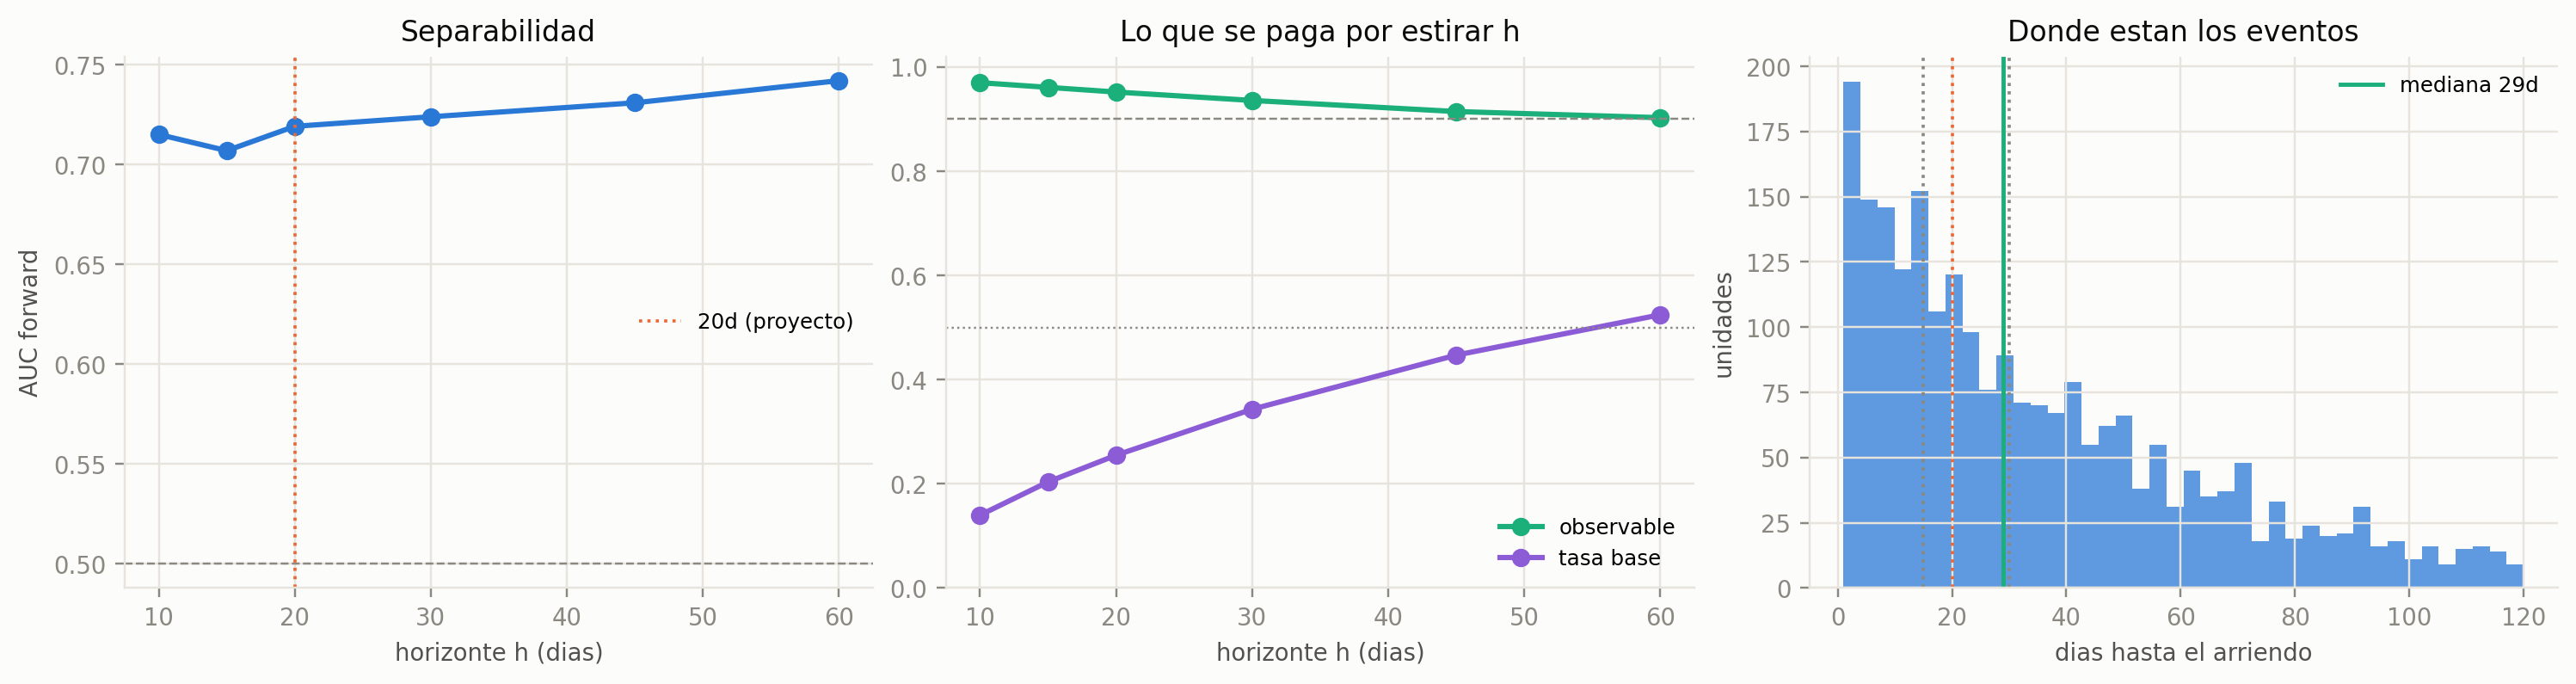

Horizontes con observabilidad >= 0,90 y tasa base en [0,15 - 0,85]: [15, 20, 30, 45, 60]
De esos, el de mayor AUC forward: 60 dias (AUC 0.742)
El del proyecto, 20 dias: AUC 0.719

H_REPORTE = 20 dias  <- el que se usa de aca en adelante
   (los datos favorecen 60d por +0.023 de AUC;
    se mantiene el del proyecto por accionabilidad. Decision de negocio, no estadistica.)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5), constrained_layout=True)

ax = axes[0]
ax.plot(barr.index, barr["AUC_forward"], "o-", color=AZUL, lw=2)
ax.axhline(0.5, color=INK_MUTED, lw=0.8, ls="--")
ax.axvline(H_PROYECTO, color=NARANJA, lw=1.2, ls=":", label=f"{H_PROYECTO}d (proyecto)")
ax.set_xlabel("horizonte h (dias)"); ax.set_ylabel("AUC forward")
ax.set_title("Separabilidad"); ax.legend(frameon=False, fontsize=8)

ax = axes[1]
ax.plot(barr.index, barr["pct_observable"], "o-", color=AQUA, lw=2, label="observable")
ax.plot(barr.index, barr["tasa_base"], "o-", color=VIOLETA, lw=2, label="tasa base")
ax.axhline(OBS_MIN_COH, color=INK_MUTED, lw=0.8, ls="--")
ax.axhline(0.5, color=INK_MUTED, lw=0.8, ls=":")
ax.set_xlabel("horizonte h (dias)"); ax.set_ylim(0, 1.02)
ax.set_title("Lo que se paga por estirar h"); ax.legend(frameon=False, fontsize=8)

# Donde esta la masa de eventos: es lo que explica la forma de la curva de AUC.
ax = axes[2]
arr = D.loc[D["evento_arriendo"] == 1, "dias_obs"]
ax.hist(arr[arr <= 120], bins=40, color=AZUL, alpha=0.75)
for h, col in zip([15, 20, 30], [INK_MUTED, NARANJA, INK_MUTED]):
    ax.axvline(h, color=col, lw=1.2, ls=":")
ax.axvline(arr.median(), color=AQUA, lw=1.6, label=f"mediana {arr.median():.0f}d")
ax.set_xlabel("dias hasta el arriendo"); ax.set_ylabel("unidades")
ax.set_title("Donde estan los eventos"); ax.legend(frameon=False, fontsize=8)
plt.show()

viable = barr[(barr["pct_observable"] >= 0.90) & (barr["tasa_base"].between(0.15, 0.85))]
sugerido = int(viable["AUC_forward"].idxmax()) if len(viable) else H_PROYECTO

print(f"Horizontes con observabilidad >= 0,90 y tasa base en [0,15 - 0,85]: "
      f"{list(viable.index) or 'ninguno — revisar el barrido'}")
print(f"De esos, el de mayor AUC forward: {sugerido} dias "
      f"(AUC {barr.loc[sugerido, 'AUC_forward']:.3f})")
print(f"El del proyecto, {H_PROYECTO} dias: AUC {barr.loc[H_PROYECTO, 'AUC_forward']:.3f}")

# --- LA DECISION --------------------------------------------------------------
# Cambiar a mano si el negocio prioriza accionabilidad sobre AUC. Dejarlo escrito
# aca y no en cada celda es lo que hace que el notebook sea reproducible.
H_REPORTE = H_PROYECTO
print(f"\nH_REPORTE = {H_REPORTE} dias  <- el que se usa de aca en adelante")
if sugerido != H_REPORTE:
    print(f"   (los datos favorecen {sugerido}d por {barr.loc[sugerido, 'AUC_forward'] - barr.loc[H_REPORTE, 'AUC_forward']:+.3f} de AUC;")
    print("    se mantiene el del proyecto por accionabilidad. Decision de negocio, no estadistica.)")

## Paso 6 · Las métricas, en las dos escalas

Cinco métricas, y cada una responde algo que las otras no.

**Escala binaria** — sobre las filas cuyo desenlace a `h` ya se conoce:

- **AUC**: ordena bien. No dice si el número significa algo.
- **Brier**: error de la probabilidad. Es lo que hay que minimizar si el score se muestra como
  porcentaje.
- **Pendiente de calibración**: cerca de 1. Bajo 0,8 el modelo exagera en los extremos.

**Escala de duración** — usa todas las filas, censuradas incluidas:

- **C-index de Harrell.** Proporción de pares comparables bien ordenados. Un par es comparable
  cuando se sabe cuál de los dos se arrendó primero, lo que incluye pares donde una está
  censurada después del evento de la otra. Es el análogo del AUC para duración.
- **IBS (Integrated Brier Score).** El Brier promediado sobre toda la rejilla de horizontes,
  con pesos IPCW: cada fila se pondera por `1/G(t)`, donde `G` es la Kaplan-Meier de la
  distribución de censura. Sin esos pesos, descartar censuradas sesga el resultado. **Es la
  única métrica de una sola cifra que evalúa la curva completa** y por eso es la que se usa
  para elegir entre modelos de duración.
- **Error mediano en días**, entre las arrendadas. Es descriptivo y está sesgado —solo mira las
  que ya cerraron— pero es el número que la gente quiere ver, así que se reporta con esa
  advertencia.

Un detalle sobre el churn en el IPCW: **una unidad que hizo churn no está censurada** para la
pregunta "¿se arrendó antes de h?". La respuesta es no, y es definitiva. Así que entra con
peso completo como un 0 observado, y no con peso de censura. Esa es la diferencia entre
estimar la incidencia acumulada y estimar `1 − S(t)` ignorando la competencia.

In [13]:
def c_index(t, evento, riesgo):
    '''C-index de Harrell. riesgo alto = se arrienda antes.
    Pares comparables: i tuvo el evento y j sobrevivio mas que i.'''
    t, evento, riesgo = (np.asarray(t, float), np.asarray(evento, int),
                         np.asarray(riesgo, float))
    conc = disc = emp = 0.0
    for i in np.where(evento == 1)[0]:
        m = t > t[i]
        if not m.any():
            continue
        rj = riesgo[m]
        conc += np.sum(rj < riesgo[i])
        disc += np.sum(rj > riesgo[i])
        emp  += np.sum(rj == riesgo[i])
    tot = conc + disc + emp
    return (conc + 0.5 * emp) / tot if tot else np.nan


def km_censura(t, censurada):
    '''Kaplan-Meier de la distribucion de CENSURA (el "evento" es ser censurada).
    Las que hicieron churn no son censuradas: aportan al set en riesgo y nunca
    generan un evento de censura.'''
    t = np.asarray(t, float)
    ce = np.asarray(censurada, int)
    uniq = np.unique(t)
    s, G = 1.0, []
    for u in uniq:
        en_riesgo = np.sum(t >= u)
        eventos = np.sum((t == u) & (ce == 1))
        if en_riesgo > 0:
            s *= (1 - eventos / en_riesgo)
        G.append(s)
    return uniq, np.asarray(G)


def G_en(x, uniq, G, piso=0.05):
    idx = np.searchsorted(uniq, np.asarray(x, float), side="right") - 1
    out = np.where(idx >= 0, G[np.clip(idx, 0, len(G) - 1)], 1.0)
    return np.clip(out, piso, 1.0)


def brier_ipcw(t, arriendo, churn, censurada, p_h, h, km):
    '''Brier en el horizonte h con pesos IPCW, sobre TODAS las filas.
      t <= h y hubo evento (arriendo o churn) -> peso 1/G(t-),  etiqueta = arriendo
      t >  h                                  -> peso 1/G(h),   etiqueta = 0
      censurada antes de h                    -> peso 0 (no aporta)'''
    t = np.asarray(t, float)
    uniq, G = km
    hubo_evento = (np.asarray(arriendo, int) + np.asarray(churn, int)) > 0
    w = np.zeros(len(t))
    lab = np.zeros(len(t))
    a = (t <= h) & hubo_evento
    b = t > h
    w[a] = 1.0 / G_en(t[a] - 1e-6, uniq, G)
    w[b] = 1.0 / G_en(np.full(b.sum(), float(h)), uniq, G)
    lab[a] = np.asarray(arriendo, int)[a]
    if w.sum() == 0:
        return np.nan
    return float(np.sum(w * (lab - np.asarray(p_h, float)) ** 2) / np.sum(w))


def _logit(p, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


NO_CONVERGIERON = []      # se revisa al final del notebook


def ajustar_logit(X, y, C=None, max_iter=5000, etiqueta="", **kw):
    '''Logistica con control explicito de convergencia. Un modelo que choca
    contra max_iter devuelve coeficientes a medio camino y sus metricas no
    significan nada; sin este chequeo el aviso se pierde entre el ruido.'''
    C = globals().get("C_ELEGIDO", 0.1) if C is None else C
    clf = LogisticRegression(penalty="l2", C=C, max_iter=max_iter, **kw)
    clf.fit(X, y)
    it = int(np.max(clf.n_iter_))
    if it >= max_iter:
        NO_CONVERGIERON.append((etiqueta or "sin etiqueta", it, X.shape[1]))
    return clf


def pendiente_calibracion(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    try:
        cal = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
        cal.fit(_logit(p).reshape(-1, 1), np.asarray(y, int))
        return float(cal.coef_[0, 0])
    except Exception:
        return np.nan

In [14]:
def evaluar(fn, etiqueta, datos=None, folds=None, modo="lpa"):
    '''Corre el esquema forward y devuelve TODAS las predicciones fuera de muestra.

    fn(tr_df, te_df) -> dict con
        'cif'   : (n_te, len(REJILLA_H))  P(T <= h) para cada horizonte
        'dias'  : (n_te,) dias predichos, o None si el modelo no los da
        'riesgo': (n_te,) mayor = se arrienda antes

    Un solo recorrido por modelo: los binarios reajustan por horizonte dentro de
    fn, los de duracion se ajustan una vez y llenan la matriz completa.'''
    datos = D if datos is None else datos
    folds = FOLDS if folds is None else folds
    cif, dias, riesgo, idx = [], [], [], []
    for tr, te in folds:
        r = fn(datos.iloc[tr], datos.iloc[te])
        cif.append(np.asarray(r["cif"], float))
        riesgo.append(np.asarray(r["riesgo"], float))
        dias.append(np.full(len(te), np.nan) if r.get("dias") is None
                    else np.asarray(r["dias"], float))
        idx.append(te)
    idx = np.concatenate(idx)
    return {"modelo": etiqueta, "cif": np.vstack(cif), "dias": np.concatenate(dias),
            "riesgo": np.concatenate(riesgo), "idx": idx, "datos": datos}


def puntuar(pred, h_reporte=None):
    '''Convierte las predicciones OOF de `evaluar` en la fila de la tabla final.'''
    h_reporte = H_REPORTE if h_reporte is None else h_reporte
    dd = pred["datos"].iloc[pred["idx"]]
    t   = dd["dias_obs"].to_numpy(float)
    arr = dd["evento_arriendo"].to_numpy(int)
    chu = dd["evento_churn"].to_numpy(int)
    ce  = dd["censurada"].to_numpy(int)
    km = km_censura(t, ce)

    fila = {"modelo": pred["modelo"], "n": len(dd)}
    fila["C_index"] = c_index(t, arr, pred["riesgo"])

    briers = []
    for j, h in enumerate(REJILLA_H):
        p = np.clip(pred["cif"][:, j], 1e-6, 1 - 1e-6)
        b = brier_ipcw(t, arr, chu, ce, p, h, km)
        briers.append(b)
        y = target_binario(dd, h)
        m = np.isfinite(y)
        if m.sum() > 30 and len(np.unique(y[m])) == 2:
            fila[f"AUC@{h}"] = roc_auc_score(y[m], p[m])
        else:
            fila[f"AUC@{h}"] = np.nan
    # IBS: promedio ponderado por el ancho de cada tramo de la rejilla.
    hs = np.asarray(REJILLA_H, float)
    bs = np.asarray(briers, float)
    ok = np.isfinite(bs)
    _trapz = getattr(np, "trapezoid", None) or np.trapz   # numpy 2 renombro trapz
    fila["IBS"] = (float(_trapz(bs[ok], hs[ok]) / (hs[ok][-1] - hs[ok][0]))
                   if ok.sum() > 1 else np.nan)

    j_rep = REJILLA_H.index(h_reporte)
    p_rep = np.clip(pred["cif"][:, j_rep], 1e-6, 1 - 1e-6)
    y_rep = target_binario(dd, h_reporte)
    m = np.isfinite(y_rep)
    fila[f"Brier@{h_reporte}"] = float(brier_score_loss(y_rep[m], p_rep[m])) if m.sum() else np.nan
    fila["Calib_slope"] = pendiente_calibracion(y_rep[m], p_rep[m]) if m.sum() else np.nan
    fila["CIL"] = float(p_rep[m].mean() - y_rep[m].mean()) if m.sum() else np.nan

    if np.isfinite(pred["dias"]).any():
        m2 = (arr == 1) & np.isfinite(pred["dias"])
        fila["MAE_dias"] = float(np.median(np.abs(pred["dias"][m2] - t[m2]))) if m2.sum() else np.nan
    else:
        fila["MAE_dias"] = np.nan
    return fila

## Paso 7 · El baseline contra el que hay que ganar

No es 0,5. Es lo que ya se puede hacer sin modelo: la tasa histórica del segmento
`comuna × tipología`, que es exactamente lo que un analista estima mirando una tabla dinámica.
Si el modelo no le gana claramente a esto, no vale el costo de construirlo, mantenerlo y
explicarlo.

Se le pide lo mismo que a los demás: la curva completa (tasa del segmento a cada horizonte) y
días predichos (mediana del segmento entre las arrendadas), todo calculado solo con cohortes
anteriores a la que se está prediciendo.

In [15]:
def clave_segmento(x):
    return (x["comuna_g"].astype(str) + "|" + x["nombre_tipologia"].astype(str)).to_numpy()


def baseline(tr, te):
    k_tr, k_te = clave_segmento(tr), clave_segmento(te)
    cif = np.zeros((len(te), len(REJILLA_H)))
    for j, h in enumerate(REJILLA_H):
        y = target_binario(tr, h)
        m = np.isfinite(y)
        prior = float(np.mean(y[m])) if m.sum() else 0.0
        g = pd.DataFrame({"k": k_tr[m], "y": y[m]}).groupby("k")["y"]
        mapa = ((g.sum() + 10 * prior) / (g.size() + 10)).to_dict()
        cif[:, j] = pd.Series(k_te).map(mapa).fillna(prior).to_numpy()
    # dias: mediana del segmento entre las arrendadas del train
    arrend = tr[tr["evento_arriendo"] == 1]
    med = pd.DataFrame({"k": clave_segmento(arrend),
                        "t": arrend["dias_obs"].to_numpy(float)}).groupby("k")["t"].median()
    dias = pd.Series(k_te).map(med.to_dict()).fillna(
        float(arrend["dias_obs"].median()) if len(arrend) else np.nan).to_numpy()
    j_rep = REJILLA_H.index(H_REPORTE)
    return {"cif": cif, "dias": dias, "riesgo": cif[:, j_rep]}


t0 = time.time()
pred_base = evaluar(baseline, "baseline segmento")
resultados = [puntuar(pred_base)]
print(f"{time.time() - t0:.0f}s")
display(pd.DataFrame(resultados).round(4))
print("Este es el numero a batir, en las dos escalas.")

0s


,modelo,n,C_index,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60,IBS,Brier@20,Calib_slope,CIL,MAE_dias
0,baseline segmento,2279,0.549,0.589,0.585,0.586,0.591,0.580,0.577,0.217,0.188,0.598,0.008,20.000


Este es el numero a batir, en las dos escalas.


## Paso 8 · Modelo A — logística ridge

El modelo simple, y el único que hay que **reajustar en cada horizonte**: una logística sobre
`y_20` no sabe nada de los 30 días. Esa es su limitación real frente a B y C, que producen la
curva entera de un solo ajuste.

Ridge (L2) y no máxima verosimilitud pura por lo que ya estaba documentado en
`modelo arriendo.py`: con muestra chica y diseño disperso aparecen separación perfecta y
matrices singulares, y el shrinkage las evita además de mejorar el error fuera de muestra. El
penalizador se elige por CV interna **una vez**, en el horizonte de reporte, y se reutiliza en
el resto de la rejilla — si se hiciera el grid en cada horizonte y cada fold, el notebook
tardaría una hora sin cambiar las conclusiones.

In [16]:
from sklearn.model_selection import GridSearchCV

y_rep = target_binario(D, H_REPORTE)
m_rep = np.isfinite(y_rep)
grid_C = GridSearchCV(
    Pipeline([("pre", diseno("lpa")),
              ("clf", LogisticRegression(penalty="l2", max_iter=5000))]),
    {"clf__C": np.logspace(-3, 2, 8)},
    cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA),
    scoring="neg_log_loss", n_jobs=-1)
grid_C.fit(D[m_rep], y_rep[m_rep])
C_ELEGIDO = float(grid_C.best_params_["clf__C"])
print(f"C elegido por CV interna en h={H_REPORTE}: {C_ELEGIDO:.4g}")


def logistica(tr, te, modo="lpa", C=None):
    C = C_ELEGIDO if C is None else C
    cif = np.zeros((len(te), len(REJILLA_H)))
    for j, h in enumerate(REJILLA_H):
        y = target_binario(tr, h)
        m = np.isfinite(y)
        if m.sum() < 100 or len(np.unique(y[m])) < 2:
            cif[:, j] = float(np.nanmean(y)) if m.sum() else 0.5
            continue
        pre = diseno(modo)
        Xtr, Xte = pre.fit_transform(tr[m], y[m]), pre.transform(te)
        clf = ajustar_logit(Xtr, y[m], C=C, etiqueta=f"logistica h={h}")
        cif[:, j] = clf.predict_proba(Xte)[:, 1]
    # Monotonia: P(T<=h) no puede bajar cuando h sube. Cada horizonte se ajusta
    # por separado, asi que hay que imponerla a mano.
    cif = np.maximum.accumulate(cif, axis=1)
    return {"cif": cif, "dias": None, "riesgo": cif[:, REJILLA_H.index(H_REPORTE)]}


t0 = time.time()
pred_A = evaluar(logistica, "A · logistica ridge")
resultados.append(puntuar(pred_A))
print(f"{time.time() - t0:.0f}s")
display(pd.DataFrame(resultados).round(4))

C elegido por CV interna en h=20: 3.728
6s


,modelo,n,C_index,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60,IBS,Brier@20,Calib_slope,CIL,MAE_dias
0,baseline segmento,2279,0.549,0.589,0.585,0.586,0.591,0.580,0.577,0.217,0.188,0.598,0.008,20.000
1,A · logistica ridge,2279,0.667,0.725,0.700,0.706,0.709,0.718,0.731,0.204,0.189,0.493,0.072,NaN


### Cuánto miente la validación aleatoria

Mismo modelo, mismas features, tres esquemas de validación. La diferencia entre la primera fila
y la tercera es el margen por el que un proyecto validado con `train_test_split` promete un
desempeño que no va a tener.

In [17]:
def auc_con_folds(folds, etiqueta, datos, y):
    ys, ps = [], []
    for tr, te in folds:
        mtr, mte = np.isfinite(y[tr]), np.isfinite(y[te])
        if mtr.sum() < 100 or mte.sum() < 20 or len(np.unique(y[tr][mtr])) < 2:
            continue
        pipe = Pipeline([("pre", diseno("lpa")),
                         ("clf", LogisticRegression(C=C_ELEGIDO, max_iter=5000))])
        pipe.fit(datos.iloc[tr[mtr]], y[tr][mtr])
        ps.append(pipe.predict_proba(datos.iloc[te[mte]])[:, 1])
        ys.append(y[te][mte])
    yy, pp = np.concatenate(ys), np.concatenate(ps)
    return {"esquema": etiqueta, "n": len(yy), "AUC": roc_auc_score(yy, pp),
            "Brier": brier_score_loss(yy, pp),
            "Calib_slope": pendiente_calibracion(yy, pp)}


Do = D[m_rep].reset_index(drop=True)
Yo = y_rep[m_rep]
comp_val = pd.DataFrame([
    auc_con_folds(folds_aleatorio(Do, Yo), "CV aleatoria (miente)", Do, Yo),
    auc_con_folds(folds_por_edificio(Do, Yo), "GroupKFold por edificio", Do, Yo),
    {"esquema": "forward por cohorte (real)", "n": resultados[-1]["n"],
     "AUC": resultados[-1][f"AUC@{H_REPORTE}"],
     "Brier": resultados[-1][f"Brier@{H_REPORTE}"],
     "Calib_slope": resultados[-1]["Calib_slope"]},
])
display(comp_val.round(4))
print(f"La CV aleatoria sobreestima el AUC en "
      f"{comp_val.loc[0, 'AUC'] - comp_val.loc[2, 'AUC']:+.3f} puntos.")
print("Cualquier numero que salga de este notebook hacia afuera es el de la ultima fila.")

,esquema,n,AUC,Brier,Calib_slope
0,CV aleatoria (miente),3713,0.764,0.158,0.917
1,GroupKFold por edificio,3713,0.723,0.171,0.750
2,forward por cohorte (real),2279,0.706,0.189,0.493


La CV aleatoria sobreestima el AUC en +0.058 puntos.
Cualquier numero que salga de este notebook hacia afuera es el de la ultima fila.


## Paso 9 · Modelo B — AFT log-normal

**Esta es la regresión lineal.** El modelo es

$$\log T_i = X_i\beta + \sigma\varepsilon_i,\qquad \varepsilon\sim N(0,1)$$

o sea OLS sobre el logaritmo de los días. La única diferencia con `LinearRegression` es qué
aporta cada fila a la verosimilitud:

- unidad **arrendada** el día $t$: la densidad $\phi(z)/\sigma$ — igual que OLS;
- unidad **todavía en el mercado** al día $t$: $P(T > t) = 1 - \Phi(z)$, o sea "sé que tardó
  *al menos* esto".

Eso recupera las ~730 filas censuradas que OLS tendría que botar. Los coeficientes se leen como
efecto multiplicativo sobre los días ($\beta = -0{,}10$ son ~10% menos días), y de un solo
ajuste sale **toda la curva**: $P(T \le h) = \Phi\big((\log h - X\beta)/\sigma\big)$ para
cualquier $h$, sin reajustar nada. Ahí está su ventaja sobre el modelo A.

Su punto débil es que trata el churn como censura, y por eso existe el modelo C. Se implementa
a mano con `scipy.optimize` para no agregar `lifelines` como dependencia.

In [18]:
from scipy.optimize import minimize
from scipy.stats import norm


def ajustar_aft(X, logT, evento, l2=1.0):
    '''AFT log-normal por maxima verosimilitud penalizada. X estandarizada y sin
    intercepto (se agrega aca). evento = 1 si se observo el arriendo.'''
    X = np.column_stack([np.ones(len(X)), X])
    p = X.shape[1]

    def nll(th):
        beta, ls = th[:p], th[p]
        z = (logT - X @ beta) / np.exp(ls)
        ll = np.where(evento == 1, norm.logpdf(z) - ls,
                      norm.logsf(np.clip(z, -30, 30)))
        return -np.sum(ll) + l2 * np.sum(beta[1:] ** 2)

    th0 = np.zeros(p + 1)
    th0[0] = float(np.mean(logT))
    th0[p] = np.log(max(np.std(logT), 0.3))
    r = minimize(nll, th0, method="L-BFGS-B",
                 options={"maxiter": 2000, "maxfun": 20000})
    return {"beta": r.x[:p], "sigma": float(np.exp(r.x[p])), "conv": bool(r.success)}


def curva_aft(mod, X):
    mu = np.column_stack([np.ones(len(X)), X]) @ mod["beta"]
    cif = np.column_stack([norm.cdf((np.log(h) - mu) / mod["sigma"])
                           for h in REJILLA_H])
    return cif, np.exp(mu), -mu          # cif, dias medianos, riesgo


def aft(tr, te, modo="lpa", l2=1.0):
    y_enc = target_binario(tr, H_REPORTE)
    y_enc = np.where(np.isfinite(y_enc), y_enc, np.nanmean(y_enc))
    pre = diseno(modo)
    Xtr = pre.fit_transform(tr, y_enc)
    Xte = pre.transform(te)
    mod = ajustar_aft(Xtr, np.log(tr["dias_obs"].clip(lower=1).to_numpy(float)),
                      tr["evento_arriendo"].to_numpy(int), l2=l2)
    cif, dias, riesgo = curva_aft(mod, Xte)
    return {"cif": cif, "dias": dias, "riesgo": riesgo}


t0 = time.time()
pred_B = evaluar(aft, "B · AFT log-normal")
resultados.append(puntuar(pred_B))
print(f"{time.time() - t0:.0f}s")
display(pd.DataFrame(resultados).round(4))

49s


,modelo,n,C_index,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60,IBS,Brier@20,Calib_slope,CIL,MAE_dias
0,baseline segmento,2279,0.549,0.589,0.585,0.586,0.591,0.580,0.577,0.217,0.188,0.598,0.008,20.000
1,A · logistica ridge,2279,0.667,0.725,0.700,0.706,0.709,0.718,0.731,0.204,0.189,0.493,0.072,NaN
2,B · AFT log-normal,2279,0.685,0.724,0.722,0.726,0.728,0.731,0.735,0.196,0.174,0.719,0.057,19.639


sigma del AFT: 1.337   (convergio: True)
Mediana de dias predicha · AFT censurado : 47.5
Mediana de dias predicha · OLS ingenuo   : 23.2

Sesgo del OLS: -24.3 dias, siempre optimista.
Crece con la censura: en la cohorte mas nueva (73,9% censurada) el OLS
solo ve las que ya se arrendaron.


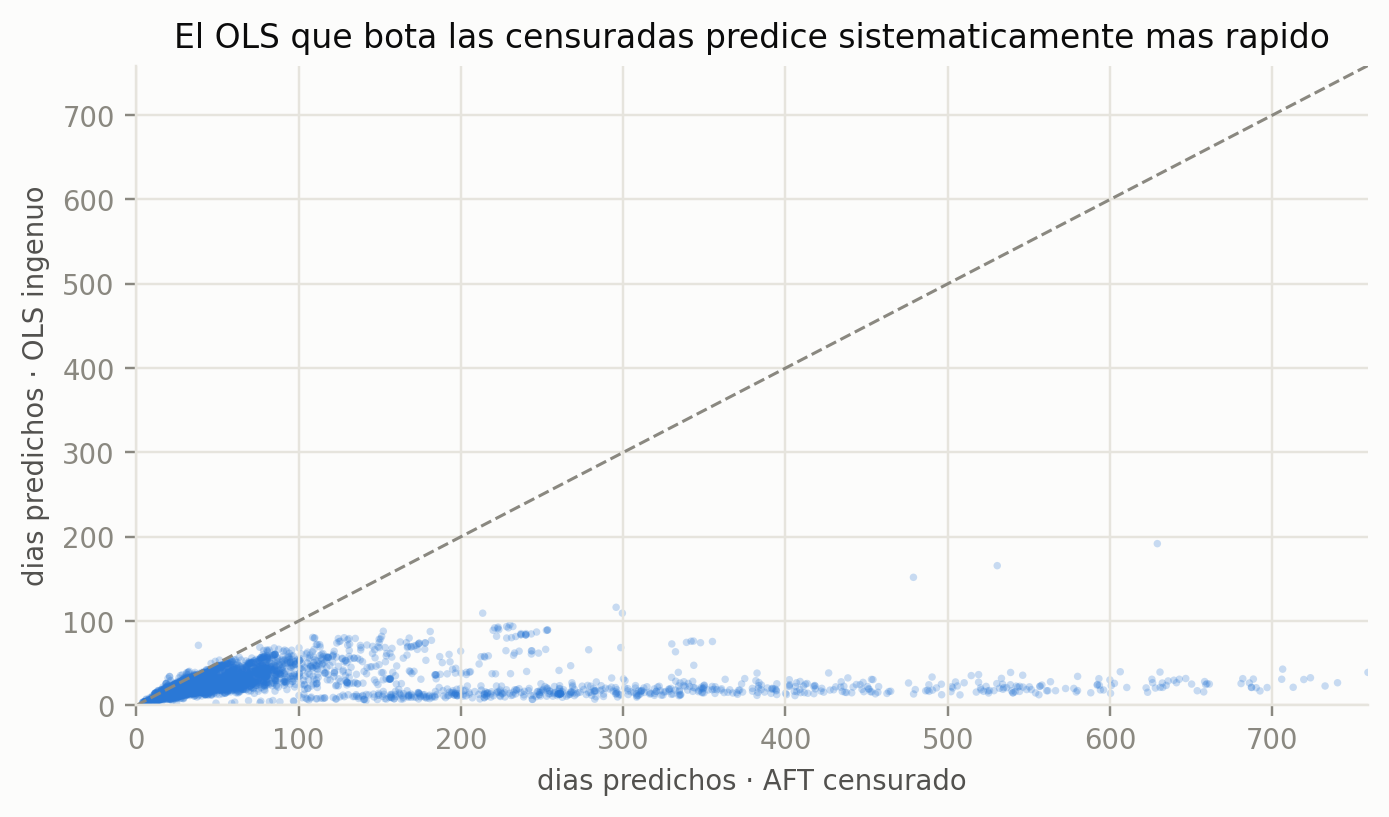

In [19]:
# Lo que solo el AFT entrega: dias predichos, y la comparacion contra el OLS
# ingenuo que bota las censuradas. La brecha entre los dos ES el sesgo.
y_enc = np.where(np.isfinite(y_rep), y_rep, np.nanmean(y_rep))
pre_full = diseno("lpa")
X_full = pre_full.fit_transform(D, y_enc)
logT_full = np.log(D["dias_obs"].clip(lower=1).to_numpy(float))
ev_full = D["evento_arriendo"].to_numpy(int)

aft_full = ajustar_aft(X_full, logT_full, ev_full, l2=1.0)
_, dias_aft, _ = curva_aft(aft_full, X_full)

from sklearn.linear_model import Ridge
dias_ols = np.exp(Ridge(alpha=1.0).fit(X_full[ev_full == 1],
                                       logT_full[ev_full == 1]).predict(X_full))

print(f"sigma del AFT: {aft_full['sigma']:.3f}   (convergio: {aft_full['conv']})")
print(f"Mediana de dias predicha · AFT censurado : {np.median(dias_aft):.1f}")
print(f"Mediana de dias predicha · OLS ingenuo   : {np.median(dias_ols):.1f}")
print(f"\nSesgo del OLS: {np.median(dias_ols) - np.median(dias_aft):+.1f} dias, "
      f"siempre optimista.")
print("Crece con la censura: en la cohorte mas nueva (73,9% censurada) el OLS")
print("solo ve las que ya se arrendaron.")

fig, ax = plt.subplots(figsize=(6.2, 3.6), constrained_layout=True)
ax.scatter(dias_aft, dias_ols, s=6, alpha=0.25, color=AZUL, edgecolor="none")
lim = [0, np.percentile(np.r_[dias_aft, dias_ols], 99)]
ax.plot(lim, lim, color=INK_MUTED, lw=1, ls="--")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("dias predichos · AFT censurado")
ax.set_ylabel("dias predichos · OLS ingenuo")
ax.set_title("El OLS que bota las censuradas predice sistematicamente mas rapido")
plt.show()

## Paso 10 · Modelo C — hazard discreto con riesgos competitivos

El problema que arrastran A y B: el churn (18,2%) no es censura. Una unidad dada de baja **no**
es una de la que "todavía no sabemos"; es una que ya no se va a arrendar. Tratarla como censura
reparte su masa entre las vivas y sobreestima la velocidad — justo en los segmentos lentos,
que son los de churn alto: Cerrillos y San Joaquín, con 43% de censura.

En vez de Fine-Gray, la versión en tiempo discreto, que se estima con lo que ya está instalado:

1. **Expandir** cada unidad a una fila por semana viva.
2. **Multinomial** sobre el desenlace de cada semana: `nada` / `arriendo` / `churn`.
3. **Recomponer** la incidencia acumulada:

   $$\text{CIF}_{\text{arr}}(k)=\sum_{j\le k} S(j-1)\,h_{\text{arr}}(j),\qquad
     S(j)=S(j-1)\big(1-h_{\text{arr}}(j)-h_{\text{churn}}(j)\big)$$

Da la curva completa descontando el churn, y admite covariables que cambian en el tiempo. La
semana entra como spline lineal por tramos en `log(k)` para que la forma del hazard sea libre.

In [20]:
def expandir(datos, k_max=K_SEMANAS):
    '''Una fila por (unidad, semana viva). El desenlace se marca en la ultima.'''
    t = datos["dias_obs"].to_numpy(float)
    sem_fin = np.clip(np.ceil(t / 7.0), 1, k_max).astype(int)
    trunca = (t / 7.0) > k_max
    idx = np.repeat(np.arange(len(datos)), sem_fin)
    semana = np.concatenate([np.arange(1, k + 1) for k in sem_fin])
    ultima = semana == np.repeat(sem_fin, sem_fin)
    arr = np.repeat(datos["evento_arriendo"].to_numpy(int), sem_fin)
    chu = np.repeat(datos["evento_churn"].to_numpy(int), sem_fin)
    tru = np.repeat(trunca.astype(int), sem_fin)
    y = np.zeros(len(idx), dtype=int)
    y[ultima & (arr == 1) & (tru == 0)] = 1
    y[ultima & (chu == 1) & (tru == 0)] = 2
    return idx, semana, y


def base_semana(semana):
    '''Spline lineal por tramos en log(semana): forma libre, 4 parametros.'''
    lg = np.log(np.asarray(semana, float))
    return np.column_stack([lg] + [np.clip(lg - n, 0, None) for n in np.log([2, 4, 8])])


def hazard(tr, te, modo="lpa", k_max=K_SEMANAS):
    y_enc = target_binario(tr, H_REPORTE)
    y_enc = np.where(np.isfinite(y_enc), y_enc, np.nanmean(y_enc))
    pre = diseno(modo)
    Xtr_u, Xte_u = pre.fit_transform(tr, y_enc), pre.transform(te)

    i_tr, s_tr, yy = expandir(tr, k_max)
    clf = LogisticRegression(penalty="l2", C=1.0, max_iter=3000)
    clf.fit(np.column_stack([Xtr_u[i_tr], base_semana(s_tr)]), yy)
    cls = list(clf.classes_)

    n, S = len(te), np.ones(len(te))
    cif_a = np.zeros((n, k_max)); cif_c = np.zeros((n, k_max))
    for k in range(1, k_max + 1):
        pr = clf.predict_proba(np.column_stack([Xte_u, base_semana(np.full(n, k))]))
        h1 = pr[:, cls.index(1)] if 1 in cls else np.zeros(n)
        h2 = pr[:, cls.index(2)] if 2 in cls else np.zeros(n)
        cif_a[:, k - 1] = (cif_a[:, k - 2] if k > 1 else 0) + S * h1
        cif_c[:, k - 1] = (cif_c[:, k - 2] if k > 1 else 0) + S * h2
        S = S * (1 - h1 - h2)

    # La CIF esta en semanas; la rejilla de evaluacion en dias.
    dias_k = np.arange(1, k_max + 1) * 7.0
    cif = np.column_stack([np.array([np.interp(h, dias_k, fila) for fila in cif_a])
                           for h in REJILLA_H])
    # dias predichos = primer momento en que la CIF cruza 0,5 (NaN si no cruza)
    dias = np.array([np.interp(0.5, fila, dias_k) if fila[-1] >= 0.5 else np.nan
                     for fila in cif_a])
    return {"cif": cif, "dias": dias, "riesgo": cif[:, REJILLA_H.index(H_REPORTE)],
            "_cif_a": cif_a, "_cif_c": cif_c}


t0 = time.time()
pred_C = evaluar(hazard, "C · hazard competitivo")
resultados.append(puntuar(pred_C))
print(f"{time.time() - t0:.0f}s")
display(pd.DataFrame(resultados).round(4))

5s


,modelo,n,C_index,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60,IBS,Brier@20,Calib_slope,CIL,MAE_dias
0,baseline segmento,2279,0.549,0.589,0.585,0.586,0.591,0.580,0.577,0.217,0.188,0.598,0.008,20.000
1,A · logistica ridge,2279,0.667,0.725,0.700,0.706,0.709,0.718,0.731,0.204,0.189,0.493,0.072,NaN
2,B · AFT log-normal,2279,0.685,0.724,0.722,0.726,0.728,0.731,0.735,0.196,0.174,0.719,0.057,19.639
3,C · hazard competitivo,2279,0.680,0.713,0.713,0.716,0.720,0.728,0.734,0.195,0.173,0.721,0.030,20.083


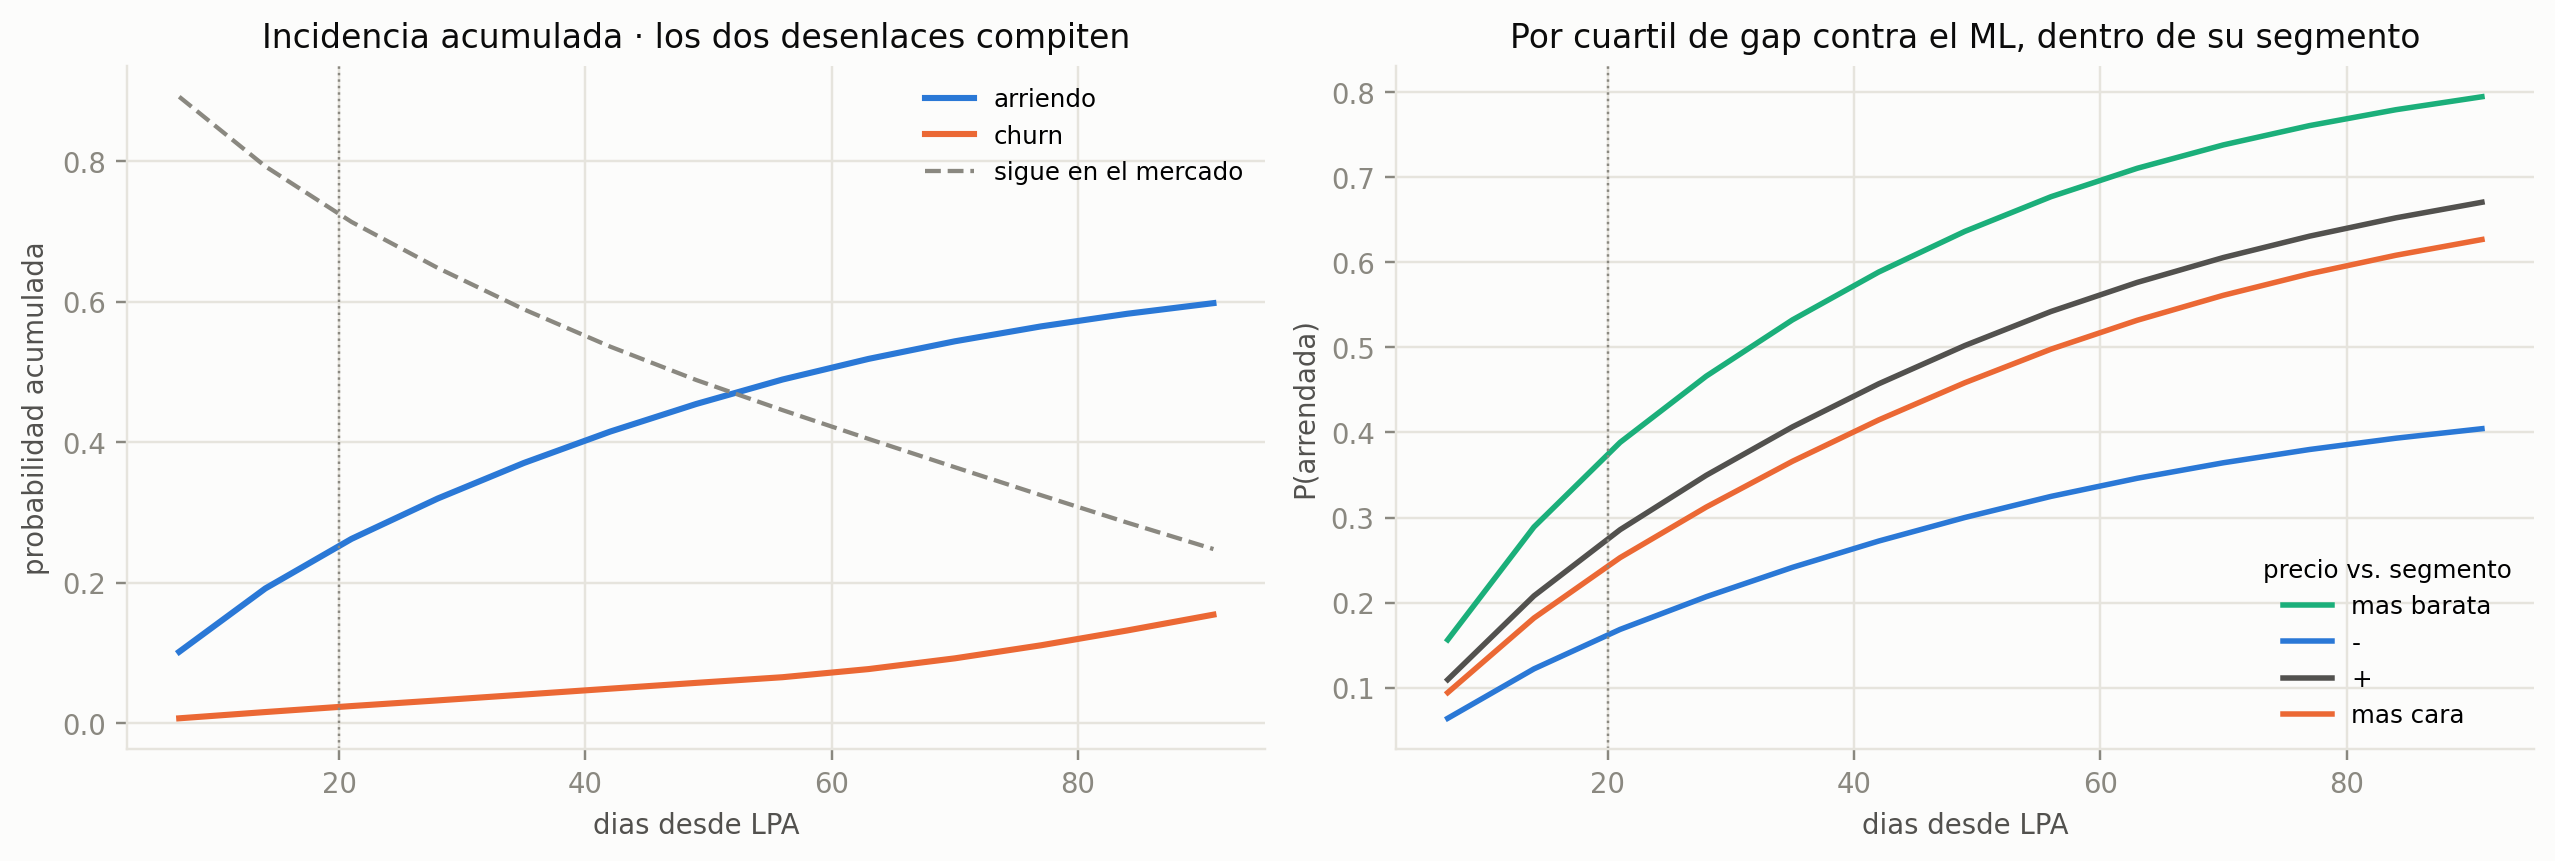

A los 20 dias, promedio de la muestra:
  P(arrendada) = 0.262
  P(churn)     = 0.024
Un modelo que trata el churn como censura reparte esa segunda masa entre
las vivas y devuelve una P(arriendo) mas alta de la que el negocio ve.


In [21]:
# Lo que solo el modelo C da: las dos curvas compitiendo, y el corte por gap.
r_full = hazard(D, D)
cif_a, cif_c = r_full["_cif_a"], r_full["_cif_c"]
dias_eje = np.arange(1, K_SEMANAS + 1) * 7

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), constrained_layout=True)

ax = axes[0]
ax.plot(dias_eje, cif_a.mean(axis=0), color=AZUL, lw=2, label="arriendo")
ax.plot(dias_eje, cif_c.mean(axis=0), color=NARANJA, lw=2, label="churn")
ax.plot(dias_eje, 1 - cif_a.mean(axis=0) - cif_c.mean(axis=0),
        color=INK_MUTED, lw=1.4, ls="--", label="sigue en el mercado")
ax.axvline(H_REPORTE, color=INK_MUTED, lw=0.8, ls=":")
ax.set_xlabel("dias desde LPA"); ax.set_ylabel("probabilidad acumulada")
ax.set_title("Incidencia acumulada · los dos desenlaces compiten")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
q = pd.qcut(D["gap_centrado"], 4, labels=["mas barata", "-", "+", "mas cara"],
            duplicates="drop")
for lab, col in zip(q.cat.categories, [AQUA, AZUL, INK_SOFT, NARANJA]):
    sel = (q == lab).to_numpy()
    if sel.sum():
        ax.plot(dias_eje, cif_a[sel].mean(axis=0), color=col, lw=1.8, label=str(lab))
ax.axvline(H_REPORTE, color=INK_MUTED, lw=0.8, ls=":")
ax.set_xlabel("dias desde LPA"); ax.set_ylabel("P(arrendada)")
ax.set_title("Por cuartil de gap contra el ML, dentro de su segmento")
ax.legend(frameon=False, fontsize=8, title="precio vs. segmento", title_fontsize=8)
plt.show()

k = int(np.ceil(H_REPORTE / 7)) - 1
print(f"A los {H_REPORTE} dias, promedio de la muestra:")
print(f"  P(arrendada) = {cif_a[:, k].mean():.3f}")
print(f"  P(churn)     = {cif_c[:, k].mean():.3f}")
print("Un modelo que trata el churn como censura reparte esa segunda masa entre")
print("las vivas y devuelve una P(arriendo) mas alta de la que el negocio ve.")

## Paso 11 · Modelo D — la cota superior no lineal

No es un candidato: es una medición. Gradient boosting sobre exactamente las mismas features y
el mismo esquema forward. Si le gana al lineal por mucho, hay estructura no lineal o
interacciones que vale la pena buscar y codificar a mano. Si le gana por poco, el lineal es la
respuesta y se queda con la interpretabilidad.

Las razones para esperar *algo* de ganancia están medidas: el decil 5 del gap era el más lento
de los diez (no monotonía), y el efecto del precio cambia de signo entre crudo y centrado
(interacción). La razón para esperar *poca*: esa interacción ya está codificada a mano en
`gap_centrado`, y con 3.834 filas un GBM pelea contra la varianza.

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

try:
    from lightgbm import LGBMClassifier
    def _gbm():
        return LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                              min_child_samples=40, subsample=0.8,
                              colsample_bytree=0.8, reg_lambda=1.0,
                              random_state=SEMILLA, verbose=-1)
    MOTOR = "lightgbm"
except ImportError:
    def _gbm():
        return HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
            min_samples_leaf=40, l2_regularization=1.0, random_state=SEMILLA)
    MOTOR = "sklearn HistGradientBoosting"
print(f"Motor: {MOTOR}")


def gbm(tr, te, modo="lpa"):
    cif = np.zeros((len(te), len(REJILLA_H)))
    for j, h in enumerate(REJILLA_H):
        y = target_binario(tr, h)
        m = np.isfinite(y)
        if m.sum() < 100 or len(np.unique(y[m])) < 2:
            cif[:, j] = float(np.nanmean(y)) if m.sum() else 0.5
            continue
        pipe = Pipeline([("pre", diseno(modo)), ("clf", _gbm())])
        pipe.fit(tr[m], y[m])
        cif[:, j] = pipe.predict_proba(te)[:, 1]
    cif = np.maximum.accumulate(cif, axis=1)
    return {"cif": cif, "dias": None, "riesgo": cif[:, REJILLA_H.index(H_REPORTE)]}


t0 = time.time()
pred_D = evaluar(gbm, "D · gradient boosting")
resultados.append(puntuar(pred_D))
print(f"{time.time() - t0:.0f}s")

Motor: sklearn HistGradientBoosting
41s


## Paso 12 · La comparación, en las dos escalas

Todo con el mismo esquema forward, las mismas features y la misma muestra. Cómo se lee:

**Columna que decide entre modelos de duración: `IBS`** (menor es mejor). Integra el error de
la probabilidad sobre toda la rejilla de horizontes y usa las censuradas vía IPCW. Es la única
cifra que evalúa la curva entera.

**Columna que decide si el modelo sirve: `ΔAUC` contra el baseline** en el horizonte de
reporte. Si es chica, el problema no es el algoritmo.

**`C_index`** dice si el orden es correcto sin comprometerse con ningún horizonte. Un modelo
puede tener C-index alto y AUC@20 mediocre: ordena bien en general pero el corte a 20 días cae
donde no discrimina.

**`MAE_dias`** solo existe para los modelos que predicen días, y está calculado únicamente
entre las arrendadas — así que subestima el error de las lentas. Es el número que la gente
quiere ver, con esa advertencia.

Las columnas `AUC@h` son la respuesta directa a "¿es 20 el horizonte correcto?": si el AUC
sube fuerte hasta 30 y ahí se aplana, el corte del proyecto está dejando señal sobre la mesa.

In [23]:
tabla = pd.DataFrame(resultados).set_index("modelo")
base_auc = tabla.loc["baseline segmento", f"AUC@{H_REPORTE}"]
base_ibs = tabla.loc["baseline segmento", "IBS"]
tabla["dAUC"] = tabla[f"AUC@{H_REPORTE}"] - base_auc
tabla["dIBS"] = tabla["IBS"] - base_ibs

cols_dur = ["n", "C_index", "IBS", "dIBS", "MAE_dias"]
cols_bin = [f"AUC@{h}" for h in REJILLA_H] + [f"Brier@{H_REPORTE}", "Calib_slope", "CIL"]

print("=== ESCALA DE DURACION (usa las censuradas) ===")
display(tabla[cols_dur].round(4))
print(f"=== ESCALA BINARIA (horizonte de reporte: {H_REPORTE} dias) ===")
display(tabla[cols_bin + ["dAUC"]].round(4))

=== ESCALA DE DURACION (usa las censuradas) ===


,n,C_index,IBS,dIBS,MAE_dias
modelo,,,,,
baseline segmento,2279,0.549,0.217,0.000,20.000
A · logistica ridge,2279,0.667,0.204,-0.013,NaN
B · AFT log-normal,2279,0.685,0.196,-0.021,19.639
C · hazard competitivo,2279,0.680,0.195,-0.022,20.083
D · gradient boosting,2279,0.677,0.201,-0.016,NaN


=== ESCALA BINARIA (horizonte de reporte: 20 dias) ===


,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60,Brier@20,Calib_slope,CIL,dAUC
modelo,,,,,,,,,,
baseline segmento,0.589,0.585,0.586,0.591,0.580,0.577,0.188,0.598,0.008,0.000
A · logistica ridge,0.725,0.700,0.706,0.709,0.718,0.731,0.189,0.493,0.072,0.120
B · AFT log-normal,0.724,0.722,0.726,0.728,0.731,0.735,0.174,0.719,0.057,0.140
C · hazard competitivo,0.713,0.713,0.716,0.720,0.728,0.734,0.173,0.721,0.030,0.130
D · gradient boosting,0.717,0.718,0.731,0.728,0.726,0.739,0.174,0.606,0.057,0.145


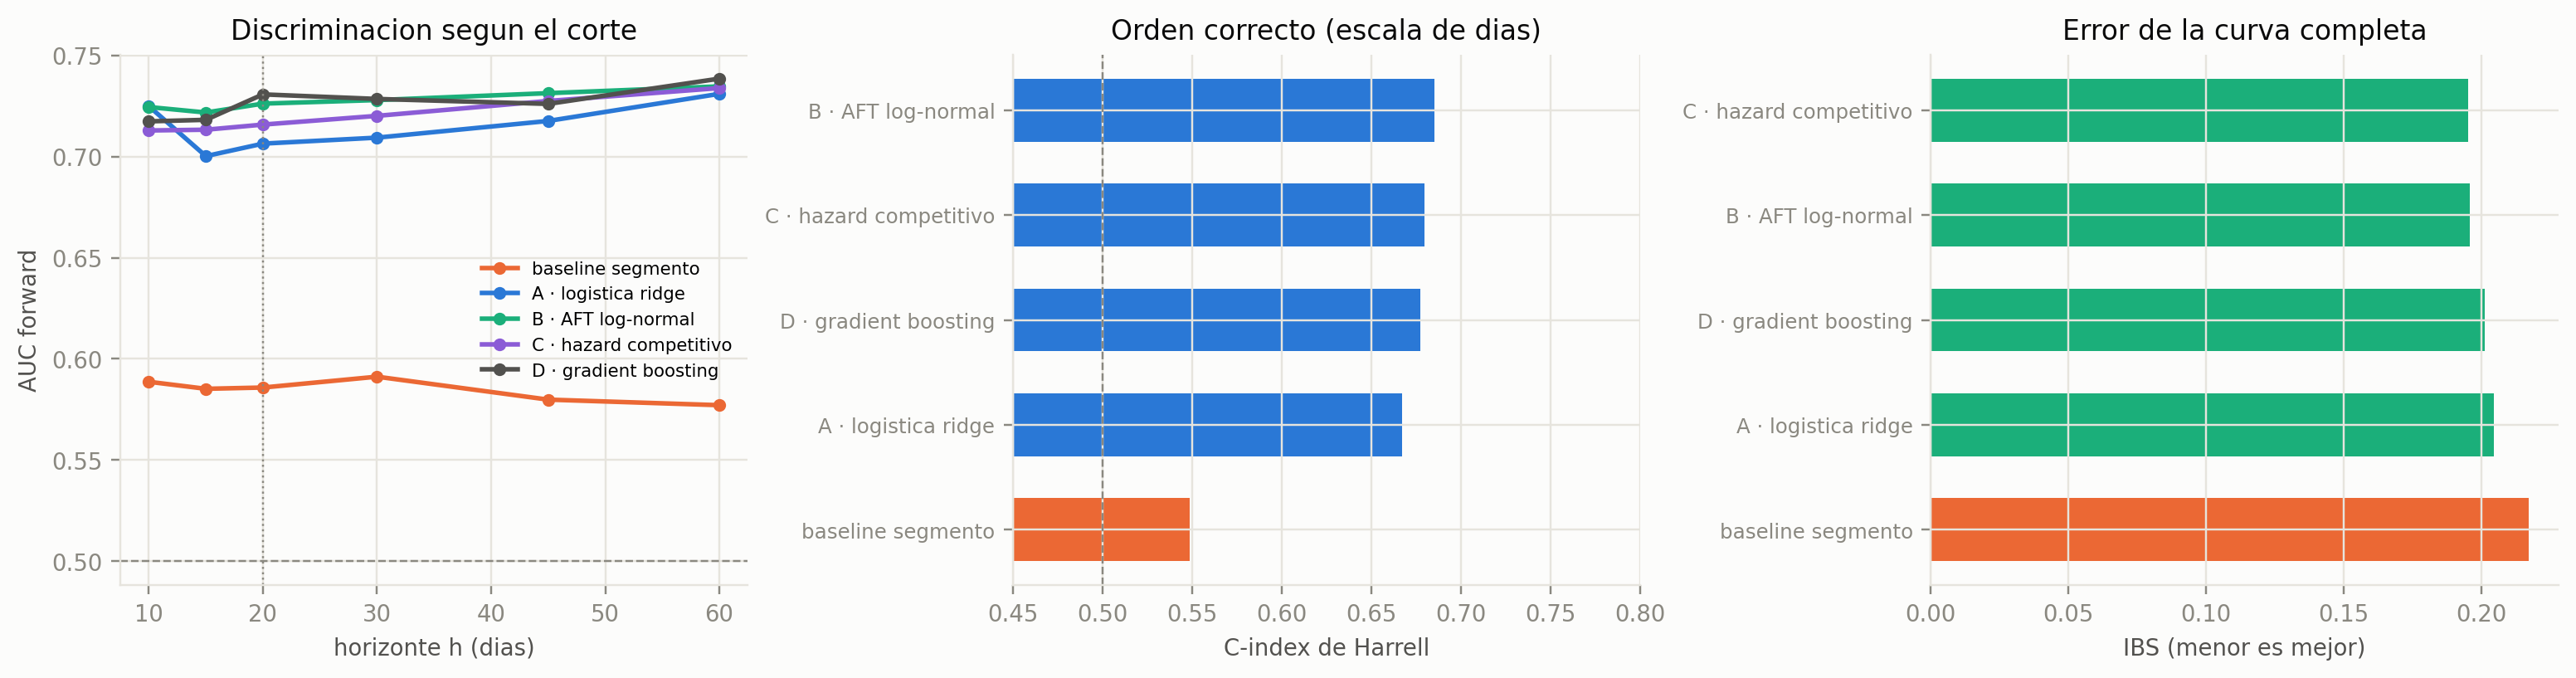

Mejor en escala binaria (AUC@20) : D · gradient boosting  (+0.145 sobre el baseline)
Mejor en escala de duracion (IBS)       : C · hazard competitivo  (-0.0218 sobre el baseline)

Ganan modelos distintos en cada escala. Eso NO es un empate: significa que
hay que elegir por el uso. Si el entregable es una probabilidad a un plazo
fijo, manda la escala binaria; si es un 'cuanto va a demorar' o un ranking
de cartera, manda el C-index y el IBS.

El horizonte con mejor AUC entre todos los modelos es 60d, no 20d.
Contrastar contra la observabilidad del Paso 5 antes de cambiar el target.


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)

# 1 - AUC por horizonte: responde "es 20 el corte correcto"
ax = axes[0]
for (nom, fila), col in zip(tabla.iterrows(), [NARANJA, AZUL, AQUA, VIOLETA, INK_SOFT]):
    ax.plot(REJILLA_H, [fila[f"AUC@{h}"] for h in REJILLA_H], "o-",
            color=col, lw=1.8, ms=4, label=nom)
ax.axvline(H_REPORTE, color=INK_MUTED, lw=0.8, ls=":")
ax.axhline(0.5, color=INK_MUTED, lw=0.8, ls="--")
ax.set_xlabel("horizonte h (dias)"); ax.set_ylabel("AUC forward")
ax.set_title("Discriminacion segun el corte"); ax.legend(frameon=False, fontsize=7)

# 2 - C-index: la escala de duracion, sin comprometerse con un horizonte
ax = axes[1]
o = tabla.sort_values("C_index")
ax.barh(range(len(o)), o["C_index"],
        color=[NARANJA if i == "baseline segmento" else AZUL for i in o.index], height=0.6)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index, fontsize=8)
ax.axvline(0.5, color=INK_MUTED, lw=0.8, ls="--")
ax.set_xlim(0.45, max(0.8, o["C_index"].max() + 0.05))
ax.set_xlabel("C-index de Harrell"); ax.set_title("Orden correcto (escala de dias)")

# 3 - IBS: la cifra que decide entre modelos de duracion
ax = axes[2]
o = tabla.sort_values("IBS", ascending=False)
ax.barh(range(len(o)), o["IBS"],
        color=[NARANJA if i == "baseline segmento" else AQUA for i in o.index], height=0.6)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index, fontsize=8)
ax.set_xlabel("IBS (menor es mejor)"); ax.set_title("Error de la curva completa")
plt.show()

mejor_bin = tabla[f"AUC@{H_REPORTE}"].idxmax()
mejor_dur = tabla["IBS"].idxmin()
print(f"Mejor en escala binaria (AUC@{H_REPORTE}) : {mejor_bin}  "
      f"({tabla.loc[mejor_bin, 'dAUC']:+.3f} sobre el baseline)")
print(f"Mejor en escala de duracion (IBS)       : {mejor_dur}  "
      f"({tabla.loc[mejor_dur, 'dIBS']:+.4f} sobre el baseline)")
if mejor_bin != mejor_dur:
    print("\nGanan modelos distintos en cada escala. Eso NO es un empate: significa que")
    print("hay que elegir por el uso. Si el entregable es una probabilidad a un plazo")
    print("fijo, manda la escala binaria; si es un 'cuanto va a demorar' o un ranking")
    print("de cartera, manda el C-index y el IBS.")

h_mejor = max(REJILLA_H, key=lambda h: np.nanmax(tabla[f"AUC@{h}"].to_numpy()))
if h_mejor != H_REPORTE:
    print(f"\nEl horizonte con mejor AUC entre todos los modelos es {h_mejor}d, "
          f"no {H_REPORTE}d.")
    print("Contrastar contra la observabilidad del Paso 5 antes de cambiar el target.")

## Paso 13 · El modelo landmark del día 7

Un producto distinto: no apoya la decisión de precio, dispara una alerta a la semana de
publicada la unidad. Se evalúa sobre las que llegaron vivas al día 7 (89,0%) y predice el
arriendo de ahí en adelante.

Es la parte con más señal disponible según el análisis: con ≥1 lead en los días 0-7, `y_8a20`
= 0,388 contra 0,124 sin ninguno — 3,1×. El límite es la cobertura: 2.813 de 3.412 unidades
tienen **cero** leads esa semana, así que la variable es casi binaria.

Las `d0_7_*` son legítimas acá y no lo son en el día 0: son pasado respecto del período que se
predice.

In [25]:
L = preparar(d[d["sobrevive_d7"] == 1]).reset_index(drop=True)
folds_L = [(np.where(L["cohorte_lpa"].isin(COHORTES[:i]))[0],
            np.where(L["cohorte_lpa"] == COHORTES[i])[0])
           for i in range(MIN_TRAIN, len(COHORTES)) if COHORTES[i] in EVALUABLES]
folds_L = [(tr, te) for tr, te in folds_L if len(tr) >= 200 and len(te) >= 30]
print(f"Sobreviven al dia 7: {len(L):,} de {len(D):,} ({len(L)/len(D):.1%}) · "
      f"{len(folds_L)} folds")

res_lm = []
for etq, fn in [
    ("landmark · solo dia 0",       lambda tr, te: logistica(tr, te, modo="lpa")),
    ("landmark · con demanda d0-7", lambda tr, te: logistica(tr, te, modo="landmark")),
    ("landmark · GBM con demanda",  lambda tr, te: gbm(tr, te, modo="landmark")),
]:
    res_lm.append(puntuar(evaluar(fn, etq, datos=L, folds=folds_L)))

tabla_lm = pd.DataFrame(res_lm).set_index("modelo")
display(tabla_lm[["n", "C_index", "IBS"] + [f"AUC@{h}" for h in REJILLA_H]].round(4))

if len(tabla_lm) >= 2:
    g = tabla_lm.iloc[1][f"AUC@{H_REPORTE}"] - tabla_lm.iloc[0][f"AUC@{H_REPORTE}"]
    gc = tabla_lm.iloc[1]["C_index"] - tabla_lm.iloc[0]["C_index"]
    print(f"\nLo que aporta la demanda de la primera semana: "
          f"{g:+.3f} de AUC y {gc:+.3f} de C-index.")
    print("Si es grande, el producto de mayor valor es la alerta semanal y no el")
    print("score del dia 0. Son dos entregables, no dos versiones del mismo.")

Sobreviven al dia 7: 3,483 de 3,901 (89.3%) · 7 folds


,n,C_index,IBS,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60
modelo,,,,,,,,,
landmark · solo dia 0,2026,0.656,0.190,0.675,0.683,0.683,0.684,0.697,0.710
landmark · con demanda d0-7,2026,0.685,0.170,0.730,0.733,0.738,0.737,0.746,0.755
landmark · GBM con demanda,2026,0.659,0.172,0.647,0.700,0.728,0.744,0.746,0.758



Lo que aporta la demanda de la primera semana: +0.055 de AUC y +0.029 de C-index.
Si es grande, el producto de mayor valor es la alerta semanal y no el
score del dia 0. Son dos entregables, no dos versiones del mismo.


## Paso 14 · Qué aprendió el modelo

Coeficientes del modelo A ajustado sobre toda la muestra. **Son asociaciones, no efectos
causales**, y una en particular no se puede leer causalmente: el precio crudo predice *más
rápido* (−10,9 días entre deciles, por confusión con comuna) y el gap centrado predice *más
lento* (+13,2 días). El coeficiente de `log_precio` está condicionado a todo lo demás y no
significa "subir el precio acelera".

La curva del gap es lo que sí interesa: el análisis encontró que **no es monótona** — el decil
5 era el más lento. Si la curva predicha sale recta y la observada dibuja una U, es el lineal
quedándose corto, y ahí es donde el GBM justificaría su costo.

C = 3.728  ·  43 parametros  ·  EPV = 22.0


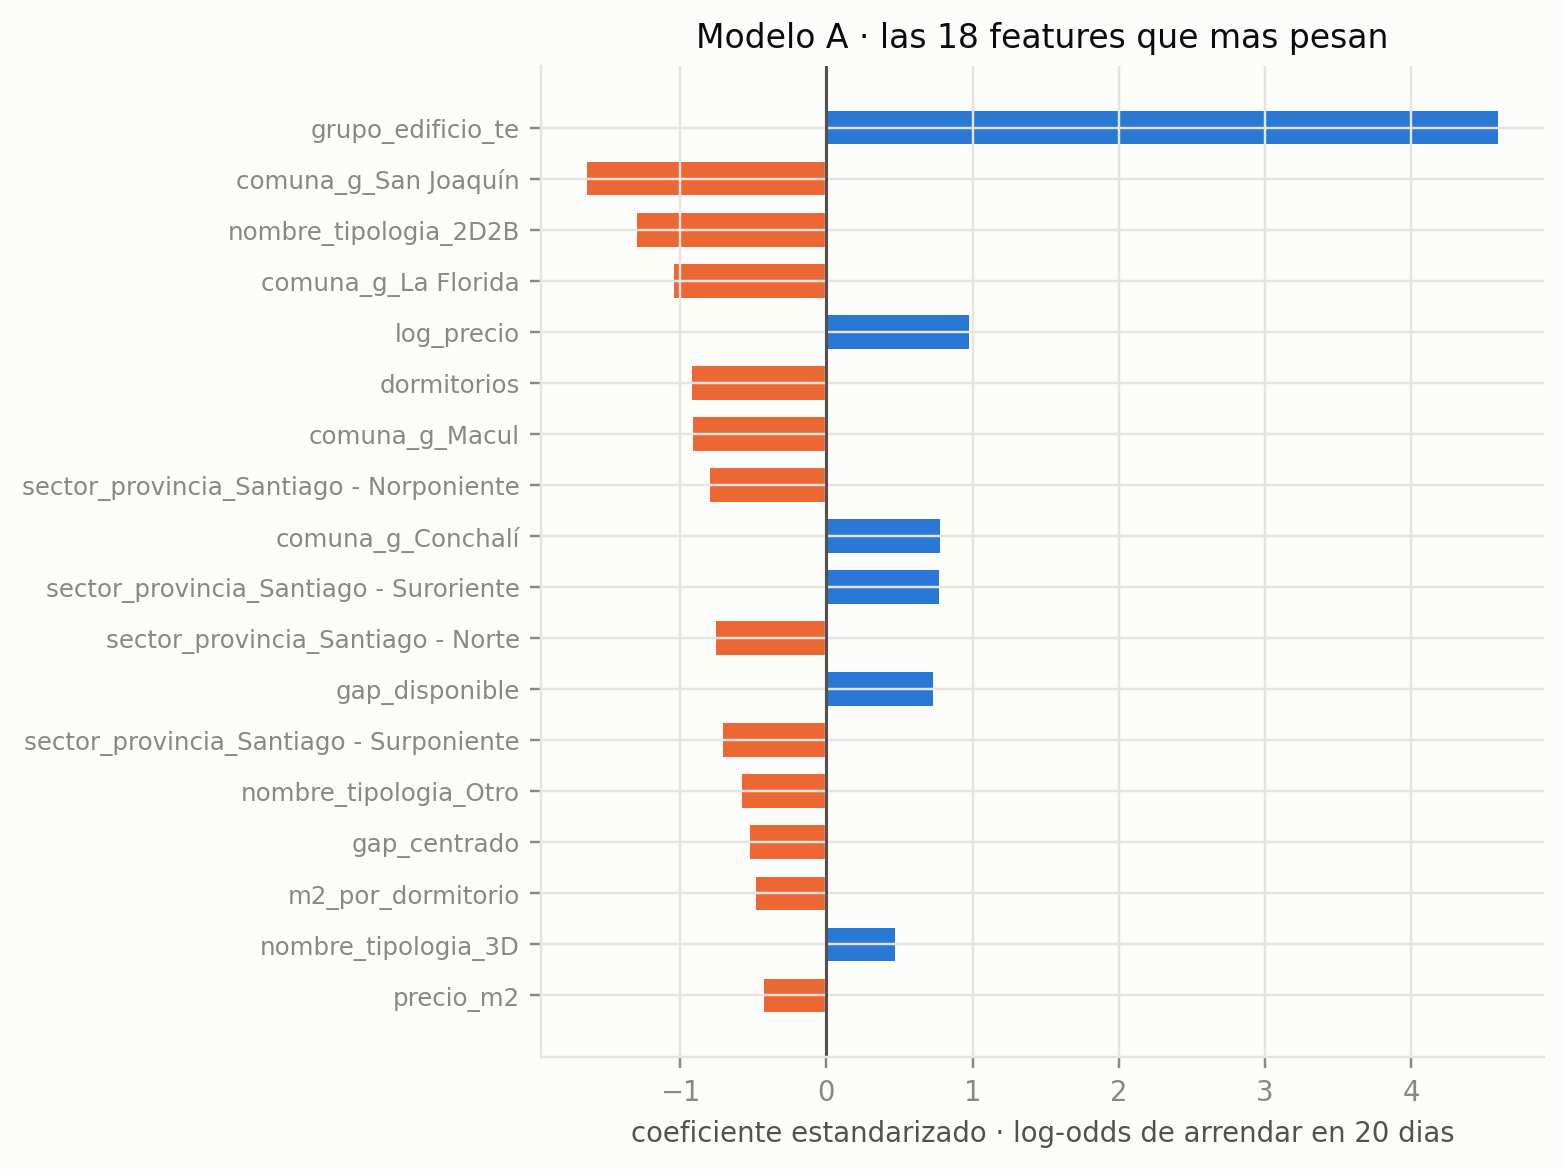

In [26]:
modelo_final = Pipeline([("pre", diseno("lpa")),
                         ("clf", LogisticRegression(C=C_ELEGIDO, max_iter=5000))])
modelo_final.fit(D[m_rep], y_rep[m_rep])
clf_b = modelo_final.named_steps["clf"]
try:
    nombres = [n.split("__")[-1]
               for n in modelo_final.named_steps["pre"].get_feature_names_out()]
except Exception:
    nombres = [f"f{i}" for i in range(len(clf_b.coef_[0]))]

coef = (pd.DataFrame({"feature": nombres, "coef": clf_b.coef_[0]})
          .assign(abs_coef=lambda t: t["coef"].abs())
          .sort_values("abs_coef", ascending=False))
eventos = min(y_rep[m_rep].sum(), (1 - y_rep[m_rep]).sum())
print(f"C = {C_ELEGIDO:.4g}  ·  {len(nombres)} parametros  ·  "
      f"EPV = {eventos / len(nombres):.1f}")

top = coef.head(18).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5.2), constrained_layout=True)
ax.barh(range(len(top)), top["coef"],
        color=[AZUL if v > 0 else NARANJA for v in top["coef"]], height=0.66)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top["feature"], fontsize=8)
ax.axvline(0, color=INK_SOFT, lw=1)
ax.set_xlabel(f"coeficiente estandarizado · log-odds de arrendar en {H_REPORTE} dias")
ax.set_title("Modelo A · las 18 features que mas pesan")
plt.show()

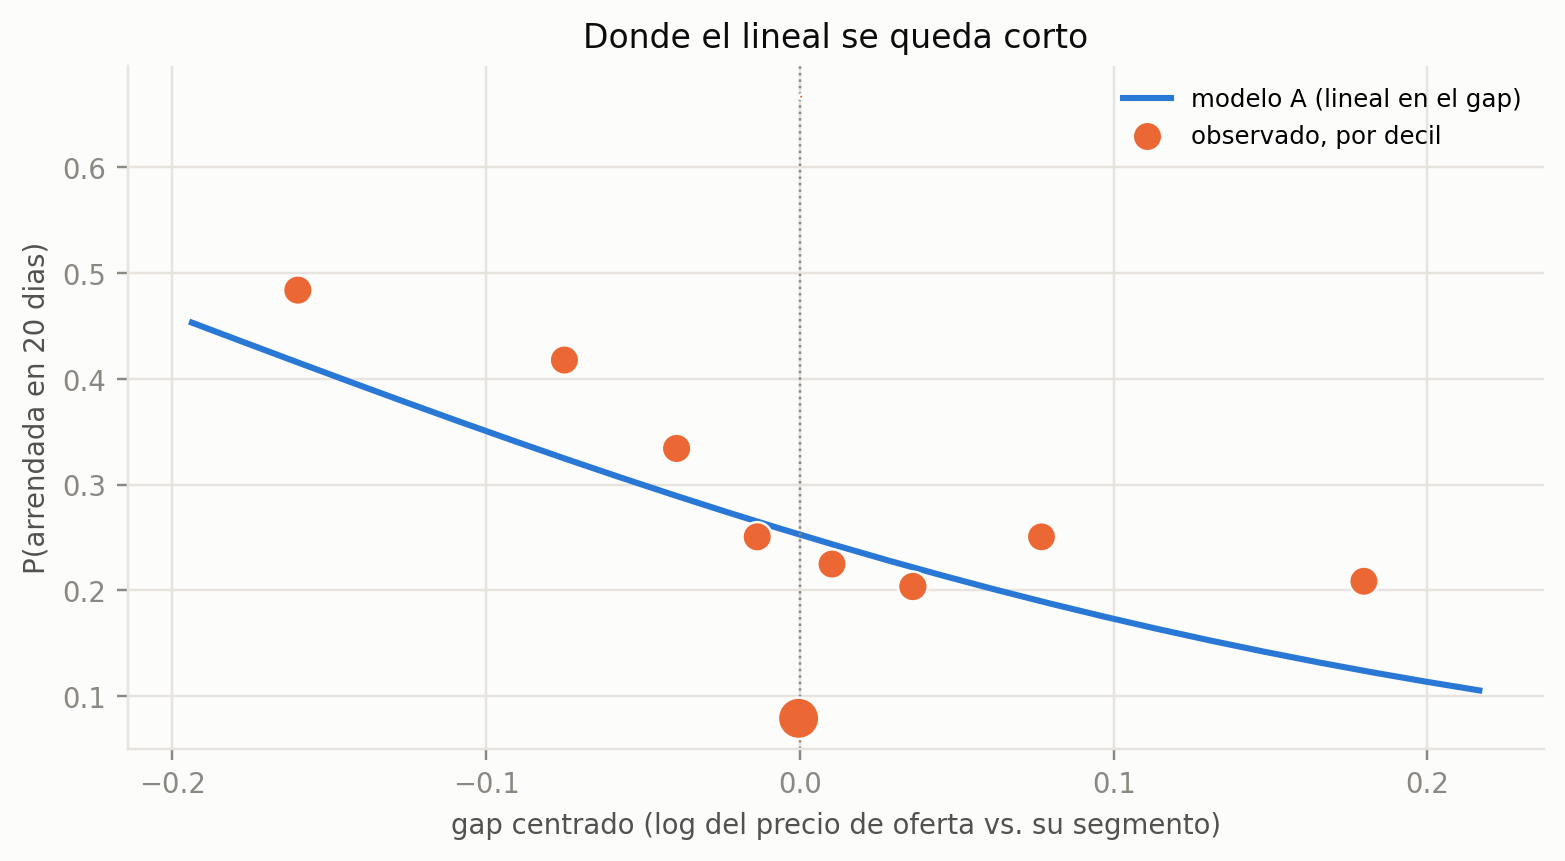

Si los puntos naranjas dibujan una U y la linea azul es recta, el efecto del
precio no es lineal: meter un spline en gap_centrado antes de concluir que
hace falta un GBM por razones mas profundas.


In [27]:
# La curva del gap: predicha contra observada.
rejilla = np.linspace(D["gap_centrado"].quantile(0.02),
                      D["gap_centrado"].quantile(0.98), 25)
curva = []
for v in rejilla:
    tmp = D[m_rep].copy()
    tmp["gap_centrado"] = v
    curva.append(modelo_final.predict_proba(tmp)[:, 1].mean())

obs_dec = (pd.DataFrame({"g": D.loc[m_rep, "gap_centrado"], "y": y_rep[m_rep],
                         "b": pd.qcut(D.loc[m_rep, "gap_centrado"], 10,
                                      duplicates="drop")})
             .groupby("b", observed=True)
             .agg(x=("g", "mean"), y=("y", "mean"), n=("y", "size")))

fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
ax.plot(rejilla, curva, color=AZUL, lw=2, label="modelo A (lineal en el gap)")
ax.scatter(obs_dec["x"], obs_dec["y"], s=obs_dec["n"] / 4, color=NARANJA, zorder=3,
           edgecolor=SURFACE, linewidth=0.8, label="observado, por decil")
ax.axvline(0, color=INK_MUTED, lw=0.8, ls=":")
ax.set_xlabel("gap centrado (log del precio de oferta vs. su segmento)")
ax.set_ylabel(f"P(arrendada en {H_REPORTE} dias)")
ax.set_title("Donde el lineal se queda corto")
ax.legend(frameon=False, fontsize=8)
plt.show()

print("Si los puntos naranjas dibujan una U y la linea azul es recta, el efecto del")
print("precio no es lineal: meter un spline en gap_centrado antes de concluir que")
print("hace falta un GBM por razones mas profundas.")

## Paso 15 · Barrio y macro

Dos bloques de variables nuevas y una pregunta que hay que desarmar antes de contestarla.

### Por qué la pregunta tiene dos versiones

"¿Los efectos fijos por mes absorben el efecto macroeconómico?" mezcla dos cosas:

**La versión inferencial: sí, al 100%, y por construcción.** La tasa de desempleo nacional toma
un solo valor por mes. Las dummies de mes también. Cualquier variable constante dentro del mes
es una combinación lineal exacta de esas dummies: al meter las dos juntas, el coeficiente de la
macro **no está identificado** — no es que salga chico o no significativo, es que no existe. La
celda de colinealidad lo muestra con un R² que da 1,000 exacto. Con 14 cohortes, además, el
`n` efectivo de cualquier variable macro es **14**, no 3.834: por muchas unidades que haya, hay
catorce observaciones de la macro.

**La versión predictiva: los efectos fijos de mes ni siquiera son una feature.** En validación
*forward* se entrena hasta el mes `m` y se predice el mes `m+1`. La dummy de `m+1` nunca se vio
en entrenamiento y vale cero para todas las filas de test. Un efecto fijo de mes **no puede
predecir un mes nuevo**. La macro sí puede, porque es un número que existe para el mes que
viene. Ahí es donde puede aportar algo que las dummies no.

Así que la respuesta corta es: los efectos fijos absorben la macro completamente cuando ambos
están en el modelo, y no absorben nada cuando el modelo tiene que predecir hacia adelante,
porque ahí no sirven. Lo que sí se puede medir —y es lo que hace este paso— es si la macro
aporta **por encima de la estacionalidad que ya está en el modelo** (`mes_sin`, `mes_cos`).

### La única macro que puede sobrevivir a un efecto fijo de mes

Una que **varíe dentro del mes**. Los archivos por segmento etario lo permiten: si a cada
unidad se le asigna la tasa del grupo que plausiblemente la arrienda (estudios y 1D a los
20-29, 3D a los 30-34), la variable pasa a variar por `mes × tipología` y deja de ser
colineal con las dummies de mes solas. Las series lo justifican: la correlación entre la tasa
nacional y la de 30-34 es 0,78, y entre 25-29 y 30-34 es 0,57 — no son la misma serie.

### Rezago

La última observación de las cuatro series es **2026-06** y la última cohorte es 2026-08. El
INE publica con desfase, así que un score calculado hoy no tiene el dato del mes en curso. Se
usa un rezago de 2 meses, que es lo que estaría disponible de verdad al momento de publicar
una unidad. Sin ese rezago la variable sería imposible de calcular en producción.

### Y el barrio

Aparte de la macro, este paso agrega los promedios de barrio, que sí son una apuesta
predictiva seria: el análisis mostró que la ubicación domina todo (`y_20` de 0,02 a 0,87 entre
edificios), y el barrio es el nivel intermedio entre `comuna` (26 niveles, ya en el modelo) y
`grupo_edificio` (796, ya con target encoding). Se agregan cuatro cosas, todas calculadas
**solo con el train de cada fold**: el target encoding del barrio, su precio/m² y superficie
típicos, el precio de la unidad relativo al de su barrio, y la **competencia** — cuántas
unidades del mismo barrio y del mismo edificio salieron a mercado en los 30 días anteriores.
Esa última es la única variable de oferta del proyecto y no necesita separación train/test:
cuenta LPAs pasadas, que están disponibles el día 0.

In [28]:
# --- Panel macro mensual ----------------------------------------------------
# Los cuatro Excel del Banco Central / INE. Hoja "Cuadro", frecuencia mensual,
# unidades en miles de personas. El nacional trae totales; los de segmento
# etario traen fuerza de trabajo y desocupados separados por genero.
LAG_MESES = 2      # desfase de publicacion: lo que de verdad estaria disponible

ARCHIVOS = {
    "nacional": "desempleo_nacional.xlsx",
    "20_24":    "desempleo_20_24.xlsx",
    "25_29":    "desempleo_25_29.xlsx",
    "30_34":    "desempleo_30_34.xlsx",
}


def leer_desempleo(path):
    '''Devuelve tasa total y, cuando existe, las tasas por genero.'''
    x = pd.read_excel(path, sheet_name="Cuadro", header=0)
    x["Periodo"] = pd.to_datetime(x["Periodo"])
    fz = [c for c in x.columns if "fuerza" in c.lower()]
    de = [c for c in x.columns if "desocup" in c.lower()]
    out = pd.DataFrame({"periodo": x["Periodo"]})
    out["tasa"] = 100 * x[de].sum(axis=1) / x[fz].sum(axis=1)
    for g in ("mujeres", "hombres"):
        f = [c for c in fz if g in c.lower()]
        d = [c for c in de if g in c.lower()]
        if f and d:
            out[f"tasa_{g}"] = 100 * x[d[0]] / x[f[0]]
    return out.set_index("periodo")


macro = pd.DataFrame()
for nombre, arch in ARCHIVOS.items():
    s = leer_desempleo(arch)
    macro[f"tasa_{nombre}"] = s["tasa"]
    if "tasa_mujeres" in s:
        macro[f"tasa_{nombre}_muj"] = s["tasa_mujeres"]
        macro[f"tasa_{nombre}_hom"] = s["tasa_hombres"]

# Variacion interanual: el nivel de la tasa y su direccion no son lo mismo.
for c in [f"tasa_{k}" for k in ARCHIVOS]:
    macro[f"d12_{c}"] = macro[c] - macro[c].shift(12)

macro = macro.sort_index()
macro["cohorte_objetivo"] = (macro.index + pd.DateOffset(months=LAG_MESES)).strftime("%Y-%m")
print(f"Panel macro: {macro.index.min():%Y-%m} a {macro.index.max():%Y-%m} "
      f"· {macro.shape[1] - 1} series")

cob = macro.set_index("cohorte_objetivo").reindex(COHORTES)
print(f"\nCohortes del estudio cubiertas con rezago de {LAG_MESES} meses: "
      f"{cob['tasa_nacional'].notna().sum()} de {len(COHORTES)}")
display(cob[["tasa_nacional", "tasa_20_24", "tasa_25_29", "tasa_30_34"]].round(2))

Panel macro: 2010-03 a 2026-06 · 14 series

Cohortes del estudio cubiertas con rezago de 2 meses: 14 de 15


,tasa_nacional,tasa_20_24,tasa_25_29,tasa_30_34
cohorte_objetivo,,,,
2025-07,8.940,20.810,13.390,8.530
2025-08,8.890,20.190,13.650,8.450
2025-09,8.700,19.980,13.240,7.940
2025-10,8.560,18.710,12.820,7.540
2025-11,8.530,18.210,12.760,7.500
2025-12,8.450,19.070,12.890,7.140
2026-01,8.420,19.470,12.900,7.430
2026-02,8.050,20.020,11.770,7.500
2026-03,8.280,19.750,11.640,7.800


In [29]:
# --- Union con la muestra, y la variable expuesta por edad ------------------
# El supuesto: quien arrienda un estudio o un 1D esta mayoritariamente en los
# 20-29; un 3D lo arrienda un hogar mas formado, 30-34. Los pesos son un juicio
# explicito, no un dato — cambiarlos aca y volver a correr es el sensibilidad.
PESOS_EDAD = {
    "Estudio": {"20_24": 0.45, "25_29": 0.45, "30_34": 0.10},
    "1D1B":    {"20_24": 0.30, "25_29": 0.50, "30_34": 0.20},
    "1D2B":    {"20_24": 0.25, "25_29": 0.50, "30_34": 0.25},
    "2D1B":    {"20_24": 0.15, "25_29": 0.45, "30_34": 0.40},
    "2D2B":    {"20_24": 0.10, "25_29": 0.40, "30_34": 0.50},
    "3D":      {"20_24": 0.05, "25_29": 0.30, "30_34": 0.65},
}
PESOS_DEFECTO = {"20_24": 0.20, "25_29": 0.45, "30_34": 0.35}

mac = macro.set_index("cohorte_objetivo")
COLS_MACRO_NAC = ["tasa_nacional", "d12_tasa_nacional"]
COLS_MACRO_EXP = ["tasa_expuesta", "d12_tasa_expuesta"]

for c in COLS_MACRO_NAC:
    D[c] = D["cohorte_lpa"].map(mac[c])

for base, destino in [("tasa", "tasa_expuesta"), ("d12_tasa", "d12_tasa_expuesta")]:
    val = np.zeros(len(D))
    for tip, pesos in list(PESOS_EDAD.items()) + [("__otras__", PESOS_DEFECTO)]:
        sel = (D["nombre_tipologia"] == tip) if tip != "__otras__" else \
              (~D["nombre_tipologia"].isin(PESOS_EDAD))
        if not sel.any():
            continue
        acum = np.zeros(sel.sum())
        for seg, w in pesos.items():
            acum += w * D.loc[sel, "cohorte_lpa"].map(mac[f"{base}_{seg}"]).to_numpy(float)
        val[sel.to_numpy()] = acum
    D[destino] = val

COLS_MACRO = COLS_MACRO_NAC + COLS_MACRO_EXP
for c in COLS_MACRO:
    D[c] = pd.to_numeric(D[c], errors="coerce")
    D[c] = D[c].fillna(D[c].mean())

print("Variacion de cada serie DENTRO de la muestra:")
print(D[COLS_MACRO].describe().loc[["mean", "std", "min", "max"]].round(3).to_string())
print(f"\nValores distintos de tasa_nacional : {D['tasa_nacional'].nunique()}  "
      f"(= numero de cohortes: {D['cohorte_lpa'].nunique()})")
print(f"Valores distintos de tasa_expuesta : {D['tasa_expuesta'].nunique()}  "
      f"(= cohortes x tipologias)")

Variacion de cada serie DENTRO de la muestra:
      tasa_nacional  d12_tasa_nacional  tasa_expuesta  d12_tasa_expuesta
mean          8.685              0.153         13.100              0.450
std           0.432              0.270          1.910              0.706
min           8.050             -0.340          9.409             -0.818
max           9.441              0.630         17.553              1.982

Valores distintos de tasa_nacional : 15  (= numero de cohortes: 15)
Valores distintos de tasa_expuesta : 83  (= cohortes x tipologias)


In [30]:
# --- LA CELDA QUE CONTESTA LA PREGUNTA -------------------------------------
from sklearn.linear_model import LinearRegression

Xmes = pd.get_dummies(D["cohorte_lpa"], drop_first=True).to_numpy(float)
Xmes_tip = pd.get_dummies(D["cohorte_lpa"].astype(str) + "|" + D["nombre_tipologia"],
                          drop_first=True).to_numpy(float)

filas = []
for c in COLS_MACRO:
    y = D[c].to_numpy(float)
    filas.append({
        "variable": c,
        "R2 vs dummies de mes": LinearRegression().fit(Xmes, y).score(Xmes, y),
        "R2 vs dummies mes x tipologia": LinearRegression().fit(Xmes_tip, y).score(Xmes_tip, y),
    })
colin = pd.DataFrame(filas).set_index("variable")
display(colin.round(4))

print("R2 = 1,000 significa colinealidad PERFECTA: con efectos fijos de mes en el")
print("modelo, esa variable no aporta ni un grado de libertad y su coeficiente no")
print("esta identificado. No es un resultado empirico, es algebra.\n")

n_coh = D["cohorte_lpa"].nunique()
prom = (D.groupby("cohorte_lpa")
          .agg(y=(f"y_{H_REPORTE}", "mean"), tasa=("tasa_nacional", "mean"),
               n=("property_id", "size")).dropna())
r = prom["y"].corr(prom["tasa"])
# IC de Fisher para la correlacion, con n = numero de MESES
z = np.arctanh(np.clip(r, -0.999, 0.999))
se = 1 / np.sqrt(max(n_coh - 3, 1))
ic = np.tanh([z - 1.96 * se, z + 1.96 * se])
print(f"Correlacion entre la tasa nacional y y_{H_REPORTE} mensual: r = {r:+.3f}")
print(f"  IC 95% con n = {n_coh} meses: [{ic[0]:+.3f}, {ic[1]:+.3f}]")
print(f"  El intervalo {'INCLUYE' if ic[0] < 0 < ic[1] else 'excluye'} el cero.")
print("\nEse n = 14 es el numero real de observaciones de cualquier variable macro,")
print("no las 3.834 filas. Con 14 puntos no se estima un efecto macroeconomico:")
print("se describe una coincidencia. Cualquier conclusion de este paso es")
print("exploratoria y hay que decirlo en el informe.")

,R2 vs dummies de mes,R2 vs dummies mes x tipologia
variable,,
tasa_nacional,1.000,1.000
d12_tasa_nacional,1.000,1.000
tasa_expuesta,0.253,1.000
d12_tasa_expuesta,0.922,1.000


R2 = 1,000 significa colinealidad PERFECTA: con efectos fijos de mes en el
modelo, esa variable no aporta ni un grado de libertad y su coeficiente no
esta identificado. No es un resultado empirico, es algebra.

Correlacion entre la tasa nacional y y_20 mensual: r = -0.090
  IC 95% con n = 15 meses: [-0.576, +0.443]
  El intervalo INCLUYE el cero.

Ese n = 14 es el numero real de observaciones de cualquier variable macro,
no las 3.834 filas. Con 14 puntos no se estima un efecto macroeconomico:
se describe una coincidencia. Cualquier conclusion de este paso es
exploratoria y hay que decirlo en el informe.


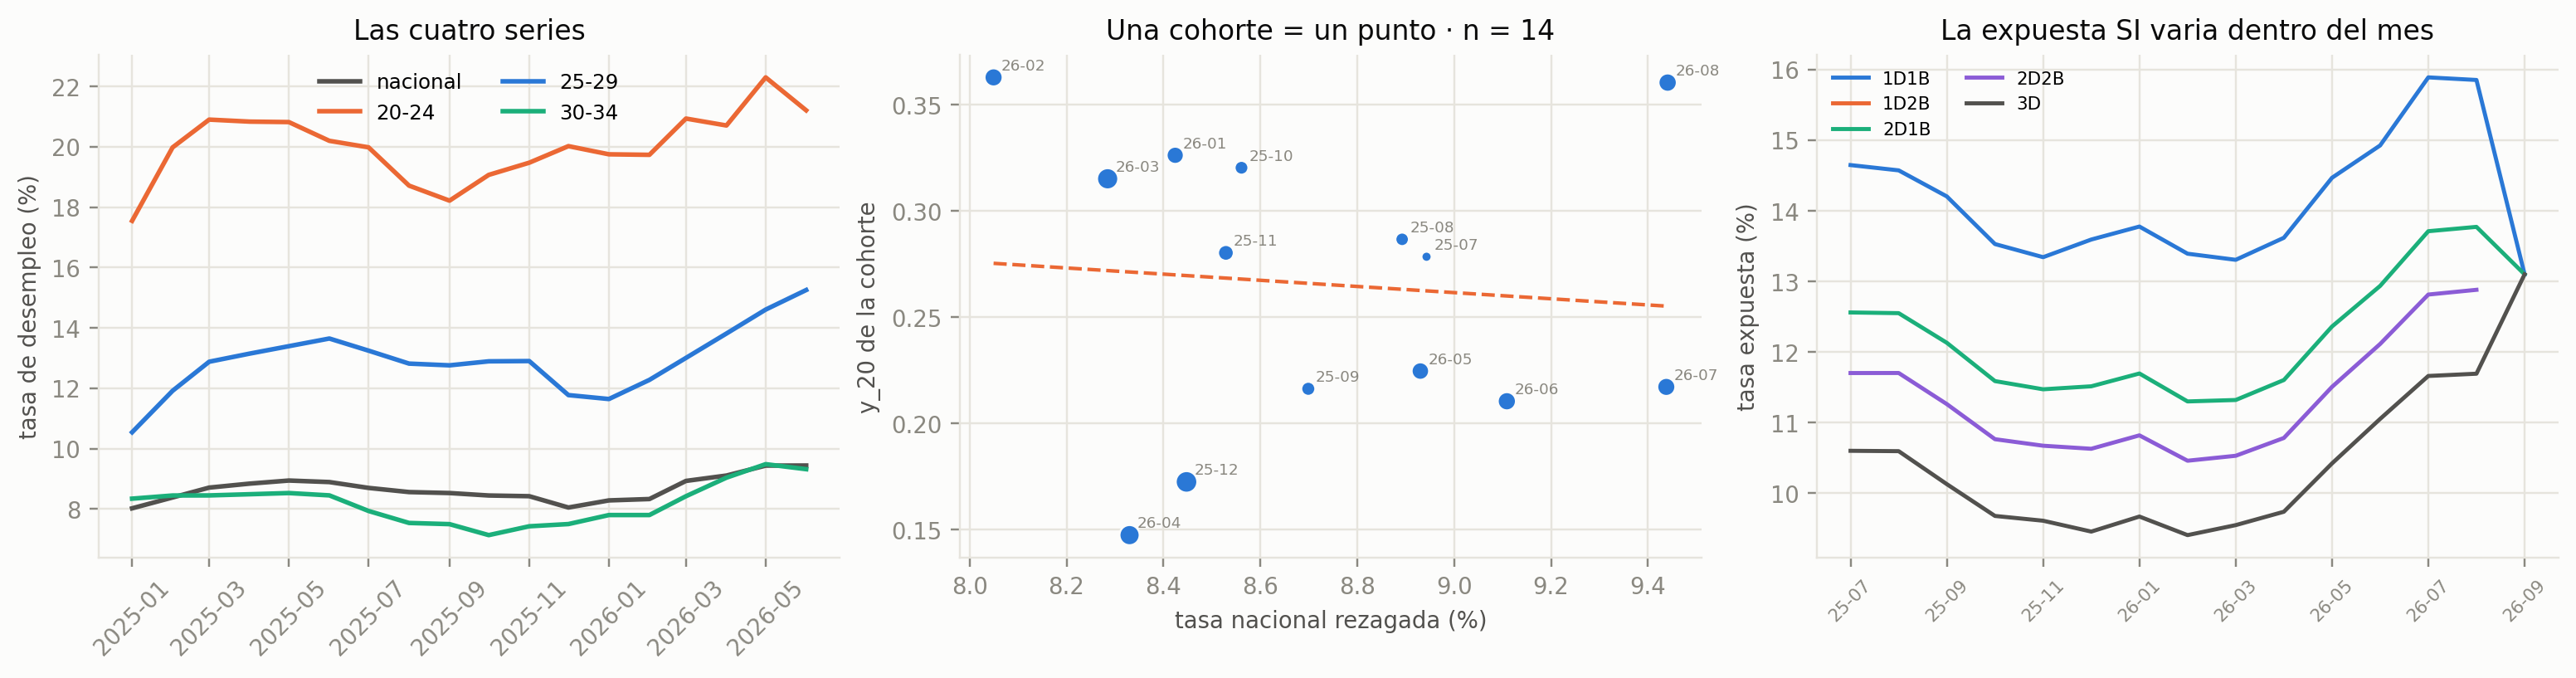

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)

ax = axes[0]
vent = macro.loc["2025-01":]
for c, col, lab in [("tasa_nacional", INK_SOFT, "nacional"),
                    ("tasa_20_24", NARANJA, "20-24"),
                    ("tasa_25_29", AZUL, "25-29"),
                    ("tasa_30_34", AQUA, "30-34")]:
    ax.plot(vent.index, vent[c], lw=1.8, color=col, label=lab)
ax.set_ylabel("tasa de desempleo (%)"); ax.set_title("Las cuatro series")
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.tick_params(axis="x", rotation=45)

ax = axes[1]
ax.scatter(prom["tasa"], prom["y"], s=prom["n"] / 6, color=AZUL,
           edgecolor=SURFACE, linewidth=0.8, zorder=3)
for coh, fila in prom.iterrows():
    ax.annotate(str(coh)[2:], (fila["tasa"], fila["y"]), fontsize=6,
                color=INK_MUTED, xytext=(3, 3), textcoords="offset points")
if len(prom) > 2:
    b = np.polyfit(prom["tasa"], prom["y"], 1)
    xs = np.linspace(prom["tasa"].min(), prom["tasa"].max(), 10)
    ax.plot(xs, np.polyval(b, xs), color=NARANJA, lw=1.4, ls="--")
ax.set_xlabel("tasa nacional rezagada (%)"); ax.set_ylabel(f"y_{H_REPORTE} de la cohorte")
ax.set_title(f"Una cohorte = un punto · n = {len(prom)}")

ax = axes[2]
tip = (D.groupby(["cohorte_lpa", "nombre_tipologia"])["tasa_expuesta"].mean()
        .unstack())
for c, col in zip(tip.columns[:5], [AZUL, NARANJA, AQUA, VIOLETA, INK_SOFT]):
    ax.plot(range(len(tip)), tip[c], lw=1.6, color=col, label=str(c))
ax.set_xticks(range(0, len(tip), 2))
ax.set_xticklabels([str(i)[2:] for i in tip.index[::2]], rotation=45, fontsize=7)
ax.set_ylabel("tasa expuesta (%)")
ax.set_title("La expuesta SI varia dentro del mes")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.show()

In [32]:
# --- Variables de barrio ----------------------------------------------------
D["barrio"] = D["barrio"].astype(str).fillna("sin dato")


def competencia(datos, clave, ventana=30):
    '''Cuantas unidades del mismo `clave` salieron a mercado en los `ventana`
    dias ANTERIORES al LPA de esta. Solo mira el pasado, asi que se puede
    calcular sobre toda la muestra sin fuga.'''
    out = np.zeros(len(datos))
    fl = datos["fecha_LPA"].to_numpy("datetime64[ns]")
    for _, idx in datos.groupby(clave).indices.items():
        orden = idx[np.argsort(fl[idx])]
        fs = fl[orden]
        lo = np.searchsorted(fs, fs - np.timedelta64(ventana, "D"), side="left")
        hi = np.searchsorted(fs, fs, side="left")
        out[orden] = hi - lo
    return out


D["competencia_barrio_30d"] = competencia(D, "barrio")
D["competencia_edificio_30d"] = competencia(D, "grupo_edificio")
print("Competencia en los 30 dias previos al LPA:")
print(D[["competencia_barrio_30d", "competencia_edificio_30d"]]
      .describe().loc[["mean", "50%", "max"]].round(1).to_string())
print(f"\nBarrios distintos: {D['barrio'].nunique()}  ·  "
      f"con n >= 30: {(D['barrio'].value_counts() >= 30).sum()}")


class AgregadosBarrio(BaseEstimator, TransformerMixin):
    '''Promedios estructurales del barrio, ajustados SOLO con el train del fold.
    No usan el target: describen el stock, no el desenlace. El target encoding
    del barrio va aparte, con TargetEncoderSuavizado.'''

    def fit(self, X, y=None):
        g = X.groupby(X["barrio"].astype(str))
        self.pm2_ = g["precio_m2"].median()
        self.lp_ = g["log_precio"].mean()
        self.m2_ = g["m2_utiles"].median()
        self.n_ = g.size()
        self.glob_ = (float(X["precio_m2"].median()), float(X["log_precio"].mean()),
                      float(X["m2_utiles"].median()))
        return self

    def transform(self, X):
        b = X["barrio"].astype(str)
        pm2 = b.map(self.pm2_).fillna(self.glob_[0]).to_numpy(float)
        lp = b.map(self.lp_).fillna(self.glob_[1]).to_numpy(float)
        m2 = b.map(self.m2_).fillna(self.glob_[2]).to_numpy(float)
        n = b.map(self.n_).fillna(0).to_numpy(float)
        rel = X["log_precio"].to_numpy(float) - lp        # caro o barato PARA su barrio
        return np.column_stack([pm2, m2, np.log1p(n), rel])

    def get_feature_names_out(self, input_features=None):
        return np.array(["barrio_precio_m2", "barrio_m2", "barrio_log_n",
                         "precio_rel_barrio"])


COLS_BARRIO_NUM = ["competencia_barrio_30d", "competencia_edificio_30d"]
COLS_BAGG = ["barrio", "log_precio", "precio_m2", "m2_utiles"]

Competencia en los 30 dias previos al LPA:
      competencia_barrio_30d  competencia_edificio_30d
mean                  13.100                    10.100
50%                    6.000                     2.000
max                  173.000                   173.000

Barrios distintos: 178  ·  con n >= 30: 30


In [33]:
# --- Las especificaciones anidadas -----------------------------------------
def diseno_ext(num_extra=(), hi_extra=(), con_barrio_agg=False):
    num, cat, hi = columnas("lpa")
    pasos = [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), list(num) + list(num_extra)),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", _ohe())]), cat),
        ("te", TargetEncoderSuavizado(list(hi) + list(hi_extra), m=M_SHRINK,
                                      semilla=SEMILLA), list(hi) + list(hi_extra)),
    ]
    if con_barrio_agg:
        # El StandardScaler NO es cosmetico. AgregadosBarrio devuelve
        # barrio_precio_m2 (~10.000) junto a precio_rel_barrio (~0,1); con esa
        # diferencia de escala lbfgs pasa de 23 iteraciones a 4.884, choca contra
        # max_iter y devuelve coeficientes a medio camino. Medido: es lo que hizo
        # que esta celda tardara 56 minutos en la corrida del 2026-09-01.
        pasos.append(("bagg", Pipeline([("agg", AgregadosBarrio()),
                                        ("sc", StandardScaler())]), COLS_BAGG))
    return ColumnTransformer(pasos, remainder="drop")


def hacer_modelo(**kw):
    '''Devuelve una fn(tr, te) compatible con `evaluar`, con la misma logica de
    la logistica del Paso 8 pero con el diseno extendido.'''
    def fn(tr, te):
        cif = np.zeros((len(te), len(REJILLA_H)))
        for j, h in enumerate(REJILLA_H):
            y = target_binario(tr, h)
            m = np.isfinite(y)
            if m.sum() < 100 or len(np.unique(y[m])) < 2:
                cif[:, j] = float(np.nanmean(y)) if m.sum() else 0.5
                continue
            pre = diseno_ext(**kw)
            Xtr, Xte = pre.fit_transform(tr[m], y[m]), pre.transform(te)
            clf = ajustar_logit(Xtr, y[m], etiqueta=f"spec h={h}")
            cif[:, j] = clf.predict_proba(Xte)[:, 1]
        cif = np.maximum.accumulate(cif, axis=1)
        return {"cif": cif, "dias": None,
                "riesgo": cif[:, REJILLA_H.index(H_REPORTE)]}
    return fn


ESPECIFICACIONES = [
    ("S0 · base (Paso 8)",        dict()),
    ("S1 · + barrio",             dict(num_extra=COLS_BARRIO_NUM, hi_extra=["barrio"],
                                       con_barrio_agg=True)),
    ("S2 · + macro nacional",     dict(num_extra=COLS_BARRIO_NUM + COLS_MACRO_NAC,
                                       hi_extra=["barrio"], con_barrio_agg=True)),
    ("S3 · + macro expuesta",     dict(num_extra=COLS_BARRIO_NUM + COLS_MACRO_EXP,
                                       hi_extra=["barrio"], con_barrio_agg=True)),
    ("S4 · + ambas macro",        dict(num_extra=COLS_BARRIO_NUM + COLS_MACRO,
                                       hi_extra=["barrio"], con_barrio_agg=True)),
]

t0 = time.time()
res_ext = [puntuar(evaluar(hacer_modelo(**kw), nom)) for nom, kw in ESPECIFICACIONES]
print(f"{time.time() - t0:.0f}s")

ext = pd.DataFrame(res_ext).set_index("modelo")
ext["dAUC"] = ext[f"AUC@{H_REPORTE}"] - ext.loc["S0 · base (Paso 8)", f"AUC@{H_REPORTE}"]
ext["dIBS"] = ext["IBS"] - ext.loc["S0 · base (Paso 8)", "IBS"]
display(ext[["n", f"AUC@{H_REPORTE}", "dAUC", "C_index", "IBS", "dIBS",
             "Calib_slope"]].round(4))

30s


,n,AUC@20,dAUC,C_index,IBS,dIBS,Calib_slope
modelo,,,,,,,
S0 · base (Paso 8),2279,0.706,0.000,0.667,0.204,0.000,0.493
S1 · + barrio,2279,0.718,0.012,0.677,0.201,-0.004,0.566
S2 · + macro nacional,2279,0.711,0.005,0.671,0.197,-0.007,0.540
S3 · + macro expuesta,2279,0.724,0.017,0.681,0.197,-0.007,0.563
S4 · + ambas macro,2279,0.699,-0.007,0.662,0.205,0.001,0.450


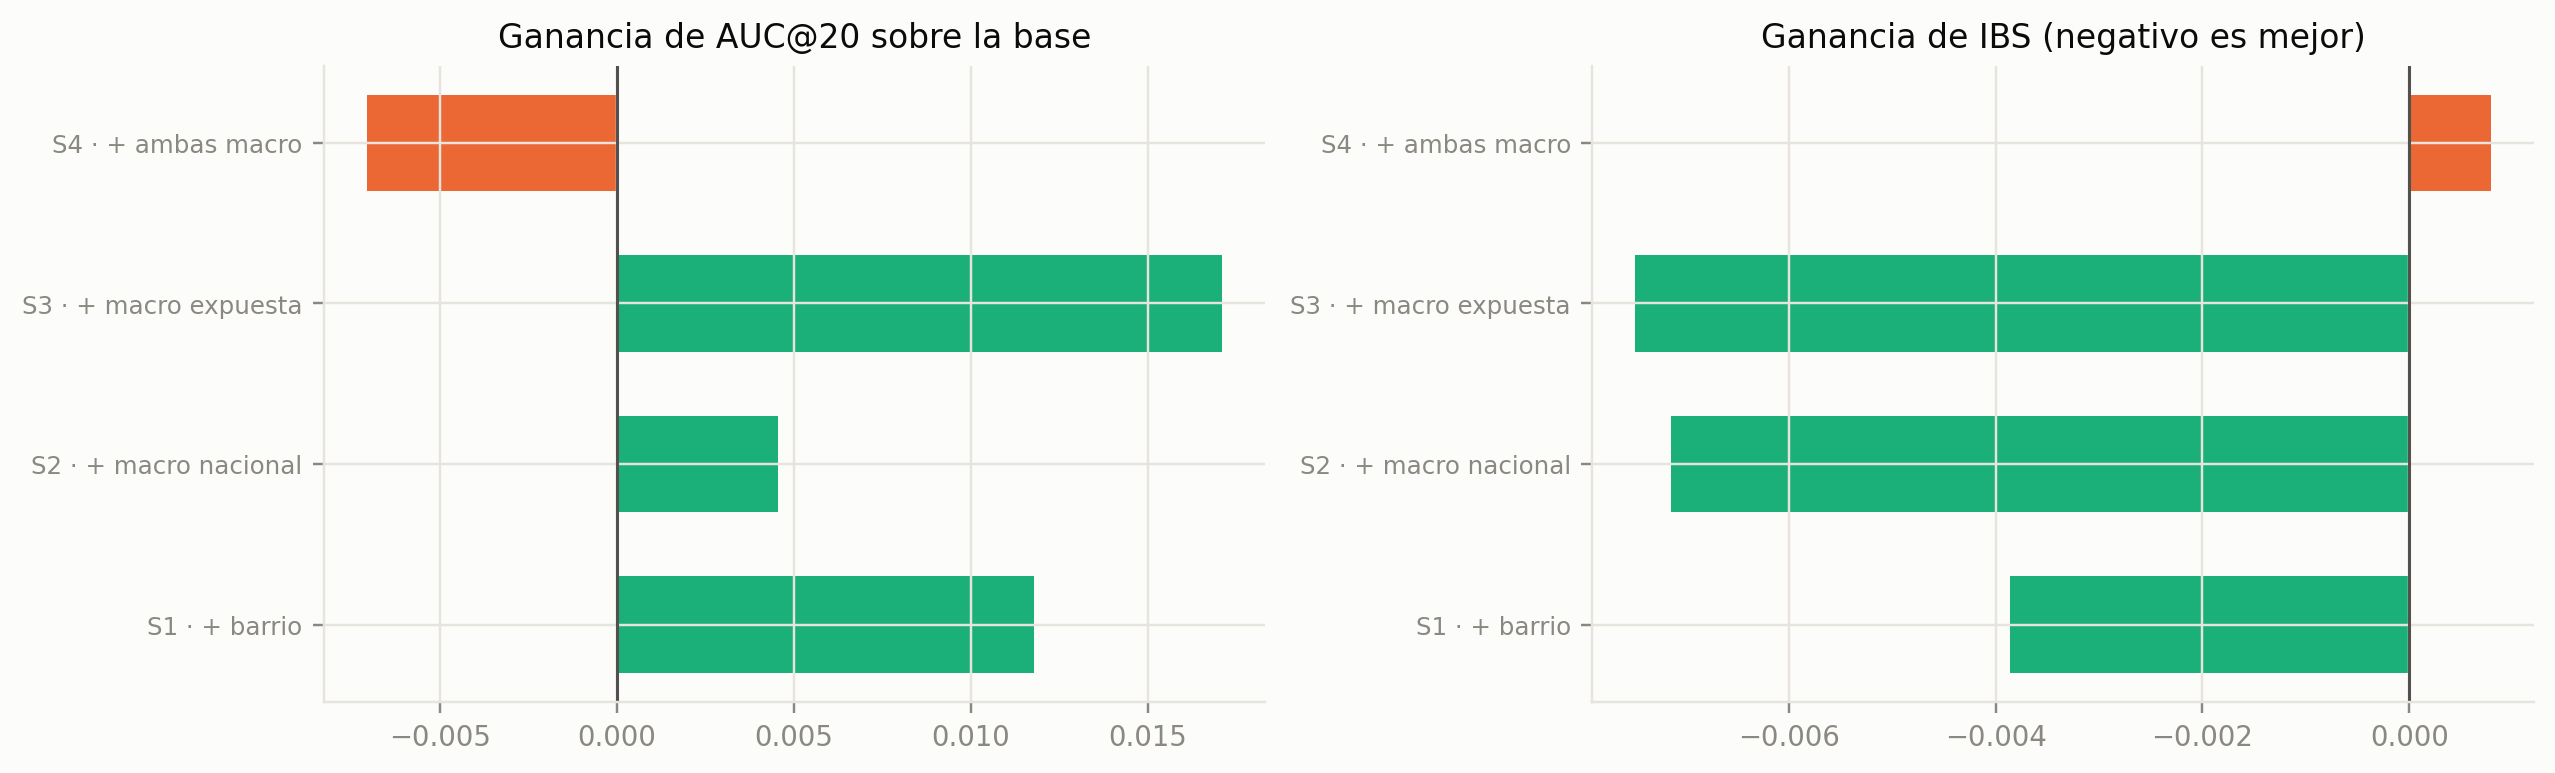

Aporte del barrio sobre la base            : +0.0118 de AUC
Aporte de la macro nacional sobre el barrio: -0.0072
Aporte de la macro expuesta sobre el barrio: +0.0053

La expuesta por edad aporta mas que la nacional. Eso es consistente con
que la senal este en la composicion (que tipologia sufre que segmento) y
no en el nivel agregado — que es justamente lo que un efecto fijo de mes
SI absorberia y esta variable no.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), constrained_layout=True)
for ax, col, tit, mejor_alto in [
        (axes[0], "dAUC", f"Ganancia de AUC@{H_REPORTE} sobre la base", True),
        (axes[1], "dIBS", "Ganancia de IBS (negativo es mejor)", False)]:
    v = ext[col].drop("S0 · base (Paso 8)")
    col_barra = [AQUA if ((x > 0) == mejor_alto) else NARANJA for x in v]
    ax.barh(range(len(v)), v, color=col_barra, height=0.6)
    ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index, fontsize=8)
    ax.axvline(0, color=INK_SOFT, lw=1)
    ax.set_title(tit)
plt.show()

g_barrio = ext.loc["S1 · + barrio", "dAUC"]
g_nac = ext.loc["S2 · + macro nacional", "dAUC"] - g_barrio
g_exp = ext.loc["S3 · + macro expuesta", "dAUC"] - g_barrio

print(f"Aporte del barrio sobre la base            : {g_barrio:+.4f} de AUC")
print(f"Aporte de la macro nacional sobre el barrio: {g_nac:+.4f}")
print(f"Aporte de la macro expuesta sobre el barrio: {g_exp:+.4f}")
print()
if abs(g_nac) < 0.005 and abs(g_exp) < 0.005:
    print("Ninguna de las dos macro mueve la aguja. Con 14 meses eso es lo esperable,")
    print("y la lectura correcta NO es 'el desempleo no afecta al arriendo': es que")
    print("con esta ventana no se puede detectar, y que mes_sin/mes_cos ya capturan")
    print("lo que hay de comun a todas las unidades de un mes.")
elif g_exp > g_nac + 0.005:
    print("La expuesta por edad aporta mas que la nacional. Eso es consistente con")
    print("que la senal este en la composicion (que tipologia sufre que segmento) y")
    print("no en el nivel agregado — que es justamente lo que un efecto fijo de mes")
    print("SI absorberia y esta variable no.")
else:
    print("La nacional aporta tanto o mas que la expuesta: la senal, si existe, es de")
    print("nivel agregado y por lo tanto indistinguible de cualquier otra cosa que se")
    print("mueva mes a mes. No atribuirla al desempleo sin mas evidencia.")

### Lectura del Paso 15

**Sobre los efectos fijos de mes.** La tabla de colinealidad es la respuesta directa: `R² = 1,000`
contra dummies de mes para `tasa_nacional` significa absorción total y coeficiente no
identificado. Para `tasa_expuesta` el R² contra dummies de mes es menor que 1 —varía dentro del
mes— pero contra `mes × tipología` vuelve a 1. O sea: **cada variable macro se puede absorber
con efectos fijos suficientemente finos, y el nivel al que deja de absorberse es exactamente el
nivel al que la variable varía.** Esa es toda la mecánica.

Lo que no se puede hacer es concluir "el desempleo no importa" desde acá. Con 14 cohortes, el
intervalo de confianza de la correlación mensual cubre casi todo el rango posible. La ventana de
observación es el límite, no los datos macro.

**Para producción hay una consecuencia práctica.** Si en algún momento la macro sí entra al
modelo, hay que respetar el rezago de publicación: el score de una unidad que se publica hoy
solo puede usar la tasa de hace dos meses. Un backtest que use la tasa contemporánea se ve
mejor de lo que va a ser.

**Sobre el barrio.** Este bloque sí es una apuesta predictiva razonable y con `n` real. Si
`S1` gana poco sobre `S0`, la explicación más probable es que `comuna` más el target encoding
de `grupo_edificio` ya capturan casi toda la ubicación, y el barrio queda en medio sin espacio
propio. Si gana, lo más interesante de mirar es cuál de las cuatro componentes lo hace: la
**competencia a 30 días** es la única variable de oferta del proyecto, y si es ella la que
aporta, abre una línea entera —cuánto stock hay compitiendo— que hoy no está en ninguna parte
del modelo.

In [35]:
# Que componente del bloque de barrio hace el trabajo. Se corre una vez cada
# una, para no leer un efecto conjunto y atribuirselo a la que suena mejor.
COMPONENTES = [
    ("solo target encoding de barrio", dict(hi_extra=["barrio"])),
    ("solo promedios del barrio",      dict(con_barrio_agg=True)),
    ("solo competencia 30d",           dict(num_extra=COLS_BARRIO_NUM)),
]
t0 = time.time()
res_comp = [puntuar(evaluar(hacer_modelo(**kw), nom)) for nom, kw in COMPONENTES]
comp = pd.DataFrame(res_comp).set_index("modelo")
base_a = ext.loc["S0 · base (Paso 8)", f"AUC@{H_REPORTE}"]
comp["dAUC"] = comp[f"AUC@{H_REPORTE}"] - base_a
display(comp[[f"AUC@{H_REPORTE}", "dAUC", "C_index", "IBS"]].round(4))
print(f"{time.time() - t0:.0f}s")

print("\nSi 'solo competencia 30d' es la que aporta, el hallazgo no es sobre el")
print("barrio: es que la CANTIDAD DE STOCK COMPITIENDO predice la velocidad, y esa")
print("es una variable que el negocio controla al decidir cuando publicar.")

,AUC@20,dAUC,C_index,IBS
modelo,,,,
solo target encoding de barrio,0.707,0.001,0.667,0.204
solo promedios del barrio,0.706,-0.001,0.668,0.205
solo competencia 30d,0.715,0.008,0.674,0.201


15s

Si 'solo competencia 30d' es la que aporta, el hallazgo no es sobre el
barrio: es que la CANTIDAD DE STOCK COMPITIENDO predice la velocidad, y esa
es una variable que el negocio controla al decidir cuando publicar.


## Paso 16 · De dónde vienen los puntos de AUC

El modelo le gana al baseline por un margen grande, pero eso no dice **qué** aprendió. Hay una
hipótesis concreta que hay que descartar o confirmar antes de llamarlo herramienta de pricing:

> *que todo el aporte venga del edificio, y que el precio no agregue nada.*

Si fuera así el producto no es "pusiste mal el precio" sino **"este edificio es lento"** — sigue
sirviendo para priorizar atención, pero es otra cosa, y hay que decirlo antes de venderlo.

### Por qué no basta mirar coeficientes ni p-valores

Las features del modelo están correlacionadas entre sí: el análisis midió `dormitorios ↔
m2_utiles` en 0,83, `precio ↔ m2` en 0,76 y `ggcc ↔ precio` en 0,63. Con ese grado de
solapamiento la varianza se reparte y **ningún coeficiente sale significativo por separado
aunque el bloque completo prediga**. Un p-valor sobre un coeficiente responde "¿este parámetro
es distinto de cero manteniendo los otros 37 fijos?", que no es la pregunta. La pregunta es si
la información mejora la predicción fuera de muestra, y eso se contesta sacándola y volviendo a
medir.

### Dos direcciones, porque miden cosas distintas

| | Qué se hace | Qué mide | Cuidado |
|---|---|---|---|
| **Quitando** (leave-one-out) | modelo completo **menos** el bloque | aporte **único**, neto de lo que otros bloques ya capturan | subestima cuando hay redundancia |
| **Solo** (leave-one-in) | **únicamente** ese bloque | poder **total**, incluida la información compartida | sobreestima: le atribuye lo compartido |

Un bloque con `Δ ≈ 0` al quitarlo pero AUC alto por sí solo **no es inútil: es redundante**. Eso
importa acá porque la ubicación aparece en tres bloques a la vez (sector, comuna, edificio) y
cada uno tapa al otro cuando se saca de a uno.

### Cómo se lee el resultado para el gap de precio

- **Quitarlo no mueve el AUC y solo tampoco predice** → el precio no aporta nada predictivo. El
  entregable honesto es un ranking de edificios, no una herramienta de pricing.
- **Quitarlo no mueve el AUC pero solo sí predice** → el precio predice, pero lo que predice ya
  está en la ubicación (las comunas caras son las rápidas). No es accionable: bajar el precio de
  una unidad no la muda de comuna.
- **Quitarlo cuesta AUC** → aporta información propia. Aunque sean 0,02, es **la única variable
  que el negocio controla**, y eso vale más que su tamaño en la tabla.

Para que corra rápido esta sección evalúa **solo el horizonte de reporte** (un ajuste por fold
en vez de seis). El orden entre bloques no cambia por eso; lo que no se recalcula es el IBS.

In [36]:
# --- Maquinaria de ablacion -------------------------------------------------
NUM_BASE, CAT_BASE, HI_BASE = columnas("lpa")

BLOQUES = {
    "gap contra el ML":      dict(num=["gap_centrado", "gap_disponible"]),
    "precio (nivel)":        dict(num=["log_precio", "precio_m2"]),
    "precio + gap":          dict(num=["log_precio", "precio_m2",
                                       "gap_centrado", "gap_disponible"]),
    "edificio":              dict(hi=["grupo_edificio"]),
    "comuna y sector":       dict(cat=["sector_provincia", "comuna_g"]),
    "TODA la ubicacion":     dict(cat=["sector_provincia", "comuna_g"],
                                  hi=["grupo_edificio"]),
    "atributos fisicos":     dict(num=["m2_utiles", "m2_por_dormitorio", "dormitorios",
                                       "banos", "estudio", "piso", "piso_es_cero",
                                       "acepta_mascotas"]),
    "ggcc (+ su faltante)":  dict(num=["ggcc", "ggcc_falta"]),
    "habilitacion":          dict(num=["dias_habilitacion"]),
    "estacionalidad":        dict(num=["mes_sin", "mes_cos"]),
    "tipologia y owner":     dict(cat=["nombre_tipologia", "owner_type"]),
}


def diseno_sub(num_cols, cat_cols, hi_cols):
    pasos = []
    if num_cols:
        pasos.append(("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                       ("sc", StandardScaler())]), list(num_cols)))
    if cat_cols:
        pasos.append(("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                       ("oh", _ohe())]), list(cat_cols)))
    if hi_cols:
        pasos.append(("te", TargetEncoderSuavizado(list(hi_cols), m=M_SHRINK,
                                                   semilla=SEMILLA), list(hi_cols)))
    return ColumnTransformer(pasos, remainder="drop")


def correr_sub(num_cols, cat_cols, hi_cols, etiqueta, h=None):
    '''Forward por cohorte en UN horizonte. Devuelve AUC, Brier y C-index.'''
    h = H_REPORTE if h is None else h
    y_all = target_binario(D, h)
    if not (num_cols or cat_cols or hi_cols):        # modelo solo con intercepto
        p_all, y_ok, idx = [], [], []
        for tr, te in FOLDS:
            mtr, mte = np.isfinite(y_all[tr]), np.isfinite(y_all[te])
            if mtr.sum() < 100 or mte.sum() < 20:
                continue
            p_all.append(np.full(mte.sum(), float(np.mean(y_all[tr][mtr]))))
            y_ok.append(y_all[te][mte]); idx.append(te[mte])
    else:
        p_all, y_ok, idx = [], [], []
        for tr, te in FOLDS:
            mtr, mte = np.isfinite(y_all[tr]), np.isfinite(y_all[te])
            if mtr.sum() < 100 or mte.sum() < 20 or len(np.unique(y_all[tr][mtr])) < 2:
                continue
            pre = diseno_sub(num_cols, cat_cols, hi_cols)
            Xtr = pre.fit_transform(D.iloc[tr[mtr]], y_all[tr][mtr])
            clf = ajustar_logit(Xtr, y_all[tr][mtr], etiqueta=f"ablacion {etiqueta}")
            p_all.append(clf.predict_proba(pre.transform(D.iloc[te[mte]]))[:, 1])
            y_ok.append(y_all[te][mte]); idx.append(te[mte])

    yy, pp, ii = np.concatenate(y_ok), np.concatenate(p_all), np.concatenate(idx)
    dd = D.iloc[ii]
    return {
        "bloque": etiqueta, "n": len(yy),
        "AUC": roc_auc_score(yy, pp) if len(np.unique(yy)) == 2 else np.nan,
        "Brier": brier_score_loss(yy, pp),
        "C_index": c_index(dd["dias_obs"].to_numpy(float),
                           dd["evento_arriendo"].to_numpy(int), pp),
        "n_features": len(num_cols) + len(cat_cols) + len(hi_cols),
    }


def quitar(base, fuera):
    return [c for c in base if c not in set(fuera)]


print(f"Ablacion en h = {H_REPORTE} dias · {len(FOLDS)} folds forward · "
      f"{len(BLOQUES)} bloques x 2 direcciones")

Ablacion en h = 20 dias · 7 folds forward · 11 bloques x 2 direcciones


In [37]:
t0 = time.time()

ref = correr_sub(NUM_BASE, CAT_BASE, HI_BASE, "MODELO COMPLETO")
solo_int = correr_sub([], [], [], "nada (tasa base)")

filas = []
for nom, b in BLOQUES.items():
    n_b, c_b, h_b = b.get("num", []), b.get("cat", []), b.get("hi", [])
    sin = correr_sub(quitar(NUM_BASE, n_b), quitar(CAT_BASE, c_b),
                     quitar(HI_BASE, h_b), nom)
    solo = correr_sub(n_b, c_b, h_b, nom)
    filas.append({
        "bloque": nom,
        "k": len(n_b) + len(c_b) + len(h_b),
        "AUC_sin": sin["AUC"],
        "dAUC_al_quitar": sin["AUC"] - ref["AUC"],
        "dC_al_quitar": sin["C_index"] - ref["C_index"],
        "AUC_solo": solo["AUC"],
        "C_solo": solo["C_index"],
    })

abl = (pd.DataFrame(filas).set_index("bloque")
         .sort_values("dAUC_al_quitar"))
print(f"{time.time() - t0:.0f}s\n")
print(f"MODELO COMPLETO       AUC {ref['AUC']:.4f} · C-index {ref['C_index']:.4f}")
print(f"baseline del Paso 7   AUC "
      f"{tabla.loc['baseline segmento', f'AUC@{H_REPORTE}']:.4f}")
print(f"solo la tasa base     AUC {solo_int['AUC']:.4f}  (piso: no distingue nada)\n")
display(abl.round(4))
print("dAUC_al_quitar negativo = el bloque estaba aportando. Cuanto mas negativo,")
print("mas insustituible. AUC_solo alto con dAUC ~ 0 = redundante, no inutil.")

12s

MODELO COMPLETO       AUC 0.7062 · C-index 0.6668
baseline del Paso 7   AUC 0.5858
solo la tasa base     AUC 0.4493  (piso: no distingue nada)



,k,AUC_sin,dAUC_al_quitar,dC_al_quitar,AUC_solo,C_solo
bloque,,,,,,
precio + gap,4,0.645,-0.061,-0.065,0.700,0.663
gap contra el ML,2,0.655,-0.051,-0.053,0.670,0.642
tipologia y owner,2,0.701,-0.005,-0.005,0.490,0.501
ggcc (+ su faltante),2,0.701,-0.005,-0.004,0.580,0.554
habilitacion,1,0.701,-0.005,-0.002,0.563,0.540
precio (nivel),2,0.703,-0.004,-0.002,0.520,0.511
estacionalidad,2,0.703,-0.003,-0.004,0.503,0.505
edificio,1,0.704,-0.003,-0.001,0.585,0.551
atributos fisicos,8,0.704,-0.002,-0.000,0.530,0.530


dAUC_al_quitar negativo = el bloque estaba aportando. Cuanto mas negativo,
mas insustituible. AUC_solo alto con dAUC ~ 0 = redundante, no inutil.


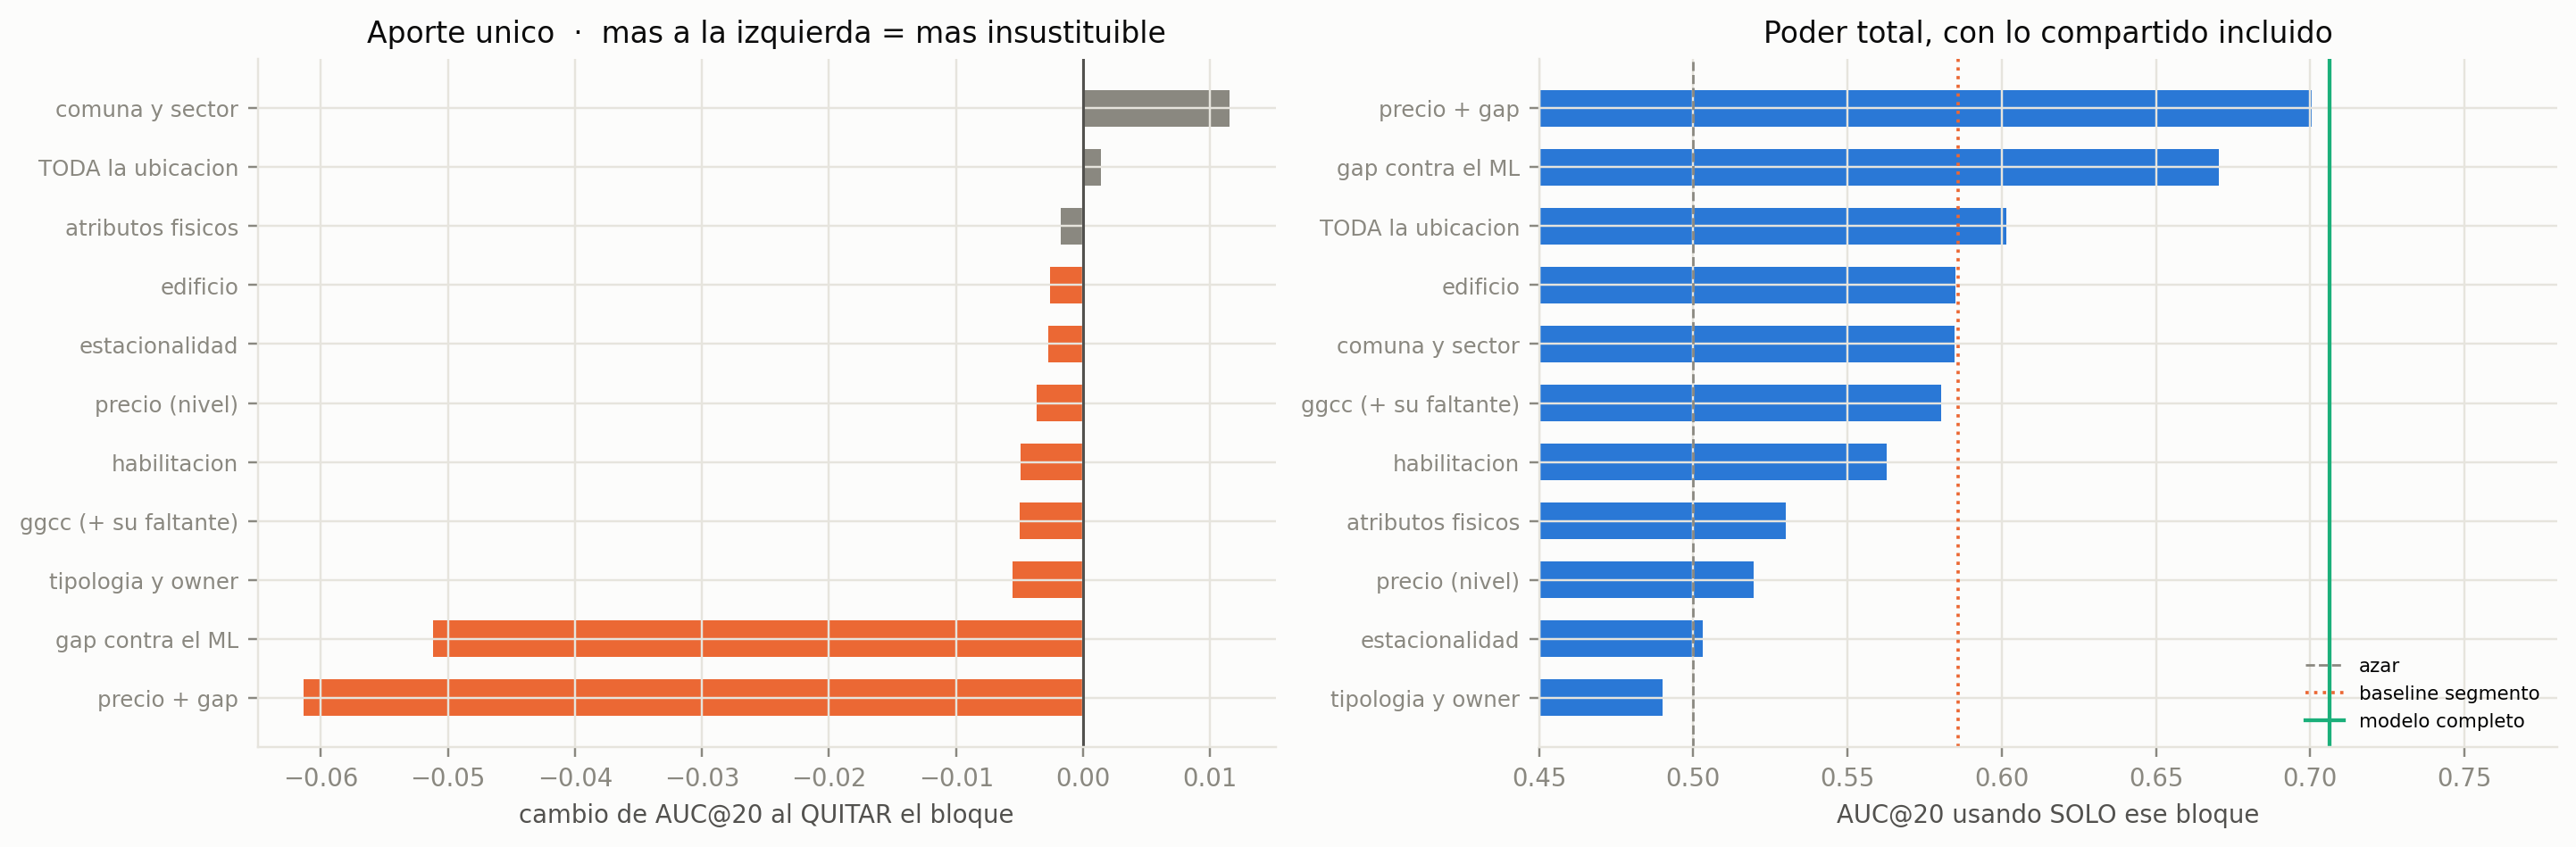

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
o = abl.sort_values("dAUC_al_quitar")

ax = axes[0]
ax.barh(range(len(o)), o["dAUC_al_quitar"],
        color=[NARANJA if v < -0.002 else INK_MUTED for v in o["dAUC_al_quitar"]],
        height=0.62)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index, fontsize=8)
ax.axvline(0, color=INK_SOFT, lw=1)
ax.set_xlabel(f"cambio de AUC@{H_REPORTE} al QUITAR el bloque")
ax.set_title("Aporte unico  ·  mas a la izquierda = mas insustituible")

ax = axes[1]
o2 = abl.sort_values("AUC_solo")
ax.barh(range(len(o2)), o2["AUC_solo"], color=AZUL, height=0.62)
ax.axvline(0.5, color=INK_MUTED, lw=0.9, ls="--", label="azar")
ax.axvline(tabla.loc["baseline segmento", f"AUC@{H_REPORTE}"], color=NARANJA,
           lw=1.2, ls=":", label="baseline segmento")
ax.axvline(ref["AUC"], color=AQUA, lw=1.4, label="modelo completo")
ax.set_yticks(range(len(o2))); ax.set_yticklabels(o2.index, fontsize=8)
ax.set_xlim(0.45, max(0.78, ref["AUC"] + 0.03))
ax.set_xlabel(f"AUC@{H_REPORTE} usando SOLO ese bloque")
ax.set_title("Poder total, con lo compartido incluido")
ax.legend(frameon=False, fontsize=7, loc="lower right")
plt.show()

In [39]:
# --- El veredicto, escrito por los numeros ---------------------------------
UMBRAL = 0.005      # por debajo de esto, con ~7 folds, no se distingue de ruido

g_quit = abl.loc["gap contra el ML", "dAUC_al_quitar"]
g_solo = abl.loc["gap contra el ML", "AUC_solo"]
e_quit = abl.loc["edificio", "dAUC_al_quitar"]
u_quit = abl.loc["TODA la ubicacion", "dAUC_al_quitar"]
u_solo = abl.loc["TODA la ubicacion", "AUC_solo"]
base_auc_p7 = tabla.loc["baseline segmento", f"AUC@{H_REPORTE}"]

linea = "=" * 74
print(linea)
print("VEREDICTO")
print(linea)
print(f"Ubicacion completa : quitarla cuesta {u_quit:+.4f} · sola llega a {u_solo:.4f}")
print(f"Edificio solo      : quitarlo cuesta {e_quit:+.4f}")
print(f"Gap contra el ML   : quitarlo cuesta {g_quit:+.4f} · solo llega a {g_solo:.4f}")
print(linea)

if g_quit > -UMBRAL and g_solo < base_auc_p7:
    print("EL PRECIO NO APORTA. Ni unico ni total: sacarlo no cuesta nada y solo no")
    print("predice mejor que la tasa del segmento. Lo que hay es un modelo de")
    print("UBICACION. El entregable honesto es un ranking de edificios para")
    print("priorizar atencion, NO una herramienta de pricing, y hay que presentarlo")
    print("asi. La linea de trabajo que queda no es cambiar de modelo: es conseguir")
    print("variables de oferta y demanda que hoy no existen.")
elif g_quit > -UMBRAL and g_solo >= base_auc_p7:
    print("EL PRECIO PREDICE PERO ES REDUNDANTE. Solo llega a un AUC decente, pero")
    print("sacarlo del modelo completo no cuesta nada: lo que predice ya esta en la")
    print("ubicacion (las comunas caras son las rapidas). Como palanca NO sirve —")
    print("bajarle el precio a una unidad no la muda de comuna. Antes de descartarlo")
    print("del todo, revisar si el gap centrado quedo bien construido: es el")
    print("candidato natural a tener senal propia y este test dice que no la tiene.")
else:
    print(f"EL PRECIO APORTA INFORMACION PROPIA ({g_quit:+.4f} de AUC al quitarlo).")
    print("Puede parecer poco al lado de la ubicacion, pero es la UNICA variable de")
    print("todo el modelo que el negocio controla. La ubicacion es un hecho; el")
    print("precio es una decision. Para un producto de pricing ese bloque vale mas")
    print("que su tamano en esta tabla.")

print()
if u_quit < -0.05:
    print(f"La ubicacion es el motor: sin ella el AUC cae {u_quit:+.4f}. Eso confirma")
    print("lo que el analisis ya mostraba (y_20 de 0,02 a 0,87 entre edificios) y")
    print("obliga a una advertencia de produccion: para un edificio NUEVO, sin")
    print("historial, el target encoding cae al promedio global y el modelo pierde")
    print("justo lo que mas pesa. Hay que medir aparte su desempeño en esos casos.")
print(linea)

VEREDICTO
Ubicacion completa : quitarla cuesta +0.0014 · sola llega a 0.6014
Edificio solo      : quitarlo cuesta -0.0026
Gap contra el ML   : quitarlo cuesta -0.0512 · solo llega a 0.6705
EL PRECIO APORTA INFORMACION PROPIA (-0.0512 de AUC al quitarlo).
Puede parecer poco al lado de la ubicacion, pero es la UNICA variable de
todo el modelo que el negocio controla. La ubicacion es un hecho; el
precio es una decision. Para un producto de pricing ese bloque vale mas
que su tamano en esta tabla.



### Lo que este paso no contesta

**No es causal.** Que quitar el gap cueste AUC no prueba que bajar el precio acelere la
colocación. La correlación puede correr al revés —a la unidad que no se mueve se le baja el
precio— y el análisis midió justamente eso: el 37,3% de las unidades tuvo una bajada dentro de
la ventana, y esas se demoran 53 días de mediana contra 24. Para una afirmación causal hace
falta variación exógena: un experimento de precios, o al menos un cambio de política que haya
movido precios por razones ajenas a la unidad.

**No dice cuánto bajar.** El modelo ordena unidades; no estima una elasticidad. La curva del
Paso 14 sugiere la forma, pero está estimada sobre precios que la casa eligió mirando la
misma información que predice la velocidad.

**Y el umbral de 0,005 es una convención, no un test.** Con ~7 folds forward y test de unos
300-400 casos cada uno, diferencias de esa magnitud no se distinguen de ruido de muestreo. Si
un bloque cae justo en el borde, la respuesta correcta es "no se sabe con esta muestra", no
elegir el lado que conviene.

## Paso 17 · El techo, y un gap que no depende del ML

Dos cosas que salen directo de la literatura del proyecto.

### 17.1 · ¿Cuánto de lo que falta es irreducible?

Andersson (JSAI 2025) modela exactamente este problema —duración de vacancia de departamentos
de arriendo, ~20.000 filas, Japón— con un Weibull discreto jerárquico bayesiano, y reporta
**C-index 0,63**. Pero lo importante no es su número: es que **calcula el techo**. Toma las
duraciones que su modelo estima como si fueran la verdad, simula esperas geométricas con esos
parámetros, y pregunta con qué probabilidad quedan bien ordenadas. Le da **~0,66**.

O sea: aunque conocieras la tasa verdadera de cada unidad con precisión perfecta, el C-index no
pasaría de ~0,66, porque el desenlace **es un tiempo de espera aleatorio**. Predecir bien la
tasa y mal la realización no es una falla del modelo; es la naturaleza del objeto. Es también
la explicación del `MAE dias` de ~20 que salió en el Paso 12.

Este paso calcula nuestro propio techo, con tres métricas:

| Métrica | Cómo se obtiene el techo | Exacto o simulado |
|---|---|---|
| **Brier** | `E[p(1−p)]` — si `p` es la probabilidad verdadera, ese es el error mínimo posible | **exacto** |
| **AUC** | simular `Y ~ Bernoulli(p)` y puntuar con el propio `p` | simulado |
| **C-index** | simular duraciones del AFT ajustado y ordenar con la tasa verdadera | simulado |

**Cómo se lee, y es lo único que importa de este paso:**

- **observado ≈ techo** → el algoritmo ya extrajo toda la señal que estas features contienen.
  Cambiar de modelo, agregar datos o afinar hiperparámetros no va a mover nada. Lo único que
  puede subir el desempeño son **features nuevas**.
- **observado ≪ techo** → hay error de estimación. Más datos, mejor regularización o un modelo
  mejor especificado sí ayudarían.

Una advertencia sobre qué es este techo. Se calcula **suponiendo que el modelo está bien
especificado**: que las `p` predichas son las verdaderas. Si faltan features, las `p`
verdaderas tienen más varianza que las predichas y el techo real es **más alto**. Así que este
número no dice "no se puede mejorar nunca": dice "con esta información, esto es todo". Es una
cota sobre el modelo actual, no sobre el problema.

### 17.2 · Un gap sin ML

Andersson define la variable de precio como `rrel = (r + w·keymoney) / r̂`: el desembolso
**total** del arrendatario contra una predicción de referencia. Dos diferencias con lo que
tenemos, y las dos importan:

**El costo total, no el arriendo.** El arrendatario compara arriendo más gastos comunes. En la
muestra `ggcc` tiene mediana 65.000 sobre un arriendo mediano de 380.000: es el 17% del
desembolso, y varía bastante entre edificios. Un gap calculado solo sobre el arriendo le
atribuye a la unidad un precio relativo que el arrendatario no ve.

**Y una referencia que no dependa del ML.** El `gap_centrado` actual necesita
`precio_ml_expost`, del que solo el **3,9% es ex-ante**. Para un modelo productivo eso es un
bloqueador: al puntuar una unidad el día que se publica necesitas la recomendación de ese
momento, no una reconstruida después. Un gap definido como *"caro o barato respecto de su
propio segmento"* no necesita ninguna recomendación y tiene cobertura completa.

Se construyen dos alternativas y se comparan las tres contra el mismo esquema forward.

In [40]:
# --- Tres definiciones del gap ---------------------------------------------
def centrar_jerarquico(datos, valores, niveles, n_min=8, tope=None):
    '''Centra `valores` en la celda mas fina que tenga al menos n_min datos.
    Misma logica del Paso 1, factorizada para reusarla.'''
    v = valores if tope is None else valores.where(valores.abs() <= tope)
    centro = pd.Series(np.nan, index=datos.index)
    for keys in niveles:
        g = v.groupby([datos[k] for k in keys])
        media, tam = g.transform("mean"), g.transform("count")
        aplica = centro.isna() & (tam >= n_min) & media.notna()
        centro[aplica] = media[aplica]
    return (valores - centro.fillna(v.mean()))


NIVELES = [
    ["comuna", "nombre_tipologia", "cohorte_lpa"],
    ["sector_provincia", "_dorm_g", "trimestre_lpa"],
    ["sector_provincia", "_dorm_g"],
    ["sector_provincia"],
]
D["_dorm_g"] = D["dormitorios"].clip(0, 3).fillna(-1).astype(int)

# ggcc imputado por edificio -> segmento -> global, para no perder el 17,3%.
gg = D["ggcc"].copy()
for keys in (["grupo_edificio"], ["comuna", "nombre_tipologia"], ["sector_provincia"]):
    med = gg.groupby([D[k] for k in keys]).transform("median")
    gg = gg.fillna(med)
gg = gg.fillna(gg.median())
D["ggcc_imp"] = gg
D["costo_total"] = D["precio_oferta"] + gg

# (a) precio solo, centrado en su segmento — sin ML
D["gap_precio_centrado"] = centrar_jerarquico(
    D, np.log(D["precio_oferta"].clip(lower=1)), NIVELES).fillna(0.0)
# (b) costo total (arriendo + ggcc), centrado — sin ML, y es lo que el arrendatario ve
D["gap_costo_centrado"] = centrar_jerarquico(
    D, np.log(D["costo_total"].clip(lower=1)), NIVELES).fillna(0.0)

print("Peso de ggcc en el desembolso:")
print(f"  ggcc / (arriendo + ggcc): p50 {(gg / D['costo_total']).median():.1%} · "
      f"p90 {(gg / D['costo_total']).quantile(0.9):.1%}")
print(f"  imputados: {int(D['ggcc'].isna().sum()):,} de {len(D):,}\n")

cmp_gap = pd.DataFrame({
    "gap_centrado (ML)":       D["gap_centrado"],
    "gap_precio_centrado":     D["gap_precio_centrado"],
    "gap_costo_centrado":      D["gap_costo_centrado"],
})
print("Dispersion y correlacion entre las tres definiciones:")
print(cmp_gap.std().round(4).to_string())
display(cmp_gap.corr().round(3))
print(f"Cobertura del gap con ML: {D['gap_disponible'].mean():.1%} · "
      f"de los dos sin ML: 100,0%")

Peso de ggcc en el desembolso:
  ggcc / (arriendo + ggcc): p50 14.7% · p90 19.4%
  imputados: 679 de 3,901

Dispersion y correlacion entre las tres definiciones:
gap_centrado (ML)     0.091
gap_precio_centrado   0.152
gap_costo_centrado    0.150


,gap_centrado (ML),gap_precio_centrado,gap_costo_centrado
gap_centrado (ML),1.000,0.616,0.547
gap_precio_centrado,0.616,1.000,0.964
gap_costo_centrado,0.547,0.964,1.000


Cobertura del gap con ML: 82.7% · de los dos sin ML: 100,0%


In [41]:
# --- Cual de los tres gaps predice mejor -----------------------------------
# Se usa la maquinaria rapida del Paso 16 (un horizonte, un ajuste por fold).
VARIANTES = {
    "sin ningun gap":        [],
    "gap con ML (actual)":   ["gap_centrado", "gap_disponible"],
    "gap de precio (sin ML)": ["gap_precio_centrado"],
    "gap de costo total":    ["gap_costo_centrado"],
    "costo total + ML":      ["gap_costo_centrado", "gap_centrado", "gap_disponible"],
}
NUM_SIN_GAP = [c for c in NUM_BASE if c not in ("gap_centrado", "gap_disponible")]

t0 = time.time()
filas = []
for nom, extra in VARIANTES.items():
    r = correr_sub(NUM_SIN_GAP + extra, CAT_BASE, HI_BASE, nom)
    filas.append(r)
gaps = pd.DataFrame(filas).set_index("bloque")
gaps["dAUC"] = gaps["AUC"] - gaps.loc["sin ningun gap", "AUC"]
gaps["dC"] = gaps["C_index"] - gaps.loc["sin ningun gap", "C_index"]
print(f"{time.time() - t0:.0f}s")
display(gaps[["AUC", "dAUC", "C_index", "dC", "Brier"]].round(4))

mejor_gap = gaps.drop("sin ningun gap")["AUC"].idxmax()
print(f"Mejor definicion: {mejor_gap}")
if "sin ML" in mejor_gap or "costo total" == mejor_gap.strip():
    print("Y no necesita el ML. Eso elimina el bloqueador de produccion: el 96,1%")
    print("de las recomendaciones del ML son ex-post y no existirian al momento de")
    print("puntuar una unidad recien publicada.")

4s


,AUC,dAUC,C_index,dC,Brier
bloque,,,,,
sin ningun gap,0.655,0.000,0.613,0.000,0.187
gap con ML (actual),0.706,0.051,0.667,0.053,0.189
gap de precio (sin ML),0.657,0.002,0.615,0.001,0.188
gap de costo total,0.656,0.001,0.614,0.001,0.188
costo total + ML,0.706,0.051,0.667,0.053,0.190


Mejor definicion: gap con ML (actual)


In [42]:
# --- El techo, como en Andersson (JSAI 2025) -------------------------------
R_SIM = 40
rng = np.random.default_rng(SEMILLA)
j_rep = REJILLA_H.index(H_REPORTE)

# 1) Brier: si p es la probabilidad verdadera, el error minimo es E[p(1-p)].
#    Es exacto, no hay nada que simular.
dd_B = pred_B["datos"].iloc[pred_B["idx"]]
p_B = np.clip(pred_B["cif"][:, j_rep], 1e-6, 1 - 1e-6)
y_B = target_binario(dd_B, H_REPORTE)
obs_m = np.isfinite(y_B)
# Sobre las MISMAS filas que el Brier observado. En la corrida del 2026-09-01
# esto se calculaba sobre todas las filas y el observado solo sobre las que ya
# tienen desenlace a h dias: daba un "reducible" negativo, que es imposible.
techo_brier = float(np.mean(p_B[obs_m] * (1 - p_B[obs_m])))
obs_brier = float(brier_score_loss(y_B[obs_m], p_B[obs_m]))

# 2) AUC: simular Y ~ Bernoulli(p) y puntuar con el propio p.
aucs = []
for _ in range(R_SIM):
    ysim = rng.binomial(1, p_B)
    if len(np.unique(ysim)) == 2:
        aucs.append(roc_auc_score(ysim, p_B))
techo_auc = float(np.mean(aucs))
obs_auc = float(roc_auc_score(y_B[obs_m], p_B[obs_m]))

# 3) C-index: simular duraciones del AFT ajustado y ordenar con la tasa VERDADERA.
#    El seguimiento de cada unidad es lo que va de su LPA al corte de los datos.
FECHA_CORTE = (D["fecha_LPA"] + pd.to_timedelta(D["dias_obs"], unit="D")).max()
segu = (FECHA_CORTE - D["fecha_LPA"]).dt.days.clip(lower=1).to_numpy(float)
mu = np.log(np.clip(dias_aft, 1e-6, None))
sigma = aft_full["sigma"]

def techo_c(sig, reps=R_SIM):
    out = []
    for _ in range(reps):
        T = np.exp(mu + sig * rng.standard_normal(len(mu)))
        out.append(c_index(np.minimum(T, segu), (T <= segu).astype(int), -mu))
    return float(np.mean(out)), float(np.std(out))

techo_cidx, sd_cidx = techo_c(sigma)
obs_cidx = float(tabla.loc["B · AFT log-normal", "C_index"])

print(f"sigma del AFT: {sigma:.3f}  ·  corte de datos: {FECHA_CORTE:%Y-%m-%d}  ·  "
      f"{R_SIM} simulaciones\n")
tech = pd.DataFrame([
    {"metrica": f"AUC@{H_REPORTE}", "observado": obs_auc, "techo": techo_auc,
     "azar": 0.5},
    {"metrica": "C-index",          "observado": obs_cidx, "techo": techo_cidx,
     "azar": 0.5},
    {"metrica": f"Brier@{H_REPORTE}", "observado": obs_brier, "techo": techo_brier,
     "azar": np.nan},
]).set_index("metrica")
tech["pct_del_techo"] = np.where(
    tech.index.str.startswith("Brier"),
    tech["techo"] / tech["observado"],
    (tech["observado"] - tech["azar"]) / (tech["techo"] - tech["azar"]))
display(tech.round(4))
print("pct_del_techo: cuanto del margen alcanzable sobre el azar ya esta capturado")
print("(para Brier, cuanto del error observado es irreducible).")

sigma del AFT: 1.337  ·  corte de datos: 2026-09-02  ·  40 simulaciones



,observado,techo,azar,pct_del_techo
metrica,,,,
AUC@20,0.726,0.763,0.500,0.860
C-index,0.685,0.713,0.500,0.872
Brier@20,0.174,0.175,NaN,1.010


pct_del_techo: cuanto del margen alcanzable sobre el azar ya esta capturado
(para Brier, cuanto del error observado es irreducible).


,sigma,techo_C_index
x_sigma_real,,
0.500,0.668,0.812
0.750,1.003,0.755
1.000,1.337,0.713
1.250,1.671,0.681


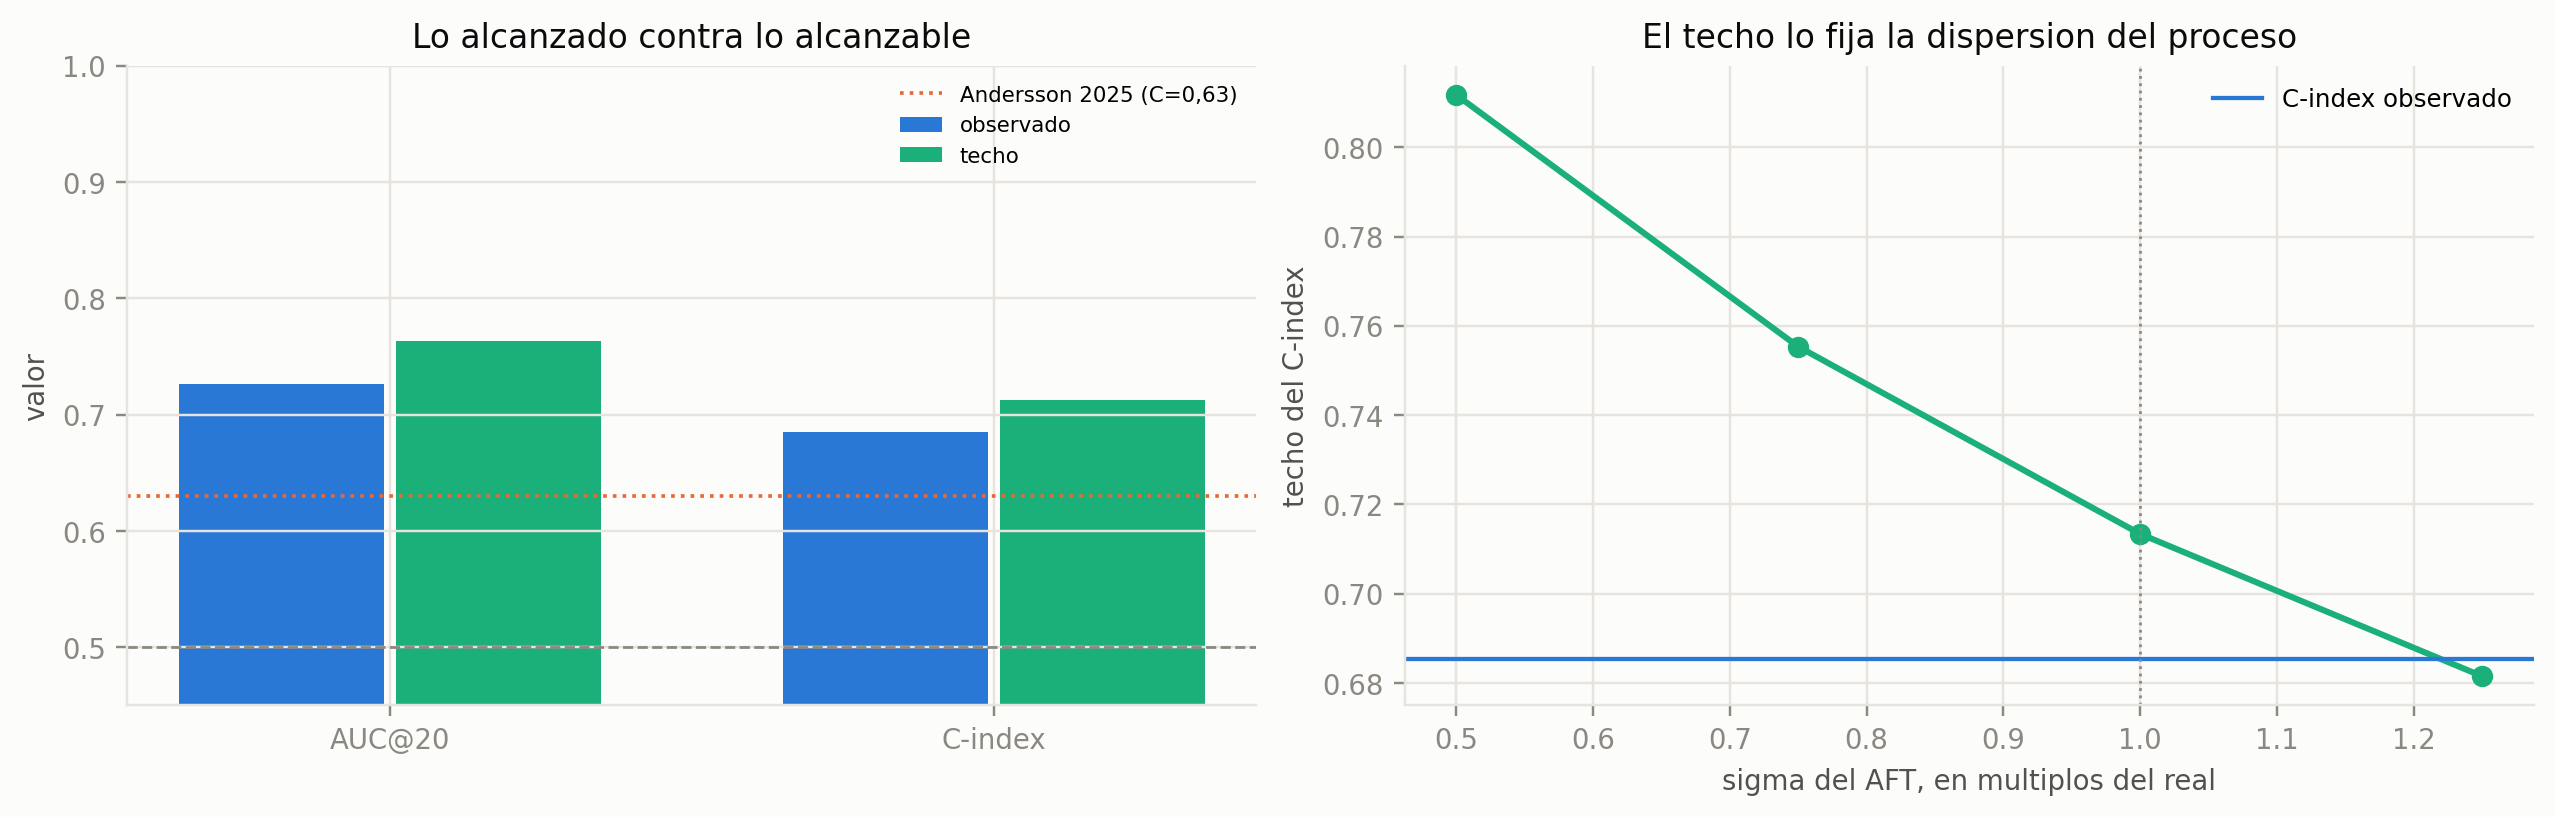

In [43]:
# El techo depende de la dispersion. Si sigma fuera menor, el desenlace seria
# mas predecible; esta tabla dice cuanto de la limitacion es ruido del proceso.
sens = []
for k in (0.50, 0.75, 1.00, 1.25):
    t_c, _ = techo_c(sigma * k, reps=15)
    sens.append({"sigma": sigma * k, "x_sigma_real": k, "techo_C_index": t_c})
sens = pd.DataFrame(sens).set_index("x_sigma_real")
display(sens.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), constrained_layout=True)

ax = axes[0]
et = [f"AUC@{H_REPORTE}", "C-index"]
x = np.arange(len(et))
ax.bar(x - 0.18, [obs_auc, obs_cidx], width=0.34, color=AZUL, label="observado")
ax.bar(x + 0.18, [techo_auc, techo_cidx], width=0.34, color=AQUA, label="techo")
ax.axhline(0.5, color=INK_MUTED, lw=0.9, ls="--")
ax.axhline(0.63, color=NARANJA, lw=1.2, ls=":", label="Andersson 2025 (C=0,63)")
ax.set_xticks(x); ax.set_xticklabels(et)
ax.set_ylim(0.45, 1.0); ax.set_ylabel("valor")
ax.set_title("Lo alcanzado contra lo alcanzable")
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
ax.plot(sens.index, sens["techo_C_index"], "o-", color=AQUA, lw=2)
ax.axhline(obs_cidx, color=AZUL, lw=1.4, ls="-", label="C-index observado")
ax.axvline(1.0, color=INK_MUTED, lw=0.9, ls=":")
ax.set_xlabel("sigma del AFT, en multiplos del real")
ax.set_ylabel("techo del C-index")
ax.set_title("El techo lo fija la dispersion del proceso")
ax.legend(frameon=False, fontsize=8)
plt.show()

In [44]:
# --- El veredicto ----------------------------------------------------------
linea = "=" * 74
brecha_c = techo_cidx - obs_cidx
brecha_a = techo_auc - obs_auc
pct_c = (obs_cidx - 0.5) / (techo_cidx - 0.5) if techo_cidx > 0.5 else np.nan

print(linea)
print("TECHO ESTOCASTICO")
print(linea)
print(f"  C-index   observado {obs_cidx:.3f}  ·  techo {techo_cidx:.3f} "
      f"(±{sd_cidx:.3f})  ·  brecha {brecha_c:+.3f}")
print(f"  AUC@{H_REPORTE}    observado {obs_auc:.3f}  ·  techo {techo_auc:.3f}"
      f"                ·  brecha {brecha_a:+.3f}")
print(f"  Brier     observado {obs_brier:.4f} ·  irreducible {techo_brier:.4f}"
      f"          ·  reducible {obs_brier - techo_brier:+.4f}")
print(f"\n  Se capturo el {pct_c:.0%} del margen alcanzable sobre el azar (C-index).")
print(f"  Referencia externa: Andersson (JSAI 2025) reporta C-index 0,63 con")
print(f"  ~20.000 filas y estima su propio techo en ~0,66.")
print(linea)

if brecha_c < 0.03:
    print("ESTAMOS CONTRA EL TECHO. El algoritmo ya extrajo casi toda la senal que")
    print("estas features contienen. Cambiar de modelo, subir la muestra o afinar")
    print("hiperparametros NO va a mover el numero. Lo unico que puede es informacion")
    print("nueva — y la literatura dice cual: Gdakowicz & Putek-Szelag (2025)")
    print("encuentran que dentro de un mismo conjunto habitacional lo que mueve el")
    print("tiempo de venta es ORIENTACION de ventanas (sur: -158 dias), VISTA (areas")
    print("verdes vs. terraplen) y PISO. Son justamente los atributos que varian")
    print("DENTRO de un edificio, y son los que no estan en bi_DimProperties.")
    print("El siguiente paso del proyecto no es de modelamiento: es de captura.")
elif brecha_c < 0.08:
    print("QUEDA ALGO, PERO POCO. Hay error de estimacion recuperable, del orden de")
    print("unas centesimas. Vale la pena probar mas shrinkage o un efecto aleatorio")
    print("por edificio antes de salir a buscar datos nuevos, pero el retorno es")
    print("acotado y el techo esta cerca.")
else:
    print("HAY MARGEN REAL. La brecha contra el techo es grande, asi que el limite")
    print("hoy NO es el ruido del proceso sino la estimacion: mas muestra, mejor")
    print("regularizacion o una especificacion mas flexible deberian rendir antes")
    print("que salir a buscar variables nuevas.")
print(linea)

TECHO ESTOCASTICO
  C-index   observado 0.685  ·  techo 0.713 (±0.004)  ·  brecha +0.027
  AUC@20    observado 0.726  ·  techo 0.763                ·  brecha +0.037
  Brier     observado 0.1738 ·  irreducible 0.1755          ·  reducible -0.0017

  Se capturo el 87% del margen alcanzable sobre el azar (C-index).
  Referencia externa: Andersson (JSAI 2025) reporta C-index 0,63 con
  ~20.000 filas y estima su propio techo en ~0,66.
ESTAMOS CONTRA EL TECHO. El algoritmo ya extrajo casi toda la senal que
estas features contienen. Cambiar de modelo, subir la muestra o afinar
hiperparametros NO va a mover el numero. Lo unico que puede es informacion
nueva — y la literatura dice cual: Gdakowicz & Putek-Szelag (2025)
encuentran que dentro de un mismo conjunto habitacional lo que mueve el
tiempo de venta es ORIENTACION de ventanas (sur: -158 dias), VISTA (areas
verdes vs. terraplen) y PISO. Son justamente los atributos que varian
DENTRO de un edificio, y son los que no estan en bi_DimProperties

### Cómo se cita este paso, y qué no prueba

**Lo que sí establece.** Que el desenlace tiene un componente irreducible grande, y cuánto. Ese
número convierte la conversación de "el modelo anda mal" en "el modelo anda cerca de lo que se
puede", que es una discusión distinta y con otras decisiones colgando. También explica el
`MAE dias` de ~20 sin necesidad de culpar a las features: una espera con tasa conocida sigue
siendo una espera aleatoria.

**Lo que no.** El techo está calculado suponiendo el modelo bien especificado, así que es *el
techo de este modelo*, no el del problema. Si aparecen orientación, vista y un `piso`
confiable, las probabilidades verdaderas se separan más entre unidades y el techo sube. Por eso
la conclusión correcta cuando la brecha es chica nunca es "no se puede predecir mejor", sino
**"no se puede predecir mejor con esta información"**.

**Y la comparación con Andersson tiene letra chica.** Otro mercado, otra definición de
vacancia, muestra cinco veces mayor, y su C-index sale de validación cruzada aleatoria mientras
el nuestro sale de validación forward por cohorte — que el Paso 8 mostró que es
sistemáticamente más exigente. Sirve como referencia de orden de magnitud, no como marcador.

## Paso 18 · Recalibración

El Paso 12 dejó el problema que bloquea publicar probabilidades: **todas las pendientes de
calibración están por debajo de 1**. En la corrida del 2026-09-01 el modelo A dio 0,487, B 0,717
y C 0,725. Una pendiente de 0,72 significa que los log-odds predichos están ~28% más dispersos
de lo que deberían: los extremos exageran. Un score que dice 85% cuando la tasa real de ese
grupo es 70% no sirve para decidir un precio, aunque ordene perfecto.

Se arregla con un paso más, no con un rediseño. La recalibración de Platt ajusta

$$\text{logit}(p_{\text{cal}}) = a + b\,\text{logit}(p)$$

y con `b ≈ 0,72` estimado, encoge los log-odds de vuelta a su escala correcta.

**Dos condiciones para que esto no sea trampa.** Primero, la recalibración es monótona, así que
**dentro de cada cohorte el orden no cambia** y el AUC intra-cohorte tiene que quedar idéntico
— hay un `assert` que lo verifica. El AUC *agregado* sí puede moverse un poco, porque cada
cohorte recibe su propio par `(a, b)` y el pool de todas se reordena; eso es esperable y no es
una mejora del modelo. Si alguien reporta una ganancia de discriminación por recalibrar, está
leyendo mal. Segundo, y más importante, la
recalibración **también hay que validarla fuera de muestra**: se estima con las cohortes
anteriores y se aplica a la siguiente, igual que el modelo. Ajustarla sobre las mismas
predicciones que después se evalúan da una pendiente de 1,000 por construcción y no significa
nada.

Las primeras cohortes no alcanzan a tener historia para calibrar y quedan fuera de la
comparación; la tabla dice sobre cuántas filas se mide.

In [45]:
def recalibrar_forward(pred, etiqueta, h=None, min_train=300):
    '''Platt estimado con las cohortes anteriores y aplicado a la siguiente.'''
    h = H_REPORTE if h is None else h
    j = REJILLA_H.index(h)
    dd = pred["datos"].iloc[pred["idx"]]
    p = np.clip(pred["cif"][:, j], 1e-6, 1 - 1e-6)
    y = target_binario(dd, h)
    coh = dd["cohorte_lpa"].to_numpy()
    orden = [c for c in COHORTES if c in set(coh)]

    p_cal = np.full(len(p), np.nan)
    saltadas = []
    for k in range(1, len(orden)):
        tr = np.isin(coh, orden[:k]) & np.isfinite(y)
        te = coh == orden[k]
        if tr.sum() < min_train or len(np.unique(y[tr])) < 2 or not te.any():
            continue
        cal = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
        cal.fit(_logit(p[tr]).reshape(-1, 1), y[tr].astype(int))
        b = float(cal.coef_[0, 0])
        # GUARDA. Si la pendiente estimada sale <= 0, el mapeo INVIERTE el orden
        # y el score recalibrado es peor que no hacer nada. Pasa cuando el modelo
        # no discrimina en las cohortes de entrenamiento. En produccion esto
        # tiene que ser un fallback, no un error silencioso.
        if b <= 0.05:
            saltadas.append((orden[k], b))
            continue
        p_cal[te] = cal.predict_proba(_logit(p[te]).reshape(-1, 1))[:, 1]
    if saltadas:
        print(f"  [{etiqueta}] {len(saltadas)} cohorte(s) sin recalibrar por "
              f"pendiente <= 0,05: {[(c, round(b, 3)) for c, b in saltadas]}")

    ok = np.isfinite(p_cal) & np.isfinite(y)
    if ok.sum() < 100:
        return None
    yv = y[ok].astype(int)

    # AUC promedio DENTRO de cada cohorte: es ahi donde Platt tiene que ser
    # inocua, porque cada cohorte recibe su propio (a, b). Ver nota abajo.
    def por_cohorte(pv, fn):
        aa = []
        for c in np.unique(coh[ok]):
            m = coh[ok] == c
            if m.sum() >= 30 and len(np.unique(yv[m])) == 2:
                aa.append(fn(yv[m], pv[m]))
        return float(np.nanmean(aa)) if aa else np.nan

    auc_por_cohorte = lambda pv: por_cohorte(pv, roc_auc_score)

    filas = []
    for nom, pv in [("antes", p[ok]), ("recalibrado", p_cal[ok])]:
        filas.append({"modelo": etiqueta, "version": nom, "n": int(ok.sum()),
                      "AUC": roc_auc_score(yv, pv),
                      "AUC_intra_cohorte": auc_por_cohorte(pv),
                      "Brier": brier_score_loss(yv, pv),
                      "Calib_slope": pendiente_calibracion(yv, pv),
                      "slope_intra": por_cohorte(pv, pendiente_calibracion),
                      "CIL": float(pv.mean() - yv.mean())})
    return pd.DataFrame(filas), y[ok], p[ok], p_cal[ok]


recal = {}
filas_r = []
for nom, pr in [("B · AFT", pred_B), ("C · hazard", pred_C), ("A · logistica", pred_A)]:
    r = recalibrar_forward(pr, nom)
    if r is not None:
        filas_r.append(r[0]); recal[nom] = r
tab_r = pd.concat(filas_r).set_index(["modelo", "version"])
display(tab_r.round(4))

# Platt es monotona, pero cada cohorte recibe su propio (a, b). Dentro de una
# cohorte el orden no puede cambiar; en el pool de todas SI puede, porque dos
# cohortes distintas quedan mapeadas con curvas distintas. Por eso la invariancia
# se verifica en `AUC_intra_cohorte` y no en `AUC`.
for nom in recal:
    a = tab_r.loc[(nom, "antes")]; b = tab_r.loc[(nom, "recalibrado")]
    assert abs(a["AUC_intra_cohorte"] - b["AUC_intra_cohorte"]) < 1e-6, (
        f"{nom}: el AUC intra-cohorte cambio. Platt no puede hacer eso: revisar.")
print("Verificado: el AUC intra-cohorte no se movio en ningun modelo.")
print("El AUC agregado puede moverse un poco, y no es un error: cada cohorte")
print("queda mapeada con una curva distinta, asi que el pool se reordena.")
print("Lo que tiene que mejorar es la pendiente hacia 1 y el CIL hacia 0.")
print()
print("Dos pendientes en la tabla, y hay que leer las dos:")
print("  Calib_slope  agregada sobre todas las cohortes. Es la del producto: si")
print("               se publica el score, esta es la que tiene que dar ~1.")
print("  slope_intra  promedio DENTRO de cada cohorte. Es el diagnostico: si esta")
print("               mejora y la agregada no, las cohortes se calibran bien por")
print("               separado pero con curvas distintas entre si, y conviene")
print("               estimar un solo Platt sobre toda la ventana en vez de uno")
print("               por mes.")

n   AUC  AUC_intra_cohorte  Brier  Calib_slope  slope_intra   CIL
modelo        version                                                                          
B · AFT       antes        1697 0.731              0.729  0.168        0.731        0.781 0.098
              recalibrado  1697 0.713              0.729  0.168        0.777        1.037 0.091
C · hazard    antes        1697 0.703              0.699  0.167        0.624        0.787 0.064
              recalibrado  1697 0.692              0.699  0.172        0.582        1.000 0.081
A · logistica antes        1697 0.693              0.687  0.189        0.419        0.569 0.102
              recalibrado  1697 0.685              0.687  0.180        0.492        0.980 0.079

Verificado: el AUC intra-cohorte no se movio en ningun modelo.
El AUC agregado puede moverse un poco, y no es un error: cada cohorte
queda mapeada con una curva distinta, asi que el pool se reordena.
Lo que tiene que mejorar es la pendiente hacia 1 y el CIL hacia 0.

Dos pendientes en la tabla, y hay que leer las dos:
  Calib_slope  agregada sobre todas las cohortes. Es la del producto: si
               se publica el score, esta es la que tiene que dar ~1.
  slope_intra  promedio DENTRO de cada cohorte. Es el diagnostico: si esta
               mejora y la agregada no, las cohortes se calibran bien por
               separado pero con curvas distintas entre si, y conviene
               estimar un solo Platt sobre toda la ventana en vez de uno
               por mes.


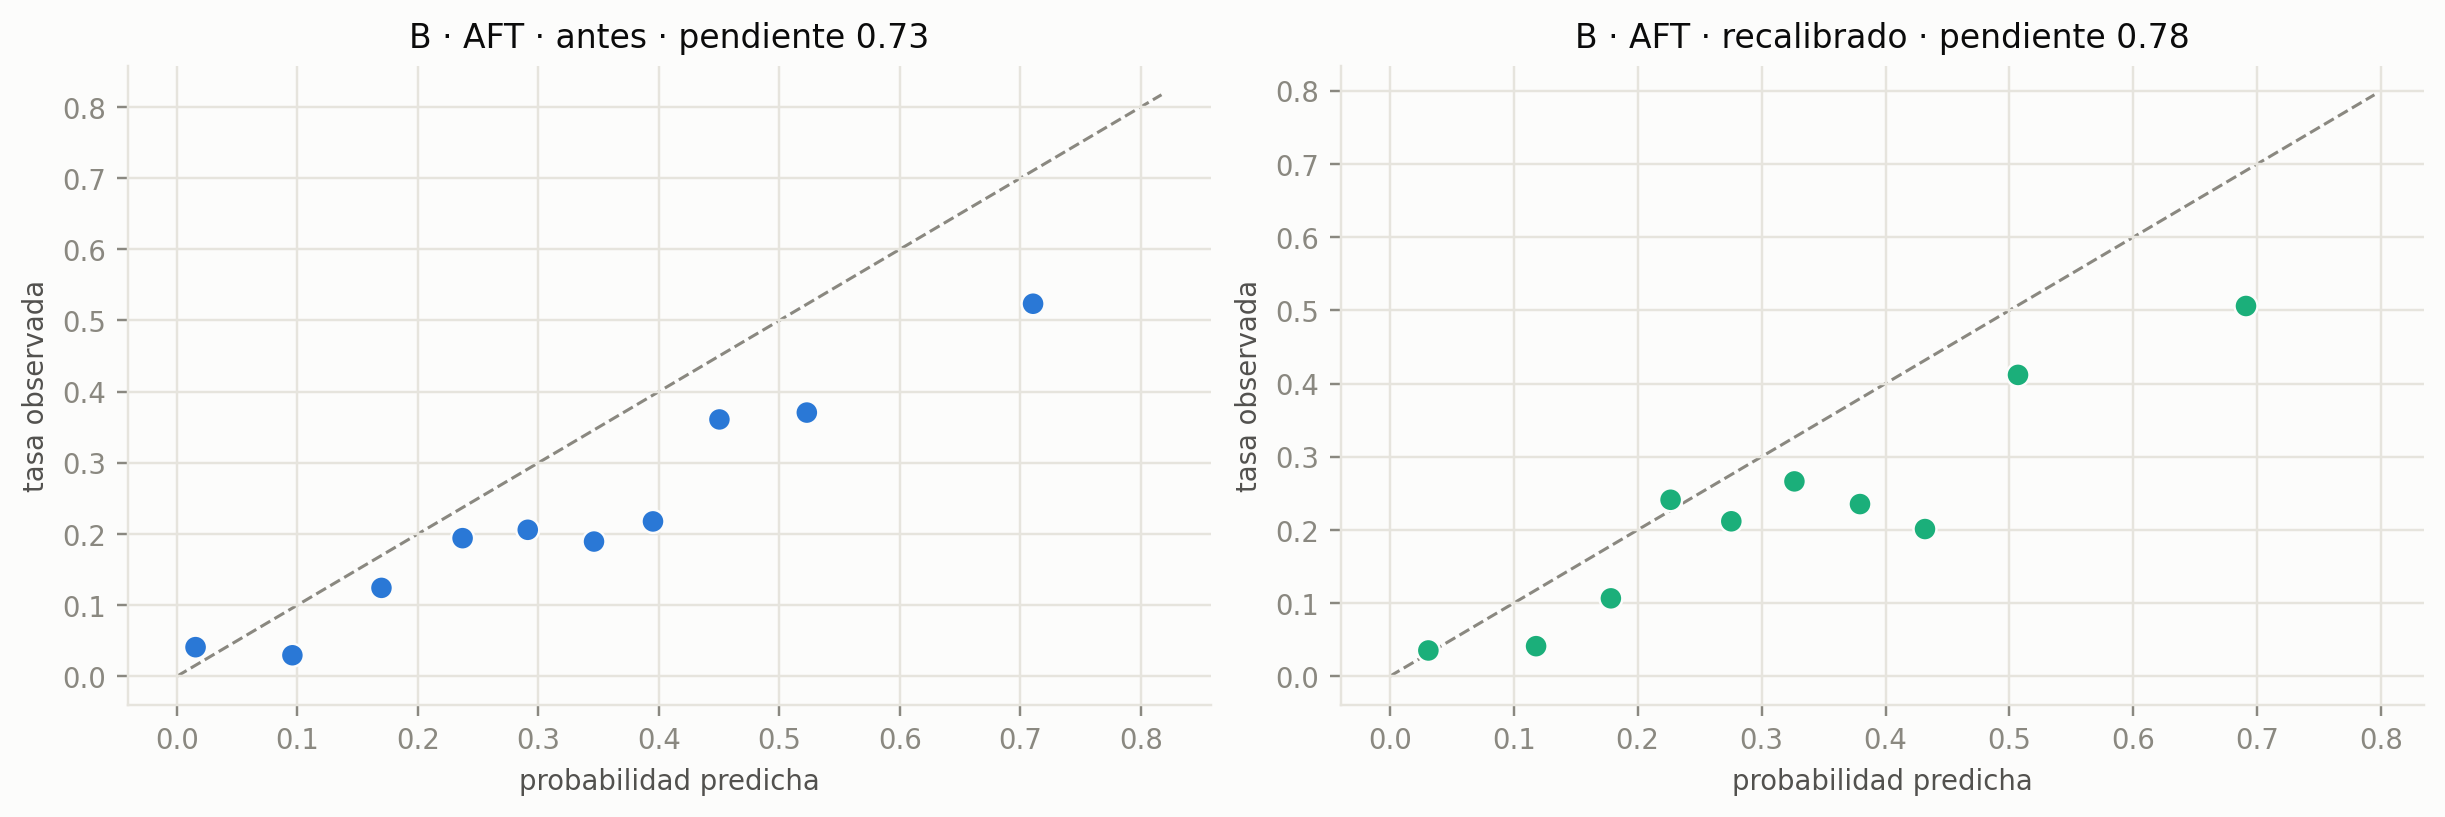

RECALIBRACION
  B · AFT        pendiente 0.731 -> 0.777   CIL +0.098 -> +0.091   Brier 0.1679 -> 0.1683
  C · hazard     pendiente 0.624 -> 0.582   CIL +0.063 -> +0.081   Brier 0.1668 -> 0.1723
  A · logistica  pendiente 0.419 -> 0.492   CIL +0.102 -> +0.079   Brier 0.1892 -> 0.1805
El mejor calibrado despues del ajuste es B · AFT.

QUE SIGNIFICA PARA EL PRODUCTO

  Con la pendiente cerca de 1 y el CIL cerca de 0, la probabilidad se puede
  MOSTRAR como probabilidad: "72% de que esta unidad pase de 20 dias" quiere
  decir que 72 de cada 100 unidades con ese score pasan de 20 dias.

  Sin recalibrar, el mismo score solo sirve para ORDENAR. Sigue siendo util
  para priorizar atencion —el decil peor es el decil peor con o sin
  calibracion— pero no se puede publicar el numero.

  En produccion la recalibracion se reajusta con la misma cadencia que el
  modelo, y con el mismo esquema: estimada sobre el pasado, aplicada al mes
  que viene. Es una regresion logistica de una variable; el cost

In [46]:
def tabla_calibracion(y, p, bins=10):
    t = pd.DataFrame({"p": p, "y": y})
    t["bin"] = pd.qcut(t["p"], q=min(bins, t["p"].nunique()), duplicates="drop")
    return (t.groupby("bin", observed=True)
             .agg(p_media=("p", "mean"), tasa_obs=("y", "mean"), n=("y", "size"))
             .reset_index(drop=True))


mejor_cal = min(recal, key=lambda k: abs(tab_r.loc[(k, "recalibrado"), "Calib_slope"] - 1))
_, yv, pv0, pv1 = recal[mejor_cal]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for ax, pv, tit in [(axes[0], pv0, "antes"), (axes[1], pv1, "recalibrado")]:
    t = tabla_calibracion(yv, pv)
    lim = [0, max(t["p_media"].max(), t["tasa_obs"].max()) * 1.15]
    ax.plot(lim, lim, color=INK_MUTED, lw=1, ls="--", zorder=1)
    ax.scatter(t["p_media"], t["tasa_obs"], s=t["n"] / 3,
               color=AZUL if tit == "antes" else AQUA, zorder=2,
               edgecolor=SURFACE, linewidth=0.8)
    sl = pendiente_calibracion(yv, pv)
    ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("tasa observada")
    ax.set_title(f"{mejor_cal} · {tit} · pendiente {sl:.2f}")
plt.show()

linea = "=" * 74
print(linea)
print("RECALIBRACION")
print(linea)
for nom in recal:
    a = tab_r.loc[(nom, "antes")]; b = tab_r.loc[(nom, "recalibrado")]
    print(f"  {nom:<14s} pendiente {a['Calib_slope']:.3f} -> {b['Calib_slope']:.3f}   "
          f"CIL {a['CIL']:+.3f} -> {b['CIL']:+.3f}   "
          f"Brier {a['Brier']:.4f} -> {b['Brier']:.4f}")
print(linea)
print(f"El mejor calibrado despues del ajuste es {mejor_cal}.")
print('''
QUE SIGNIFICA PARA EL PRODUCTO

  Con la pendiente cerca de 1 y el CIL cerca de 0, la probabilidad se puede
  MOSTRAR como probabilidad: "72% de que esta unidad pase de 20 dias" quiere
  decir que 72 de cada 100 unidades con ese score pasan de 20 dias.

  Sin recalibrar, el mismo score solo sirve para ORDENAR. Sigue siendo util
  para priorizar atencion —el decil peor es el decil peor con o sin
  calibracion— pero no se puede publicar el numero.

  En produccion la recalibracion se reajusta con la misma cadencia que el
  modelo, y con el mismo esquema: estimada sobre el pasado, aplicada al mes
  que viene. Es una regresion logistica de una variable; el costo es nulo.
''')

## Cómo leer todo esto, y qué falta

**La respuesta a la pregunta original.** Sí se puede modelar, y hay tres formulaciones válidas
según qué se entregue: una probabilidad a un plazo fijo (A), días predichos con toda la curva
(B), o la curva descontando el churn (C). La regresión lineal funciona —en su forma censurada,
que es el AFT—; lo que no funciona es OLS sobre los días de las unidades arrendadas.

**El horizonte no es un dato del problema, es una decisión.** El Paso 5 la deja explícita en
`H_REPORTE`. Si el AUC sigue subiendo hasta 30 días y la observabilidad aguanta, hay un
argumento estadístico para mover el target; el contraargumento es de negocio y también hay que
escribirlo.

**Un modelo no se elige con un número.** El Paso 12 da cinco, en dos escalas, y pueden apuntar
a modelos distintos. Si el entregable es "probabilidad de colocar en X días", manda el Brier
calibrado; si es "cuánto va a demorar" o un ranking de cartera, mandan el C-index y el IBS.

**Tres cosas quedan abiertas y las tres pueden mover los números:**

1. **`piso = 0`.** 30,8% de la muestra, y es la única variable con signo invertido. Si es
   "sin dato", hoy el modelo aprende ruido con forma de planta baja. Se resuelve preguntando a
   quien mantiene `bi_DimProperties`, no con estadística.
2. **Primera vs. última reserva.** 6,0% de las arrendadas tienen dos o más reservas antes del
   contrato; usar la última atrasa el cierre 18 días de mediana. Es una línea en el `CASE` de
   `event_date`.
3. **El centrado del gap.** Está arreglado *acá*, en pandas. Mientras no se arregle en
   `query_analisis_final.sql`, cualquiera que use la query sin este notebook lee la columna
   mala.

**Y una limitación que no se arregla:** el modelo aplica a unidades que llegan a LPA con
historial de precio. Las 3.849 descartadas tienen censura 69,6% contra 19,1%. Además, 1.733
unidades del universo llegaron a "Arrendado" sin pasar nunca por "Lista para arrendar" — no son
vacancias perdidas (entraron ya ocupadas o asignadas sin ciclo de publicación), pero acotan a
qué stock se puede aplicar el score.

In [47]:
linea = "-" * 74
if NO_CONVERGIERON:
    print("!" * 74)
    print(f"AVISO: {len(NO_CONVERGIERON)} ajustes chocaron contra max_iter. Sus")
    print("coeficientes quedaron a medio camino y sus metricas no son confiables.")
    for etq, it, k in NO_CONVERGIERON[:8]:
        print(f"   {etq:<30s} {it} iteraciones · {k} columnas")
    print("Causa tipica: una columna sin escalar entre otras estandarizadas.")
    print("!" * 74 + "\n")
else:
    print("Todos los ajustes convergieron.\n")
print(linea)
print(f"RESUMEN · horizonte de reporte {H_REPORTE} dias · validacion forward por cohorte")
print(linea)
print(f"  {'modelo':<26s} {'AUC@' + str(H_REPORTE):>8s} {'C-index':>9s} "
      f"{'IBS':>8s} {'MAE dias':>9s}")
for nom, r in tabla.iterrows():
    mae = f"{r['MAE_dias']:.1f}" if np.isfinite(r["MAE_dias"]) else "  -  "
    print(f"  {nom:<26s} {r[f'AUC@{H_REPORTE}']:>8.3f} {r['C_index']:>9.3f} "
          f"{r['IBS']:>8.4f} {mae:>9s}")
print(linea)
g_auc = tabla[f"AUC@{H_REPORTE}"].max() - base_auc
g_ibs = base_ibs - tabla["IBS"].min()
print(f"  ganancia sobre el baseline:  {g_auc:+.3f} de AUC  ·  "
      f"{g_ibs:+.4f} de IBS")
print(linea)
print('''
DECISION QUE HAY QUE TOMAR CON ESTA TABLA

  ganancia de AUC < 0,03   el modelo no justifica su costo todavia. El cuello no
                    es el algoritmo: la ubicacion explica casi todo y ya esta en
                    el baseline. Buscar features nuevas (competencia dentro del
                    edificio, stock disponible en la comuna esa semana,
                    antiguedad del edificio) antes que modelos nuevos.

  0,03 a 0,08       el modelo aporta. Ir con el lineal (A o B) por
                    interpretabilidad, salvo que D le saque mas de 0,03.

  mas de 0,08       hay senal clara. Vale la pena el producto, y conviene
                    invertir en el modelo landmark del dia 7.

  Si A y B empatan en AUC pero B gana en IBS y C-index, la eleccion es B: da lo
  mismo con menos supuestos y ademas entrega dias, que es lo que el negocio pide.
''')

Todos los ajustes convergieron.

--------------------------------------------------------------------------
RESUMEN · horizonte de reporte 20 dias · validacion forward por cohorte
--------------------------------------------------------------------------
  modelo                       AUC@20   C-index      IBS  MAE dias
  baseline segmento             0.586     0.549   0.2170      20.0
  A · logistica ridge           0.706     0.667   0.2043       -  
  B · AFT log-normal            0.726     0.685   0.1958      19.6
  C · hazard competitivo        0.716     0.680   0.1952      20.1
  D · gradient boosting         0.731     0.677   0.2010       -  
--------------------------------------------------------------------------
  ganancia sobre el baseline:  +0.145 de AUC  ·  +0.0218 de IBS
--------------------------------------------------------------------------

DECISION QUE HAY QUE TOMAR CON ESTA TABLA

  ganancia de AUC < 0,03   el modelo no justifica su costo todavia. El cuello no
    